# CFO Prediction Model — Poland (v4)

Este notebook construye un sistema de predicción de CFO (Complete First Order) para riders en Polonia. La idea central es modelar el funnel de contratación como una cadena de probabilidades: cada etapa (Lead → Doc Review → Hired → CFO) tiene su propio modelo, y la probabilidad final es el producto de las tres.

Trabajamos con lo que llamamos "Closed Loop": solo usamos leads cuyo proceso ya terminó (contratados o rechazados), para no contaminar el entrenamiento con leads aún en progreso.

## 1. Setup del entorno

Instalamos e importamos todas las librerías que vamos a necesitar: BigQuery para extraer los datos de producción, LightGBM/XGBoost/CatBoost para los modelos, Optuna para la búsqueda de hiperparámetros, y SHAP para interpretabilidad. Fijamos la semilla y configuramos los plots para que todo sea reproducible.

In [142]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "google-cloud-bigquery", "db-dtypes",
    "lightgbm", "xgboost", "catboost",
    "optuna", "shap", "scikit-learn",
    "pandas", "matplotlib", "seaborn",
])

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression as IsoReg   # isotonic calibration
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, f1_score, precision_score, recall_score, brier_score_loss,
    confusion_matrix,
)

import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette("husl")

import xgboost as xgb
import catboost as cb
print(f"LightGBM {lgb.__version__} | XGBoost {xgb.__version__} | CatBoost {cb.__version__}")
print(f"Optuna {optuna.__version__} | SHAP {shap.__version__}")


LightGBM 4.6.0 | XGBoost 2.1.4 | CatBoost 1.2.10
Optuna 4.8.0 | SHAP 0.49.1


Librerías cargadas y configuradas. Ya podemos empezar.

## 2. Extracción de datos desde BigQuery

Extraemos el funnel completo de Polonia desde BigQuery. La query encadena varias CTEs: `base_applicants` trae los leads PL con resolución final (hired o rejected, sin duplicados), `raw_transitions` captura cada cambio de estado en Fountain, `pivoted_stage_times` calcula los tiempos por stage, `doc_review_completed` marca con un flag binario si el candidato realmente completó la revisión documental (no solo entró en ella), `target` cruza con rider_attributes para saber si hizo CFO, y `rider_profile` añade source, vehículo, canal de registro y motivo de rechazo. Filtramos desde marzo 2025 y solo los workflows relevantes de PL.

In [143]:
project_id = "dhub-glovo"
client = bigquery.Client(project=project_id)

funnel_data = """
WITH base_applicants AS (
    SELECT
        a.country_code, 
        ci.city_code, 
        a.applicant_id, 
        a.rider_id,
        a.created_at, 
        a.approved_at,
        a.rejected_at,
        COALESCE(a.approved_at, a.rejected_at) AS final_resolution_at,
        DATE_TRUNC(DATE(a.created_at), ISOWEEK) AS week,
        TRIM(a.workflow.workflow_name) AS workflow_name,
        CASE WHEN a.approved_at IS NOT NULL THEN 1 ELSE 0 END AS was_hired,
        ROUND(TIMESTAMP_DIFF(COALESCE(a.approved_at, a.rejected_at), a.created_at, MINUTE) / 60.0 / 24.0, 4) AS lead_to_resolution_days
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    JOIN `fulfillment-dwh-production.curated_data_shared.countries` AS co ON co.country_code = a.country_code
    CROSS JOIN UNNEST(co.cities) AS ci ON a.city_id = ci.id
    WHERE a.country_code = 'gv-pl'
      AND a.duplicate IS FALSE
      AND TRIM(a.workflow.workflow_name) IN ('3PL already assigned leads PL', 'Other leads PL')
      AND DATE(a.created_at) >= '2025-03-01'
      AND (a.approved_at IS NOT NULL OR a.rejected_at IS NOT NULL)
),
raw_transitions AS (
    SELECT
        a.applicant_id,
        CONCAT('Tier ', CAST(t.tier AS STRING), ' - ', s.name) AS stage_name,
        LOWER(TRIM(tr.to_state)) AS to_state,
        tr.created_at AS transition_timestamp
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    CROSS JOIN UNNEST(a.workflow.tiers) AS t
    CROSS JOIN UNNEST(t.stage) AS s
    CROSS JOIN UNNEST(s.transitions) AS tr
    JOIN base_applicants ba ON a.applicant_id = ba.applicant_id 
    WHERE LOWER(TRIM(tr.to_state)) != 'locked'
),
first_touches AS (
    SELECT 
        applicant_id, 
        stage_name, 
        MIN(transition_timestamp) AS stage_first_entered_at
    FROM raw_transitions
    GROUP BY applicant_id, stage_name
),
ordered_milestones AS (
    SELECT 
        applicant_id, 
        stage_name, 
        stage_first_entered_at,
        LEAD(stage_first_entered_at) OVER (PARTITION BY applicant_id ORDER BY stage_first_entered_at ASC) AS next_stage_entered_at
    FROM first_touches
),
milestone_times AS (
    SELECT
        o.applicant_id,
        o.stage_name,
        ROUND(TIMESTAMP_DIFF(
            COALESCE(o.next_stage_entered_at, b.final_resolution_at),
            o.stage_first_entered_at,
            MINUTE
        ) / 60.0 / 24.0, 4) AS stage_macro_days
    FROM ordered_milestones o
    JOIN base_applicants b ON o.applicant_id = b.applicant_id
),
pivoted_stage_times AS (
    SELECT
        applicant_id,
        MAX(CASE WHEN stage_name LIKE '%Tier 0 - Document Collection%' THEN stage_macro_days ELSE NULL END) AS tier_0_doc_collection_days,
        MAX(CASE WHEN stage_name LIKE '%Tier 1 - Document Collection%' THEN stage_macro_days ELSE NULL END) AS tier_1_doc_collection_days,
        MAX(CASE WHEN stage_name LIKE '%Document Review%' THEN stage_macro_days ELSE NULL END) AS doc_review_days,
        MAX(CASE WHEN stage_name LIKE '%Waiting list%' THEN stage_macro_days ELSE NULL END) AS wl_days,
        MAX(CASE WHEN stage_name LIKE '%Equipment Collection%' THEN stage_macro_days ELSE NULL END) AS equip_collection_days,
        MAX(CASE WHEN stage_name LIKE '%Hiring control%' THEN stage_macro_days ELSE NULL END) AS hiring_control_days
    FROM milestone_times
    GROUP BY applicant_id
),
doc_review_completed AS (
    SELECT
        applicant_id,
        MAX(CASE WHEN stage_name LIKE '%Document Review%'
                  AND to_state = 'completed'
             THEN 1 ELSE 0 END) AS completed_doc_review
    FROM raw_transitions
    GROUP BY applicant_id
),
target AS (
    SELECT 
        a.applicant_id,
        CASE WHEN ra.first_order_creation_datetime IS NOT NULL THEN 1 ELSE 0 END AS is_cfo
    FROM base_applicants a 
    LEFT JOIN `fulfillment-dwh-production.curated_data_shared_glovo.rider_attributes__rider_attributes` AS ra
        ON ra.rider_id = a.rider_id
),
rider_profile AS (
    SELECT 
        a.applicant_id,
        a.rejected_by_non_pii,
        a.rejection_category, 
        a.rejection_type, 
        a.current_stage_name,
        a.company_name,
        (SELECT cf.value FROM UNNEST(a.custom_fields) AS cf WHERE cf.name='vehicle' LIMIT 1) AS vehicle_from_custom_fields,
        CASE
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%REFERRAL%' OR UPPER(a.custom_non_pii_fields.utm.source) LIKE '%RAF%' THEN 'REFERRAL'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%3PL%'      THEN '3PL'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%RIDERHUB%' THEN 'RIDER WEB'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) LIKE '%JOBPLATFORM%' THEN 'JOB PLATFORM'
            WHEN (UPPER(a.custom_non_pii_fields.utm.source) LIKE '%GOOGLE%' OR
                  UPPER(a.custom_non_pii_fields.utm.source) LIKE '%FACEBOOK%' OR
                  UPPER(a.custom_non_pii_fields.utm.source) LIKE '%TIKTOK%')
                 AND UPPER(a.custom_non_pii_fields.utm.medium) <> 'SOCIAL'   THEN 'PERF MKT'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) = 'OFFLINE'
                 AND NOT (UPPER(a.custom_non_pii_fields.utm.source) IN ('BRANDAMBASSADOR','CAPTAIN')) THEN 'OFFLINE'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) IN ('BRANDAMBASSADOR','CAPTAIN') THEN 'BRAND AMBASSADOR'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) = 'SOCIAL' THEN 'SOCIAL MEDIA'
            ELSE 'ORGANIC'
        END AS source,
        CASE WHEN a.custom_non_pii_fields.registration_source='web' THEN 1
             WHEN a.custom_non_pii_fields.registration_source='app' THEN 0
             ELSE NULL END AS registered_via_web,
        CASE WHEN EXTRACT(MONTH FROM a.created_at) IN (12,1,2) THEN 'winter'
             WHEN EXTRACT(MONTH FROM a.created_at) IN (3,4,5)  THEN 'spring'
             WHEN EXTRACT(MONTH FROM a.created_at) IN (6,7,8)  THEN 'summer'
             ELSE 'autumn' END AS apply_season
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    JOIN base_applicants ba ON a.applicant_id = ba.applicant_id
)
SELECT
    b.applicant_id,
    b.city_code,
    b.created_at,
    DATE_TRUNC(b.week, MONTH) AS month,
    b.workflow_name,
    b.rider_id,
    t.is_cfo,
    b.was_hired,
    rp.rejected_by_non_pii AS rejected_by,
    rp.rejection_category,
    rp.rejection_type,
    rp.current_stage_name,
    rp.company_name,
    rp.vehicle_from_custom_fields,
    
    b.lead_to_resolution_days AS lead_to_hired_or_failed_days,

    pt.tier_0_doc_collection_days,
    pt.tier_1_doc_collection_days,
    pt.doc_review_days,
    pt.wl_days,
    pt.equip_collection_days,
    pt.hiring_control_days,

    rp.source,
    rp.registered_via_web,
    rp.apply_season,

    drc.completed_doc_review
FROM base_applicants b
LEFT JOIN pivoted_stage_times pt ON b.applicant_id = pt.applicant_id
LEFT JOIN target t ON b.applicant_id = t.applicant_id
LEFT JOIN rider_profile rp ON b.applicant_id = rp.applicant_id
LEFT JOIN doc_review_completed drc ON b.applicant_id = drc.applicant_id
WHERE b.city_code IS NOT NULL
"""

print("Running BigQuery...")
df_raw = client.query(funnel_data).result().to_dataframe()
print(f"Shape: {df_raw.shape}")
df_raw.head(3)


Running BigQuery...
Shape: (166041, 25)


,applicant_id,city_code,created_at,month,workflow_name,rider_id,is_cfo,was_hired,rejected_by,rejection_category,...,tier_0_doc_collection_days,tier_1_doc_collection_days,doc_review_days,wl_days,equip_collection_days,hiring_control_days,source,registered_via_web,apply_season,completed_doc_review
0,89be9562-c062-4252-83c5-63541ef2083e,AUG,2025-05-29 09:26:46.200444+00:00,2025-05-01,3PL already assigned leads PL,<NA>,0,0,user,recruiter_rejected,...,11.9056,NaN,NaN,NaN,NaN,NaN,3PL,1,spring,0
1,ecd1e1bf-d4b2-48e0-bc93-a19b7f5e78c8,KRA,2025-09-11 19:38:32.183428+00:00,2025-09-01,3PL already assigned leads PL,<NA>,0,0,user,recruiter_rejected,...,0.0014,NaN,20.5493,NaN,NaN,NaN,REFERRAL,1,autumn,0
2,599af26c-e13b-42dd-98e0-b4a4b5bd8f12,KRA,2025-10-26 06:39:08.791947+00:00,2025-10-01,Other leads PL,<NA>,0,0,user,recruiter_rejected,...,0.0000,0.0,2.3972,NaN,NaN,NaN,ORGANIC,1,autumn,0


Tenemos el dataset cargado. Cada fila es un lead con su información de perfil, tiempos por etapa del funnel, y si finalmente llegó a CFO o no.

## 3. Feature engineering

Construimos todas las features que van a alimentar los modelos. Primero las temporales: hora, día de la semana, mes, trimestre, fin de semana, con codificación cíclica seno/coseno para que el modelo entienda que diciembre y enero están cerca en el calendario. Después limpiamos el campo libre de vehículo, agrupamos ciudades pequeñas en "OTHER", hacemos label encoding de las categóricas, y marcamos con un flag los leads rechazados por timeout del sistema (~60 días de inactividad), para separar esa señal de los tiempos reales del funnel.

La definición de S1 (`reached_s1`) ahora usa `completed_doc_review` en vez de simplemente mirar si `doc_review_days` no es null — porque el campo antiguo también era NOT NULL para candidatos rechazados durante Doc Review, y eso contaminaba M1.

Al final añadimos lag features: tasas históricas de S1 y CFO por ciudad y source del mes anterior, sin leakage.

In [144]:
# ── Base: tz-strip (Closed Loop — query already filters resolved leads) ──────
df = df_raw.copy()
df["created_at"] = pd.to_datetime(df["created_at"]).dt.tz_convert(None)
# No duplicate filter needed (already in query: a.duplicate IS FALSE)
# No censoring filter needed (Closed Loop: only hired/rejected leads)
print(f"Applicants (Closed Loop, resolved only): {len(df):,}")

# ── Temporal features ─────────────────────────────────────────────────────────
df["_month_period"] = df["created_at"].dt.to_period("M").astype(str)
df["hour_of_day"]   = df["created_at"].dt.hour
df["hour_sin"]      = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"]      = np.cos(2 * np.pi * df["hour_of_day"] / 24)
df["day_of_week"]   = df["created_at"].dt.dayofweek
df["dow_sin"]       = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]       = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_num"]     = df["created_at"].dt.month
df["month_sin"]     = np.sin(2 * np.pi * df["month_num"] / 12)
df["month_cos"]     = np.cos(2 * np.pi * df["month_num"] / 12)
df["quarter"]       = df["created_at"].dt.quarter
df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)

# ── Vehicle ───────────────────────────────────────────────────────────────────
vehicle_map = {
    "car": "car", "electric car": "electric_car",
    "bicycle": "bicycle", "electric bicycle": "electric_bicycle",
    "motorbike": "motorbike", "electric motorbike": "electric_motorbike",
    "scooter": "motorbike", "moped": "motorbike",
    "walker": "walker", "on foot": "walker",
}
df["vehicle_clean"] = (
    df["vehicle_from_custom_fields"].str.lower().str.strip()
    .map(vehicle_map).fillna("unknown")
)

# ── City ──────────────────────────────────────────────────────────────────────
city_freq_map = df["city_code"].value_counts(normalize=True).to_dict()
df["city_freq"]  = df["city_code"].map(city_freq_map)
top_cities       = df["city_code"].value_counts().head(20).index.tolist()
df["city_group"] = df["city_code"].apply(lambda x: x if x in top_cities else "OTHER")

# ── Other static ──────────────────────────────────────────────────────────────
df["registered_via_web"] = df["registered_via_web"].fillna(-1).astype(int)

# ── Label encoding ────────────────────────────────────────────────────────────
CAT_COLS = ["source", "apply_season", "vehicle_clean", "city_group"]
le_dict  = {}
for col in CAT_COLS:
    df[col] = df[col].fillna("UNKNOWN")
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# ── Timeout flag: system auto-rejection (~60 day idle_time) ──────────────────
# Stage time columns contain ~60.0 days for leads auto-rejected by timeout.
# Separate the two signals: is_timeout=1 flag + NaN durations (set in ds_t2/t3).
df["is_timeout"] = (df["rejection_type"] == "unresponsive").astype(int)
print(f"Timeout (unresponsive) leads: {df['is_timeout'].sum():,} ({df['is_timeout'].mean()*100:.1f}%)")

# ── Transition targets ────────────────────────────────────────────────────────
# reached_s1: completed doc review (not just entered — avoids counting rejections during Doc Review)
_old_s1 = df["doc_review_days"].notna().astype(int)  # OLD: entered Doc Review
df["reached_s1"] = df["completed_doc_review"].fillna(0).astype(int)  # NEW: completed Doc Review
_old_rate = _old_s1.mean() * 100
_new_rate = df["reached_s1"].mean() * 100
print(f"S1 rate change: OLD={_old_rate:.1f}% → NEW={_new_rate:.1f}%  (diff={_new_rate - _old_rate:+.1f}pp)")
df["reached_s2"] = df["was_hired"].astype(int)                  # S0 → S2

# ── Feature Engineering Avanzado: Historical Lag Stats (1-month lag, sin leakage) ──
df = df.sort_values("created_at").reset_index(drop=True)

_mc = (df.groupby(["city_group", "_month_period"])
         .agg(lag_s1_city=("reached_s1","mean"),
              lag_cfo_city=("is_cfo","mean"))
         .reset_index()
         .sort_values(["city_group", "_month_period"]))
_mc[["lag_s1_city","lag_cfo_city"]] = (
    _mc.groupby("city_group")[["lag_s1_city","lag_cfo_city"]].shift(1)
)
df = df.merge(_mc[["city_group","_month_period","lag_s1_city","lag_cfo_city"]],
              on=["city_group","_month_period"], how="left")

_ms = (df.groupby(["source", "_month_period"])
         .agg(lag_s1_src=("reached_s1","mean"),
              lag_cfo_src=("is_cfo","mean"))
         .reset_index()
         .sort_values(["source", "_month_period"]))
_ms[["lag_s1_src","lag_cfo_src"]] = (
    _ms.groupby("source")[["lag_s1_src","lag_cfo_src"]].shift(1)
)
df = df.merge(_ms[["source","_month_period","lag_s1_src","lag_cfo_src"]],
              on=["source","_month_period"], how="left")

# Fill first-month NaN with global historical mean (no prior period → best estimate)
for col, fallback_series in [
    ("lag_s1_city",  df["reached_s1"]),
    ("lag_cfo_city", df["is_cfo"]),
    ("lag_s1_src",   df["reached_s1"]),
    ("lag_cfo_src",  df["is_cfo"]),
]:
    df[col] = df[col].fillna(fallback_series.mean())

print(f"\nFunnel de transiciones (Closed Loop):")
print(f"  S0 (Lead creado):              {len(df):>8,}  — punto de partida")
print(f"  S0→S1 (Doc Review alcanzado):  {df['reached_s1'].sum():>8,}  ({df['reached_s1'].mean()*100:.1f}%)")
n_s1 = df["reached_s1"].sum()
n_s2 = df["reached_s2"].sum()
n_cfo = df["is_cfo"].sum()
print(f"  S0→S2 (Hired):                 {n_s2:>8,}  ({n_s2/len(df)*100:.1f}%)")
print(f"  S0→CFO:                        {n_cfo:>8,}  ({n_cfo/len(df)*100:.1f}%)")
print(f"\nLag features added (1-month lag, no leakage):")
print(f"  lag_s1_city, lag_cfo_city, lag_s1_src, lag_cfo_src")


Applicants (Closed Loop, resolved only): 166,041
Timeout (unresponsive) leads: 31,803 (19.2%)
S1 rate change: OLD=59.4% → NEW=50.2%  (diff=-9.2pp)

Funnel de transiciones (Closed Loop):
  S0 (Lead creado):               166,041  — punto de partida
  S0→S1 (Doc Review alcanzado):    83,336  (50.2%)
  S0→S2 (Hired):                   74,420  (44.8%)
  S0→CFO:                          41,788  (25.2%)

Lag features added (1-month lag, no leakage):
  lag_s1_city, lag_cfo_city, lag_s1_src, lag_cfo_src


El funnel ya tiene forma. Podemos ver cuántos leads hay en cada etapa, las tasas de conversión, y la comparativa entre la definición vieja y nueva de S1 — la nueva es más restrictiva porque exige que el candidato haya completado Doc Review, no solo que haya entrado.

## 4. Visualización del funnel

Pintamos el embudo con volúmenes por estado y las tasas de transición entre ellos. Esto nos da la foto general de dónde se pierden los leads y cuánto pesa cada "puerta" del funnel.

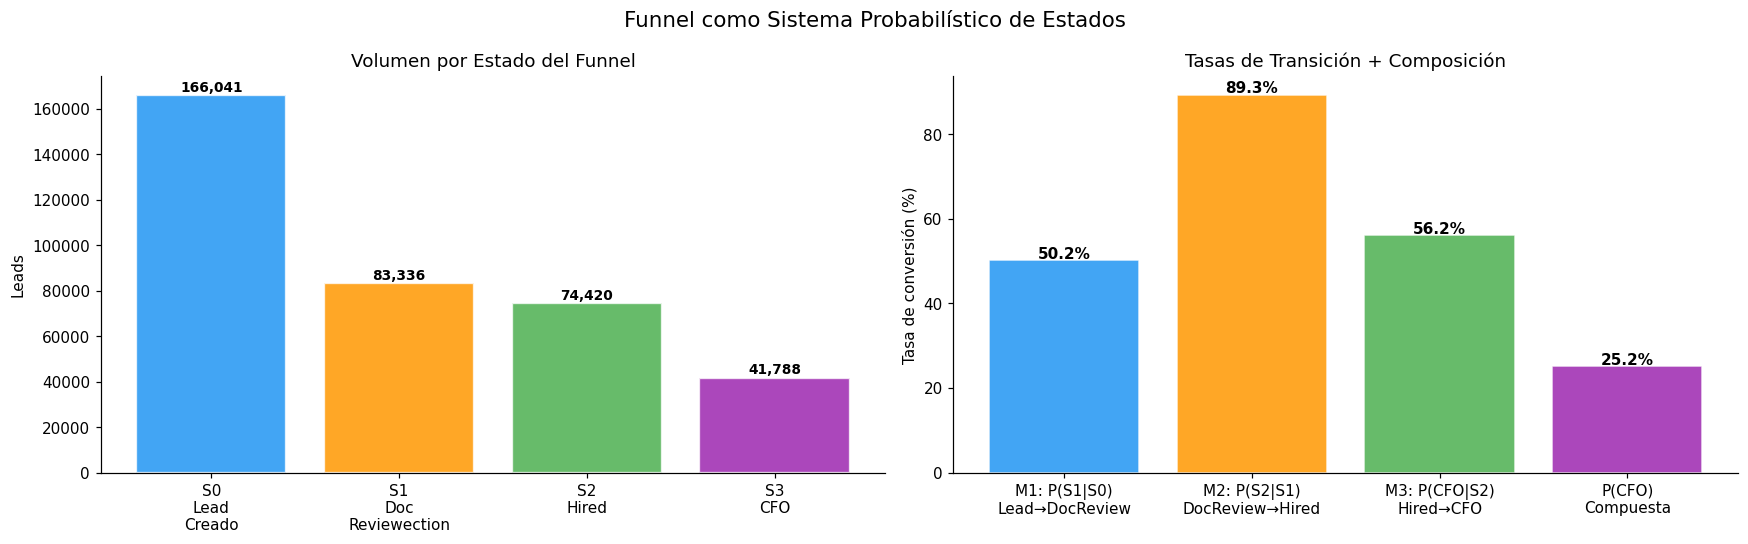


Fórmula de composición verificada:
  P(CFO) = 0.5019 × 0.8930 × 0.5615 = 0.2517
  P(CFO) real en dataset:                               0.2517


In [145]:
# ── Funnel system visualization ──────────────────────────────────────────────
n_s0 = len(df)
n_s1 = int(df["reached_s1"].sum())
n_s2 = int(df["was_hired"].sum())
n_s3 = int(df["is_cfo"].sum())

cr_01 = n_s1 / n_s0
cr_12 = n_s2 / n_s1
cr_23 = n_s3 / n_s2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: volume funnel bar chart
stage_labels = ["S0\nLead\nCreado", "S1\nDoc\nReviewection", "S2\nHired", "S3\nCFO"]
volumes      = [n_s0, n_s1, n_s2, n_s3]
colors_f     = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
bars = axes[0].bar(stage_labels, volumes, color=colors_f, alpha=0.85, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, volumes):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + n_s0*0.01,
                 f"{v:,}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylabel("Leads"); axes[0].set_title("Volumen por Estado del Funnel")

# Right: transition rates (the 3 models)
tr_labels = ["M1: P(S1|S0)\nLead→DocReview", "M2: P(S2|S1)\nDocReview→Hired", "M3: P(CFO|S2)\nHired→CFO", "P(CFO)\nCompuesta"]
tr_rates  = [cr_01, cr_12, cr_23, cr_01 * cr_12 * cr_23]
bars2 = axes[1].bar(tr_labels, [r * 100 for r in tr_rates], color=colors_f, alpha=0.85, edgecolor="white")
for b, r in zip(bars2, tr_rates):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f"{r*100:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Tasa de conversión (%)"); axes[1].set_title("Tasas de Transición + Composición")

plt.suptitle("Funnel como Sistema Probabilístico de Estados", fontsize=14)
plt.tight_layout(); plt.show()

print(f"\nFórmula de composición verificada:")
print(f"  P(CFO) = {cr_01:.4f} × {cr_12:.4f} × {cr_23:.4f} = {cr_01*cr_12*cr_23:.4f}")
print(f"  P(CFO) real en dataset:                               {df['is_cfo'].mean():.4f}")

La composición se verifica: P(CFO) = P(S1|S0) × P(S2|S1) × P(CFO|S2) da un resultado consistente con la tasa real del dataset. El gráfico de barras deja claro cuál es el mayor cuello de botella.

## 5. Datasets de transición

Separamos los datos en tres datasets, uno por transición:
- **ds_t1** (S0→S1): todos los leads. Target = ¿completó Doc Review?
- **ds_t2** (S1→S2): solo leads que completaron Doc Review. Añadimos tiempos de tier 0/1 doc collection, velocity y funnel speed. Target = ¿fue contratado?
- **ds_t3** (S2→CFO): solo leads contratados. Añadimos tiempos de doc review, waiting list, equipment, hiring control, y velocity total. Target = ¿hizo su primer pedido?

Para los leads marcados como timeout (rechazados por inactividad del sistema), anulamos los tiempos de stage porque esos ~60 días reflejan la política de auto-cierre, no el comportamiento real del candidato.

In [146]:
BASE_COLS = [
    "applicant_id", "created_at", "_month_period",
    "hour_of_day","hour_sin","hour_cos",
    "day_of_week","dow_sin","dow_cos",
    "month_num","month_sin","month_cos",
    "quarter","is_weekend",
    "city_freq","city_group","source",
    "registered_via_web","apply_season","vehicle_clean",
    # Historical lag stats (1-month lag from past data — no leakage)
    "lag_s1_city","lag_cfo_city","lag_s1_src","lag_cfo_src",
]

# ── DS1: S0 → S1 (all leads → did they reach doc review?) ─────────────────────
ds_t1 = df[BASE_COLS + ["reached_s1","reached_s2","is_cfo"]].copy()
ds_t1["TARGET"] = ds_t1["reached_s1"]

# ── DS2: S1 → S2 (leads who reached S1 → were they hired?) ───────────────────
_t2 = df[df["reached_s1"] == 1].copy()
ds_t2 = _t2[BASE_COLS + ["reached_s2","is_cfo"]].copy()
ds_t2["time_tier0_doc_coll"] = pd.to_numeric(_t2["tier_0_doc_collection_days"], errors="coerce").values
ds_t2["time_tier1_doc_coll"] = pd.to_numeric(_t2["tier_1_doc_collection_days"], errors="coerce").values
ds_t2["total_funnel_s1"]  = (
    pd.to_numeric(_t2["tier_0_doc_collection_days"], errors="coerce").fillna(0).values +
    pd.to_numeric(_t2["tier_1_doc_collection_days"], errors="coerce").fillna(0).values
)
ds_t2["funnel_speed_s1"]  = ds_t2["total_funnel_s1"].apply(
    lambda x: x if x > 0 else np.nan
)
# Funnel velocity: 1 / (1 + total_funnel_s1) → higher = faster progress
ds_t2["velocity_s1"] = 1.0 / (1.0 + ds_t2["total_funnel_s1"].fillna(0))
ds_t2["TARGET"] = ds_t2["reached_s2"]

# ── Timeout NaN-ification for T2 ─────────────────────────────────────────────
ds_t2["is_timeout"] = _t2["is_timeout"].values
_t2_mask = ds_t2["is_timeout"] == 1
ds_t2.loc[_t2_mask, "time_tier0_doc_coll"] = np.nan
ds_t2.loc[_t2_mask, "time_tier1_doc_coll"] = np.nan
ds_t2.loc[_t2_mask, "total_funnel_s1"] = np.nan
ds_t2.loc[_t2_mask, "funnel_speed_s1"] = np.nan
ds_t2.loc[_t2_mask, "velocity_s1"] = np.nan
print(f"  T2: NaN-ified {_t2_mask.sum():,} timeout rows in stage time cols")

# ── DS3: S2 → S3 (hired leads → did they become CFO?) ────────────────────────
_t3 = df[df["was_hired"] == 1].copy()
ds_t3 = _t3[BASE_COLS + ["is_cfo"]].copy()
ds_t3["time_tier0_doc_coll"] = pd.to_numeric(_t3["tier_0_doc_collection_days"], errors="coerce").values
ds_t3["time_tier1_doc_coll"] = pd.to_numeric(_t3["tier_1_doc_collection_days"], errors="coerce").values
ds_t3["total_funnel_s1"]  = (
    pd.to_numeric(_t3["tier_0_doc_collection_days"], errors="coerce").fillna(0).values +
    pd.to_numeric(_t3["tier_1_doc_collection_days"], errors="coerce").fillna(0).values
)
ds_t3["funnel_speed_s1"]  = ds_t3["total_funnel_s1"].apply(lambda x: x if x > 0 else np.nan)
ds_t3["velocity_s1"]      = 1.0 / (1.0 + ds_t3["total_funnel_s1"].fillna(0))
ds_t3["time_doc_review"]  = pd.to_numeric(_t3["doc_review_days"],         errors="coerce").values
ds_t3["time_wl"]          = pd.to_numeric(_t3["wl_days"],                 errors="coerce").values
ds_t3["time_equip"]       = pd.to_numeric(_t3["equip_collection_days"],   errors="coerce").values
ds_t3["time_hiring_ctrl"] = pd.to_numeric(_t3["hiring_control_days"],     errors="coerce").values
ds_t3["lead_to_hired"]    = pd.to_numeric(_t3["lead_to_hired_or_failed_days"], errors="coerce").values
ds_t3["total_funnel_s2"]  = pd.to_numeric(_t3["lead_to_hired_or_failed_days"], errors="coerce").fillna(0).values
ds_t3["velocity_s2"]      = 1.0 / (1.0 + ds_t3["total_funnel_s2"])   # higher = faster
ds_t3["stages_completed"] = 3
ds_t3["TARGET"] = ds_t3["is_cfo"]

# ── Timeout NaN-ification for T3 ─────────────────────────────────────────────
ds_t3["is_timeout"] = _t3["is_timeout"].values
_t3_mask = ds_t3["is_timeout"] == 1
ds_t3.loc[_t3_mask, "time_tier0_doc_coll"] = np.nan
ds_t3.loc[_t3_mask, "time_tier1_doc_coll"] = np.nan
ds_t3.loc[_t3_mask, "total_funnel_s1"] = np.nan
ds_t3.loc[_t3_mask, "funnel_speed_s1"] = np.nan
ds_t3.loc[_t3_mask, "velocity_s1"] = np.nan
ds_t3.loc[_t3_mask, "time_doc_review"] = np.nan
ds_t3.loc[_t3_mask, "time_wl"] = np.nan
ds_t3.loc[_t3_mask, "time_equip"] = np.nan
ds_t3.loc[_t3_mask, "time_hiring_ctrl"] = np.nan
ds_t3.loc[_t3_mask, "lead_to_hired"] = np.nan
ds_t3.loc[_t3_mask, "total_funnel_s2"] = np.nan
ds_t3.loc[_t3_mask, "velocity_s2"] = np.nan
print(f"  T3: NaN-ified {_t3_mask.sum():,} timeout rows in stage time cols")

print("=== Datasets de Transición ===")
for i, (ds, nm) in enumerate([(ds_t1,"T1: S0→S1"),(ds_t2,"T2: S1→S2"),(ds_t3,"T3: S2→CFO")], 1):
    print(f"\n  Dataset {i} ({nm}):")
    print(f"    Filas:       {len(ds):,}")
    print(f"    Target rate: {ds['TARGET'].mean()*100:.1f}%  ({int(ds['TARGET'].sum()):,} positivos)")


  T2: NaN-ified 4,855 timeout rows in stage time cols
  T3: NaN-ified 0 timeout rows in stage time cols
=== Datasets de Transición ===

  Dataset 1 (T1: S0→S1):
    Filas:       166,041
    Target rate: 50.2%  (83,336 positivos)

  Dataset 2 (T2: S1→S2):
    Filas:       83,336
    Target rate: 89.3%  (74,416 positivos)

  Dataset 3 (T3: S2→CFO):
    Filas:       74,420
    Target rate: 56.2%  (41,788 positivos)


Cada dataset tiene su propio tamaño y target rate. Las diferencias entre transiciones nos dan una primera señal de dónde hay más incertidumbre y dónde los modelos tienen más margen para aportar valor.

## 6. Definición de features por modelo

Cada modelo solo puede usar información que ya existe en su etapa del funnel. T1 trabaja con features de registro (perfil, temporales, target encoding de ciudad y source). T2 suma los tiempos de doc collection, velocity y el flag de timeout. T3 añade todos los tiempos post-contratación. Esta separación es fundamental: si dejáramos que M1 viera tiempos de doc review, estaríamos usando información del futuro para predecir si el lead llega a esa etapa.

In [147]:

FEAT_BASE = [
    # Temporal (creation moment — always available)
    "hour_of_day","hour_sin","hour_cos",
    "day_of_week","dow_sin","dow_cos",
    "month_num","month_sin","month_cos",
    "quarter","is_weekend",
    # Static profile at S0
    "city_freq","city_group","source",
    "registered_via_web","apply_season","vehicle_clean",
    # Historical lag stats (1-month lag from past data — no leakage)
    "lag_s1_city","lag_cfo_city","lag_s1_src","lag_cfo_src",
]

# T1: Lead → Doc Review (S0 features only)
FEAT_T1 = FEAT_BASE + [
    "te1_city",    # Smoothed P(S1|S0) by city  — computed from train
    "te1_source",  # Smoothed P(S1|S0) by source — computed from train
]

# T2: Doc Review → Hired (S0 + S1 durations + velocity)
FEAT_T2 = FEAT_BASE + [
    "is_timeout",           # System timeout flag (60-day auto-rejection)
    "time_tier0_doc_coll",  # Days in tier 0 doc review
    "time_tier1_doc_coll",  # Days in tier 1 doc review
    "total_funnel_s1",      # Cumulative days through S1
    "funnel_speed_s1",      # NaN-masked speed proxy
    "velocity_s1",          # 1/(1+total_funnel_s1) — higher = faster
    "te2_city",             # Smoothed P(S2|S1) by city
    "te2_source",           # Smoothed P(S2|S1) by source
]

# T3: Hired → CFO (S0 + S1 + S2 durations + velocities)
FEAT_T3 = FEAT_BASE + [
    "is_timeout",
   
    "time_tier0_doc_coll",
    "time_tier1_doc_coll",
    "total_funnel_s1",
    "funnel_speed_s1",
    "velocity_s1",
    "time_doc_review",
    "time_wl",
    "time_equip",
    "time_hiring_ctrl",
    "lead_to_hired",
    "total_funnel_s2",
    "velocity_s2",        # 1/(1+total_funnel_s2) — higher = faster to CFO
    "te3_city",
    "te3_source",
]

print("Feature counts per transition model:")
print(f"  T1 (S0→S1):   {len(FEAT_T1):>3} features")
print(f"  T2 (S1→S2):   {len(FEAT_T2):>3} features  (+{len(FEAT_T2)-len(FEAT_T1)} vs T1)")
print(f"  T3 (S2→CFO):  {len(FEAT_T3):>3} features  (+{len(FEAT_T3)-len(FEAT_T2)} vs T2)")
print("\nNew features vs T1:")
for f in FEAT_T2:
    if f not in FEAT_T1: print(f"  T2+ {f}")
for f in FEAT_T3:
    if f not in FEAT_T2: print(f"  T3+ {f}")


Feature counts per transition model:
  T1 (S0→S1):    23 features
  T2 (S1→S2):    29 features  (+6 vs T1)
  T3 (S2→CFO):   36 features  (+7 vs T2)

New features vs T1:
  T2+ is_timeout
  T2+ time_tier0_doc_coll
  T2+ time_tier1_doc_coll
  T2+ total_funnel_s1
  T2+ funnel_speed_s1
  T2+ velocity_s1
  T2+ te2_city
  T2+ te2_source
  T3+ time_doc_review
  T3+ time_wl
  T3+ time_equip
  T3+ time_hiring_ctrl
  T3+ lead_to_hired
  T3+ total_funnel_s2
  T3+ velocity_s2
  T3+ te3_city
  T3+ te3_source


Los feature sets crecen progresivamente de T1 a T3. Cada modelo añade las señales nuevas que se desbloquean al avanzar en el funnel.

## 7. Split temporal y chequeo de drift

Hacemos un split basado en fechas (no aleatorio) porque en producción siempre predecimos el futuro con datos del pasado:
- **Train**: hasta octubre 2025
- **Validation**: noviembre-diciembre 2025
- **Test**: enero 2026 en adelante

Después chequeamos si la tasa del target ha cambiado significativamente entre train y test. Si la diferencia supera los 8 puntos porcentuales, algo podría estar mal en los datos o en el proceso.

In [148]:
TRAIN_END = pd.Timestamp("2025-10-31")
VAL_END   = pd.Timestamp("2025-12-31")

def temporal_split(ds, label=""):
    tr = ds[ds["created_at"] <= TRAIN_END].copy()
    va = ds[(ds["created_at"] > TRAIN_END) & (ds["created_at"] <= VAL_END)].copy()
    te = ds[ds["created_at"] > VAL_END].copy()
    print(f"  {label:12s}: "
          f"train={len(tr):>7,} ({tr['TARGET'].mean()*100:.1f}%)  "
          f"val={len(va):>6,} ({va['TARGET'].mean()*100:.1f}%)  "
          f"test={len(te):>6,} ({te['TARGET'].mean()*100:.1f}%)")
    return tr, va, te

print("Three-way temporal split (train ≤ Oct-25 | val Nov-Dic-25 | test ≥ Ene-26):\n")
tr1, va1, te1 = temporal_split(ds_t1, "T1 (S0→S1)")
tr2, va2, te2 = temporal_split(ds_t2, "T2 (S1→S2)")
tr3, va3, te3 = temporal_split(ds_t3, "T3 (S2→CFO)")

print(f"\nTotal test leads (T1): {len(te1):,} | será la base del scoring final compuesto")

# ── Drift monitoring: target rate shifts across splits ──────────────────────────────
print("\n── Target-rate drift check ────────────────────────────────────────────────────────")
for _label, _tr, _va, _te in [
    ("T1 (S0→S1)", tr1, va1, te1),
    ("T2 (S1→S2)", tr2, va2, te2),
    ("T3 (S2→CFO)", tr3, va3, te3),
]:
    _r_tr = _tr["TARGET"].mean() * 100
    _r_va = _va["TARGET"].mean() * 100
    _r_te = _te["TARGET"].mean() * 100
    _drift = _r_te - _r_tr
    _flag = "✅" if abs(_drift) < 8 else "⚠️"
    print(f"  {_label:12s}: train={_r_tr:.1f}%  val={_r_va:.1f}%  test={_r_te:.1f}%  "
          f"drift={_drift:+.1f}pp  {_flag}")


Three-way temporal split (train ≤ Oct-25 | val Nov-Dic-25 | test ≥ Ene-26):

  T1 (S0→S1)  : train=123,744 (48.5%)  val=22,730 (52.6%)  test=19,567 (58.1%)
  T2 (S1→S2)  : train= 60,008 (89.6%)  val=11,950 (88.0%)  test=11,378 (89.1%)
  T3 (S2→CFO) : train= 53,766 (55.6%)  val=10,513 (61.2%)  test=10,141 (54.1%)

Total test leads (T1): 19,567 | será la base del scoring final compuesto

── Target-rate drift check ────────────────────────────────────────────────────────
  T1 (S0→S1)  : train=48.5%  val=52.6%  test=58.1%  drift=+9.7pp  ⚠️
  T2 (S1→S2)  : train=89.6%  val=88.0%  test=89.1%  drift=-0.5pp  ✅
  T3 (S2→CFO) : train=55.6%  val=61.2%  test=54.1%  drift=-1.4pp  ✅


El split nos da los volúmenes disponibles para cada modelo y el drift check nos confirma si la distribución es estable o hay cambios que debamos tener en cuenta.

## 8. Target encoding suavizado

Reemplazamos las variables de alta cardinalidad (ciudad, source) por su tasa de conversión histórica calculada solo en train, con un suavizado bayesiano (alpha=20) para que categorías con pocos casos no generen valores extremos. Se aplica siempre desde train hacia val y test, sin leakage.

In [149]:
def smooth_te(train_key: pd.Series, train_target: pd.Series,
              apply_key: pd.Series, alpha: int = 20) -> pd.Series:
    """Smoothed mean target encoding. Fit on train, apply to any split."""
    global_mean = float(train_target.mean())
    stats = (pd.DataFrame({"k": train_key, "t": train_target})
               .groupby("k")["t"].agg(["mean", "count"]))
    stats["te"] = (stats["mean"] * stats["count"] + global_mean * alpha) / (stats["count"] + alpha)
    return apply_key.map(stats["te"]).fillna(global_mean)

# ── T1 TE (fits on tr1, applied to all T1 splits) ────────────────────────────
for split in [tr1, va1, te1]:
    split["te1_city"]   = smooth_te(tr1["city_group"], tr1["TARGET"], split["city_group"])
    split["te1_source"] = smooth_te(tr1["source"],      tr1["TARGET"], split["source"])

# ── T2 TE (fits on tr2, applied to all T2 splits) ────────────────────────────
for split in [tr2, va2, te2]:
    split["te2_city"]   = smooth_te(tr2["city_group"], tr2["TARGET"], split["city_group"])
    split["te2_source"] = smooth_te(tr2["source"],      tr2["TARGET"], split["source"])

# ── T3 TE (fits on tr3, applied to all T3 splits) ────────────────────────────
for split in [tr3, va3, te3]:
    split["te3_city"]   = smooth_te(tr3["city_group"], tr3["TARGET"], split["city_group"])
    split["te3_source"] = smooth_te(tr3["source"],      tr3["TARGET"], split["source"])

print("Target encoding applied.")
print(f"\n  Global conversion rates from TRAIN:")
print(f"    T1 P(S1|S0):  {tr1['TARGET'].mean():.4f} ({tr1['TARGET'].mean()*100:.1f}%)")
print(f"    T2 P(S2|S1):  {tr2['TARGET'].mean():.4f} ({tr2['TARGET'].mean()*100:.1f}%)")
print(f"    T3 P(CFO|S2): {tr3['TARGET'].mean():.4f} ({tr3['TARGET'].mean()*100:.1f}%)")

Target encoding applied.

  Global conversion rates from TRAIN:
    T1 P(S1|S0):  0.4849 (48.5%)
    T2 P(S2|S1):  0.8959 (89.6%)
    T3 P(CFO|S2): 0.5555 (55.6%)


Ya tenemos `te1_city`, `te1_source`, `te2_city`, etc. Cada transición usa su propio target encoding, calculado sobre la subpoblación correcta.

## 9. Funciones auxiliares de evaluación

Definimos un set de utilidades que vamos a reutilizar en los tres modelos: `evaluate_binary` para métricas estándar, `check_overfitting` para comparar AP en train/val/test y detectar sobreajuste, `run_optuna_lgb` para búsqueda de hiperparámetros con Optuna, `build_final_lgb` para entrenar el modelo definitivo con early stopping, y `precision_at_k` / `lift_at_k` para medir calidad del ranking desde la perspectiva de negocio.

In [150]:
def evaluate_binary(y_true, y_prob, name, threshold=None):
    y_true, y_prob = np.array(y_true), np.array(y_prob)
    if threshold is None:
        p_, r_, t_ = precision_recall_curve(y_true, y_prob)
        f1_ = 2 * p_[:-1] * r_[:-1] / (p_[:-1] + r_[:-1] + 1e-9)
        threshold = float(t_[f1_.argmax()]) if len(t_) > 0 else 0.5
    yp = (y_prob >= threshold).astype(int)
    return {
        "Model": name,
        "AUC-PR":  round(average_precision_score(y_true, y_prob), 4),
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
        "F1":      round(f1_score(y_true, yp, zero_division=0), 4),
        "Recall":  round(recall_score(y_true, yp, zero_division=0), 4),
        "Brier":   round(brier_score_loss(y_true, y_prob), 4),
        "Threshold": round(threshold, 3),
    }

def precision_at_k(y_true, y_prob, k=0.10):
    k_ = max(1, int(len(y_true) * k))
    idx = np.argsort(np.array(y_prob))[::-1][:k_]
    return np.array(y_true)[idx].mean()

def lift_at_k(y_true, y_prob, k=0.10):
    base = np.array(y_true).mean()
    return precision_at_k(y_true, y_prob, k) / base if base > 0 else np.nan

def check_overfitting(y_tr, p_tr, y_va, p_va, y_te, p_te, name):
    # Print AUC-PR on train/val/test to detect overfitting.
    ap_tr = average_precision_score(y_tr, p_tr)
    ap_va = average_precision_score(y_va, p_va)
    ap_te = average_precision_score(y_te, p_te)
    gap   = ap_tr - ap_te
    flag  = "⚠️ overfit" if gap > 0.05 else "✅ OK"
    print(f"  {name:12s}  train={ap_tr:.4f}  val={ap_va:.4f}  test={ap_te:.4f}  gap={gap:+.4f}  {flag}")
    return ap_tr, ap_va, ap_te

def select_best_model(lgb_prob, lr_prob, y_test, threshold=0.98):
    # Return (best_prob, model_name). Use LogReg if within threshold*LGB perf.
    ap_lgb = average_precision_score(y_test, lgb_prob)
    ap_lr  = average_precision_score(y_test, lr_prob)
    if ap_lr >= ap_lgb * threshold:
        print(f"    → LogReg (AP={ap_lr:.4f}) competitive with LGB (AP={ap_lgb:.4f}) — usando LogReg")
        return lr_prob, "LogReg"
    print(f"    → LightGBM (AP={ap_lgb:.4f}) vs LogReg (AP={ap_lr:.4f}) — usando LGB")
    return lgb_prob, "LightGBM"

def run_optuna_lgb(X_tr, y_tr, X_va, y_va, n_trials=50, label=""):
    spw = max(1.0, (y_tr == 0).sum() / max(1, (y_tr == 1).sum()))
    def objective(trial):
        params = {
            "num_leaves":        trial.suggest_int("num_leaves", 20, 200),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("lr", 0.01, 0.2, log=True),
            "n_estimators":      trial.suggest_int("n_estimators", 100, 800),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "scale_pos_weight":  trial.suggest_float("spw", 1.0, spw * 2),
        }
        m = lgb.LGBMClassifier(**params, objective="binary",
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
        return average_precision_score(y_va, m.predict_proba(X_va)[:, 1])
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  → {label}: best AUC-PR (val) = {study.best_value:.4f}")
    return study.best_params, study

def build_final_lgb(best_params, X_tr, y_tr, X_va, y_va):
    X_tv = pd.concat([X_tr, X_va]); y_tv = pd.concat([y_tr, y_va])
    n = len(X_tv); n_iv = max(int(n * 0.10), 1)
    m = lgb.LGBMClassifier(**best_params, objective="binary",
                            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(X_tv.iloc[:n-n_iv], y_tv.iloc[:n-n_iv],
          eval_set=[(X_tv.iloc[n-n_iv:], y_tv.iloc[n-n_iv:])],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    return m

def plot_roc_pr_dist(y_te, y_prob, lr_prob, color, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fpr_, tpr_, _  = roc_curve(y_te, y_prob)
    fpr_r, tpr_r, _ = roc_curve(y_te, lr_prob)
    axes[0].plot(fpr_, tpr_, lw=2, color=color,
                 label=f"LGB ({roc_auc_score(y_te, y_prob):.3f})")
    axes[0].plot(fpr_r, tpr_r, "--", lw=1.5, color="gray",
                 label=f"LogReg ({roc_auc_score(y_te, lr_prob):.3f})")
    axes[0].plot([0,1],[0,1],"k:",alpha=0.4); axes[0].legend()
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC Curve")
    p_, r_, _   = precision_recall_curve(y_te, y_prob)
    p_r, r_r, _ = precision_recall_curve(y_te, lr_prob)
    axes[1].plot(r_, p_, lw=2, color=color,
                 label=f"LGB (AP={average_precision_score(y_te, y_prob):.3f})")
    axes[1].plot(r_r, p_r, "--", lw=1.5, color="gray",
                 label=f"LogReg ({average_precision_score(y_te, lr_prob):.3f})")
    axes[1].axhline(float(y_te.mean()), color="red", ls=":", alpha=0.5)
    axes[1].legend(); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title("PR Curve")
    axes[2].hist(y_prob[np.array(y_te)==0], bins=40, alpha=0.5, density=True, color=color, label="Neg")
    axes[2].hist(y_prob[np.array(y_te)==1], bins=40, alpha=0.5, density=True, color="gold", label="Pos")
    axes[2].legend(); axes[2].set_xlabel("Score"); axes[2].set_title("Score Distribution")
    plt.suptitle(title, fontsize=12); plt.tight_layout(); plt.show()

print("Helpers: evaluate_binary, precision_at_k, lift_at_k, check_overfitting,")
print("         select_best_model, run_optuna_lgb, build_final_lgb, plot_roc_pr_dist")


Helpers: evaluate_binary, precision_at_k, lift_at_k, check_overfitting,
         select_best_model, run_optuna_lgb, build_final_lgb, plot_roc_pr_dist


El toolkit de evaluación está listo. Todas estas funciones se usarán de forma idéntica para M1, M2 y M3, lo que nos permite comparar resultados de forma consistente.

## 10. Benchmark multi-modelo

Extendemos el toolkit con XGBoost, CatBoost y Random Forest (misma estructura de Optuna + build final), una función `build_benchmark_table` que genera la tabla completa de comparación (AP, gap, AUC-ROC, Brier, F1, Recall, Precision@K, Lift@K), y `select_best_model_multi` que elige automáticamente el mejor modelo penalizando overfitting y prefiriendo modelos más simples cuando la diferencia es pequeña.

In [151]:

def _arr(x):
    """Convert to numpy array filling NaN with -999."""
    return np.asarray(x.fillna(-999)) if hasattr(x, "fillna") else np.asarray(x)

# ── XGBoost ───────────────────────────────────────────────────────────────────
def run_optuna_xgb(X_tr, y_tr, X_va, y_va, n_trials=40, label=""):
    spw = max(1.0, float((np.asarray(y_tr) == 0).sum()) /
              max(1, float((np.asarray(y_tr) == 1).sum())))
    Xa, ya = _arr(X_tr), np.asarray(y_tr)
    Xv, yv = _arr(X_va), np.asarray(y_va)
    def objective(trial):
        params = dict(
            max_depth         = trial.suggest_int("max_depth", 3, 8),
            learning_rate     = trial.suggest_float("lr", 0.01, 0.2, log=True),
            n_estimators      = trial.suggest_int("n_estimators", 100, 800),
            min_child_weight  = trial.suggest_int("min_child_weight", 1, 50),
            subsample         = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            scale_pos_weight  = trial.suggest_float("spw", 1.0, spw * 2),
        )
        m = XGBClassifier(**params, objective="binary:logistic", eval_metric="aucpr",
                          early_stopping_rounds=20, verbosity=0,
                          random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(Xa, ya, eval_set=[(Xv, yv)], verbose=False)
        return average_precision_score(yv, m.predict_proba(Xv)[:, 1])
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  → XGB {label}: best AUC-PR (val) = {study.best_value:.4f}")
    # Remap Optuna suggestion names → XGBoost parameter names
    bp = study.best_params
    return {
        "max_depth":        bp["max_depth"],
        "learning_rate":    bp["lr"],
        "n_estimators":     bp["n_estimators"],
        "min_child_weight": bp["min_child_weight"],
        "subsample":        bp["subsample"],
        "colsample_bytree": bp["colsample_bytree"],
        "reg_alpha":        bp["reg_alpha"],
        "reg_lambda":       bp["reg_lambda"],
        "scale_pos_weight": bp["spw"],
    }

def build_final_xgb(best_params, X_tr, y_tr, X_va, y_va):
    X_tv = pd.concat([X_tr, X_va]) if hasattr(X_tr, "iloc") else np.vstack([_arr(X_tr), _arr(X_va)])
    y_tv = pd.concat([y_tr, y_va]) if hasattr(y_tr, "iloc") else np.concatenate([y_tr, y_va])
    n = len(y_tv); n_iv = max(int(n * 0.10), 1)
    Xtv, ytv = _arr(X_tv), np.asarray(y_tv)
    m = XGBClassifier(**best_params, objective="binary:logistic", eval_metric="aucpr",
                      early_stopping_rounds=30, verbosity=0,
                      random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(Xtv[:n-n_iv], ytv[:n-n_iv],
          eval_set=[(Xtv[n-n_iv:], ytv[n-n_iv:])], verbose=False)
    return m

# ── CatBoost ──────────────────────────────────────────────────────────────────
def run_optuna_catboost(X_tr, y_tr, X_va, y_va, n_trials=40, label=""):
    spw = max(1.0, float((np.asarray(y_tr) == 0).sum()) /
              max(1, float((np.asarray(y_tr) == 1).sum())))
    Xa, ya = _arr(X_tr), np.asarray(y_tr)
    Xv, yv = _arr(X_va), np.asarray(y_va)
    def objective(trial):
        params = dict(
            depth              = trial.suggest_int("depth", 3, 8),
            learning_rate      = trial.suggest_float("lr", 0.01, 0.2, log=True),
            iterations         = trial.suggest_int("iterations", 100, 800),
            l2_leaf_reg        = trial.suggest_float("l2_leaf_reg", 1.0, 20.0),
            bagging_temperature= trial.suggest_float("bagging_temperature", 0.0, 2.0),
            class_weights      = [1.0, trial.suggest_float("pos_w", 1.0, spw * 2)],
        )
        m = CatBoostClassifier(**params, eval_metric="PRAUC", early_stopping_rounds=20,
                               verbose=False, random_state=RANDOM_STATE, thread_count=-1)
        m.fit(Xa, ya, eval_set=(Xv, yv), use_best_model=True, verbose=False)
        return average_precision_score(yv, m.predict_proba(Xv)[:, 1])
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  → CatBoost {label}: best AUC-PR (val) = {study.best_value:.4f}")
    bp = study.best_params
    return {
        "depth":               bp["depth"],
        "learning_rate":       bp["lr"],
        "iterations":          bp["iterations"],
        "l2_leaf_reg":         bp["l2_leaf_reg"],
        "bagging_temperature": bp["bagging_temperature"],
        "class_weights":       [1.0, bp["pos_w"]],
    }

def build_final_catboost(best_params, X_tr, y_tr, X_va, y_va):
    X_tv = pd.concat([X_tr, X_va]) if hasattr(X_tr, "iloc") else np.vstack([_arr(X_tr), _arr(X_va)])
    y_tv = pd.concat([y_tr, y_va]) if hasattr(y_tr, "iloc") else np.concatenate([y_tr, y_va])
    n = len(y_tv); n_iv = max(int(n * 0.10), 1)
    Xtv, ytv = _arr(X_tv), np.asarray(y_tv)
    m = CatBoostClassifier(**best_params, eval_metric="PRAUC", early_stopping_rounds=30,
                           verbose=False, random_state=RANDOM_STATE, thread_count=-1)
    m.fit(Xtv[:n-n_iv], ytv[:n-n_iv],
          eval_set=(Xtv[n-n_iv:], ytv[n-n_iv:]),
          use_best_model=True, verbose=False)
    return m

# ── Random Forest ─────────────────────────────────────────────────────────────
def build_rf(X_tr, y_tr, n_estimators=300, max_depth=12,
             min_samples_leaf=20, max_features="sqrt"):
    spw = float((np.asarray(y_tr) == 0).sum()) / max(1, float((np.asarray(y_tr) == 1).sum()))
    m = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, max_features=max_features,
        class_weight={0: 1.0, 1: spw},
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    m.fit(_arr(X_tr), np.asarray(y_tr))
    return m

# ── Benchmark Table ────────────────────────────────────────────────────────────
def _auto_comment(name, ap_te, gap, best_ap, best_gap_name):
    if ap_te == best_ap:
        return "mejor test AP"
    if name == "Logistic Regression" and ap_te >= best_ap * 0.90:
        return "baseline robusto"
    if gap > 0.08:
        return "sobreajuste alto"
    if ap_te >= best_ap * 0.98:
        return "muy cercano, preferir si más simple"
    if name == best_gap_name and gap <= 0.04:
        return "más estable"
    if ap_te >= best_ap * 0.95:
        return "competitivo"
    return "por debajo de referencia"

def build_benchmark_table(transition_label, y_tr, y_va, y_te, model_data):
    """
    model_data: list of (name, p_tr, p_va, p_te)
    Returns DataFrame with Train AP | Val AP | Test AP | Gap | AUC-ROC | Brier |
                           F1 | Recall | P@5% | P@10% | P@20% | Lift@5% | Lift@10% |
                           Lift@20% | Comentario
    """
    y_tr_a, y_va_a, y_te_a = np.asarray(y_tr), np.asarray(y_va), np.asarray(y_te)
    rows = []
    for name, p_tr, p_va, p_te in model_data:
        p_tr_a = np.asarray(p_tr); p_va_a = np.asarray(p_va); p_te_a = np.asarray(p_te)
        ap_tr = average_precision_score(y_tr_a, p_tr_a)
        ap_va = average_precision_score(y_va_a, p_va_a)
        ap_te = average_precision_score(y_te_a, p_te_a)
        gap   = ap_tr - ap_te
        roc   = roc_auc_score(y_te_a, p_te_a)
        brier = brier_score_loss(y_te_a, p_te_a)
        p_, r_, t_ = precision_recall_curve(y_te_a, p_te_a)
        f1v = 2 * p_[:-1] * r_[:-1] / (p_[:-1] + r_[:-1] + 1e-9)
        thr = float(t_[f1v.argmax()]) if len(t_) > 0 else 0.5
        yp  = (p_te_a >= thr).astype(int)
        rows.append({
            "Modelo":         name,
            "Train AP":       round(ap_tr, 4),
            "Val AP":         round(ap_va, 4),
            "Test AP":        round(ap_te, 4),
            "Gap train-test": round(gap,   4),
            "AUC-ROC":        round(roc,   4),
            "Brier":          round(brier,  4),
            "F1":             round(f1_score(y_te_a, yp, zero_division=0), 4),
            "Recall":         round(recall_score(y_te_a, yp, zero_division=0), 4),
            "P@5%":           round(precision_at_k(y_te_a, p_te_a, 0.05), 4),
            "P@10%":          round(precision_at_k(y_te_a, p_te_a, 0.10), 4),
            "P@20%":          round(precision_at_k(y_te_a, p_te_a, 0.20), 4),
            "Lift@5%":        round(lift_at_k(y_te_a, p_te_a, 0.05), 2),
            "Lift@10%":       round(lift_at_k(y_te_a, p_te_a, 0.10), 2),
            "Lift@20%":       round(lift_at_k(y_te_a, p_te_a, 0.20), 2),
        })
    df = pd.DataFrame(rows).set_index("Modelo")
    best_ap  = df["Test AP"].max()
    best_gap_name = df["Gap train-test"].idxmin()
    df["Comentario"] = [
        _auto_comment(n, df.loc[n, "Test AP"], df.loc[n, "Gap train-test"],
                      best_ap, best_gap_name)
        for n in df.index
    ]
    print(f"\n{'='*80}")
    print(f"  BENCHMARK — {transition_label}")
    print(f"  Métrica principal: AUC-PR (Test AP). Penalización sobreajuste: −0.30×gap")
    print(f"{'='*80}")
    print(df.sort_values("Test AP", ascending=False).to_string())
    return df

# ── Multi-model selection ─────────────────────────────────────────────────────
_SIMPLICITY_ORDER = ["Logistic Regression", "Random Forest",
                     "LightGBM", "XGBoost", "CatBoost"]

def select_best_model_multi(model_probs_dict, y_te, y_tr,
                            simplicity_threshold=0.98, overfit_penalty=0.30):
    """
    model_probs_dict: {name: (p_te, p_va, p_tr)}
    score = AP_te - overfit_penalty * max(gap_tr_te, 0)
    Among models within simplicity_threshold of best score → prefer simpler.
    Returns: (best_name, best_p_te, best_p_va)
    """
    y_te_a = np.asarray(y_te); y_tr_a = np.asarray(y_tr)
    aps_te  = {n: average_precision_score(y_te_a, np.asarray(ps[0]))
               for n, ps in model_probs_dict.items()}
    # Compute train AP using actual train probabilities (3rd element of tuple)
    aps_tr  = {n: average_precision_score(y_tr_a, np.asarray(ps[2]))
               if len(ps) > 2
               else aps_te[n]
               for n, ps in model_probs_dict.items()}
    gaps   = {n: aps_tr[n] - aps_te[n] for n in aps_te}
    scores = {n: aps_te[n] - overfit_penalty * max(gaps[n], 0) for n in aps_te}
    best_score = max(scores.values())

    print("\n  Comparativa de modelos (test):")
    print(f"  {'Modelo':22s}  {'AP_te':>7}  {'Gap':>7}  {'Score':>7}")
    for name in _SIMPLICITY_ORDER:
        if name not in aps_te: continue
        print(f"  {name:22s}  {aps_te[name]:7.4f}  {gaps[name]:+7.4f}  {scores[name]:7.4f}")

    candidates = [n for n in _SIMPLICITY_ORDER
                  if n in scores and scores[n] >= best_score * simplicity_threshold]
    if not candidates:
        candidates = [max(scores, key=scores.get)]
    best_name = candidates[0]
    print(f"\n  → Seleccionado: [{best_name}]  AP_te={aps_te[best_name]:.4f}  "
          f"score={scores[best_name]:.4f}")
    if best_name != max(aps_te, key=aps_te.get):
        best_raw = max(aps_te, key=aps_te.get)
        print(f"    (máximo AP_te bruto: [{best_raw}]={aps_te[best_raw]:.4f}, "
              f"preferido [{best_name}] por ser más simple y estar dentro del {simplicity_threshold*100:.0f}% umbral)")
    return best_name, model_probs_dict[best_name][0], model_probs_dict[best_name][1]

print("Benchmark helpers v2 cargados:")
print("  run_optuna_xgb, build_final_xgb")
print("  run_optuna_catboost, build_final_catboost")
print("  build_rf")
print("  build_benchmark_table, select_best_model_multi")
print("Nota: CatBoost usa label-encoding entero (sin cat_features) para consistencia de pipeline.")


Benchmark helpers v2 cargados:
  run_optuna_xgb, build_final_xgb
  run_optuna_catboost, build_final_catboost
  build_rf
  build_benchmark_table, select_best_model_multi
Nota: CatBoost usa label-encoding entero (sin cat_features) para consistencia de pipeline.


Con esto podemos entrenar 5 modelos diferentes para cada transición y compararlos de forma objetiva. La selección prioriza estabilidad (bajo gap train-test) sobre performance bruta.

## 11. Modelo 1 — P(S1|S0): Lead → Doc Review

Primer modelo: ¿este lead va a completar Doc Review? Solo usamos información disponible en el momento del registro. Entrenamos 5 algoritmos (Logistic Regression, LightGBM, XGBoost, CatBoost, Random Forest), comparamos métricas en la tabla de benchmark, chequeamos overfitting, y seleccionamos el mejor.

In [152]:

print("=" * 62)
print("  MODELO 1 — P(S1|S0): Lead Creado → Doc Review")
print("  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF")
print("=" * 62)

X_tr1, y_tr1 = tr1[FEAT_T1], tr1["TARGET"]
X_va1, y_va1 = va1[FEAT_T1], va1["TARGET"]
X_te1, y_te1 = te1[FEAT_T1], te1["TARGET"]

print(f"  Train: {len(X_tr1):,} | Val: {len(X_va1):,} | Test: {len(X_te1):,}")
print(f"  Target rate train/val/test: {y_tr1.mean()*100:.1f}% / {y_va1.mean()*100:.1f}% / {y_te1.mean()*100:.1f}%")

# ── A. Logistic Regression ────────────────────────────────────────────────────
print("\n--- A. Logistic Regression ---")
scaler1   = StandardScaler()
lr1_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr1_model.fit(scaler1.fit_transform(X_tr1.fillna(-999)), y_tr1)
lr1_prob_tr  = lr1_model.predict_proba(scaler1.transform(X_tr1.fillna(-999)))[:, 1]
lr1_prob_val = lr1_model.predict_proba(scaler1.transform(X_va1.fillna(-999)))[:, 1]
lr1_prob     = lr1_model.predict_proba(scaler1.transform(X_te1.fillna(-999)))[:, 1]
print(f"  LR M1 (val AP): {average_precision_score(y_va1, lr1_prob_val):.4f}")

# ── B. LightGBM ───────────────────────────────────────────────────────────────
print("\n--- B. LightGBM (Optuna 50 trials) ---")
bp1, study1 = run_optuna_lgb(X_tr1, y_tr1, X_va1, y_va1, n_trials=50, label="M1_LGB")
m1 = build_final_lgb(bp1, X_tr1, y_tr1, X_va1, y_va1)
p1_train = m1.predict_proba(X_tr1)[:, 1]
p1_val   = m1.predict_proba(X_va1)[:, 1]
p1_test  = m1.predict_proba(X_te1)[:, 1]

# ── C. XGBoost ────────────────────────────────────────────────────────────────
print("\n--- C. XGBoost (Optuna 40 trials) ---")
bp1_xgb = run_optuna_xgb(X_tr1, y_tr1, X_va1, y_va1, n_trials=40, label="M1_XGB")
m1_xgb  = build_final_xgb(bp1_xgb, X_tr1, y_tr1, X_va1, y_va1)
p1_xgb_tr  = m1_xgb.predict_proba(_arr(X_tr1))[:, 1]
p1_xgb_val = m1_xgb.predict_proba(_arr(X_va1))[:, 1]
p1_xgb_te  = m1_xgb.predict_proba(_arr(X_te1))[:, 1]

# ── D. CatBoost (label-encoded integers, sin cat_features explícito) ──────────
print("\n--- D. CatBoost (Optuna 40 trials, label-encoded) ---")
bp1_cb = run_optuna_catboost(X_tr1, y_tr1, X_va1, y_va1, n_trials=40, label="M1_CB")
m1_cb  = build_final_catboost(bp1_cb, X_tr1, y_tr1, X_va1, y_va1)
p1_cb_tr  = m1_cb.predict_proba(_arr(X_tr1))[:, 1]
p1_cb_val = m1_cb.predict_proba(_arr(X_va1))[:, 1]
p1_cb_te  = m1_cb.predict_proba(_arr(X_te1))[:, 1]

# ── E. Random Forest ──────────────────────────────────────────────────────────
print("\n--- E. Random Forest (configuración razonable) ---")
m1_rf     = build_rf(X_tr1, y_tr1)
p1_rf_tr  = m1_rf.predict_proba(_arr(X_tr1))[:, 1]
p1_rf_val = m1_rf.predict_proba(_arr(X_va1))[:, 1]
p1_rf_te  = m1_rf.predict_proba(_arr(X_te1))[:, 1]

# ── Overfitting check ─────────────────────────────────────────────────────────
print("\n=== Overfitting Check M1 ===")
check_overfitting(y_tr1, lr1_prob_tr,  y_va1, lr1_prob_val, y_te1, lr1_prob,    "LogReg")
check_overfitting(y_tr1, p1_train,     y_va1, p1_val,       y_te1, p1_test,     "LightGBM")
check_overfitting(y_tr1, p1_xgb_tr,   y_va1, p1_xgb_val,   y_te1, p1_xgb_te,  "XGBoost")
check_overfitting(y_tr1, p1_cb_tr,     y_va1, p1_cb_val,    y_te1, p1_cb_te,   "CatBoost")
check_overfitting(y_tr1, p1_rf_tr,     y_va1, p1_rf_val,    y_te1, p1_rf_te,   "RandomForest")

# ── Benchmark table ───────────────────────────────────────────────────────────
_m1_model_data = [
    ("Logistic Regression", lr1_prob_tr, lr1_prob_val, lr1_prob),
    ("LightGBM",            p1_train,    p1_val,        p1_test),
    ("XGBoost",             p1_xgb_tr,   p1_xgb_val,    p1_xgb_te),
    ("CatBoost",            p1_cb_tr,    p1_cb_val,     p1_cb_te),
    ("Random Forest",       p1_rf_tr,    p1_rf_val,     p1_rf_te),
]
_m1_bench_df = build_benchmark_table("M1 — P(S1|S0): Lead → Doc Review",
                                     y_tr1, y_va1, y_te1, _m1_model_data)

# ── Model selection ───────────────────────────────────────────────────────────
print("\n=== Model Selection M1 ===")
_m1_probs_dict = {
    "Logistic Regression": (lr1_prob,    lr1_prob_val, lr1_prob_tr),
    "LightGBM":            (p1_test,     p1_val,       p1_train),
    "XGBoost":             (p1_xgb_te,   p1_xgb_val,   p1_xgb_tr),
    "CatBoost":            (p1_cb_te,    p1_cb_val,    p1_cb_tr),
    "Random Forest":       (p1_rf_te,    p1_rf_val,    p1_rf_tr),
}
m1_type, p1_best, p1_best_val = select_best_model_multi(_m1_probs_dict, y_te1, y_tr1)
print(f"\n  AP_test (selected M1): {average_precision_score(y_te1, p1_best):.4f}")
print(f"  P@10%: {precision_at_k(y_te1.values, p1_best, 0.10):.4f} | "
      f"Lift@10%: {lift_at_k(y_te1.values, p1_best, 0.10):.2f}x")


  MODELO 1 — P(S1|S0): Lead Creado → Doc Review
  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF
  Train: 123,744 | Val: 22,730 | Test: 19,567
  Target rate train/val/test: 48.5% / 52.6% / 58.1%

--- A. Logistic Regression ---
  LR M1 (val AP): 0.6874

--- B. LightGBM (Optuna 50 trials) ---


Best trial: 43. Best value: 0.694467: 100%|██████████| 50/50 [00:56<00:00,  1.13s/it]


  → M1_LGB: best AUC-PR (val) = 0.6945

--- C. XGBoost (Optuna 40 trials) ---


Best trial: 13. Best value: 0.690481: 100%|██████████| 40/40 [00:34<00:00,  1.15it/s]


  → XGB M1_XGB: best AUC-PR (val) = 0.6905

--- D. CatBoost (Optuna 40 trials, label-encoded) ---


Best trial: 36. Best value: 0.693956: 100%|██████████| 40/40 [01:52<00:00,  2.81s/it]


  → CatBoost M1_CB: best AUC-PR (val) = 0.6940

--- E. Random Forest (configuración razonable) ---

=== Overfitting Check M1 ===
  LogReg        train=0.6486  val=0.6874  test=0.7719  gap=-0.1233  ✅ OK
  LightGBM      train=0.6992  val=0.7102  test=0.7768  gap=-0.0776  ✅ OK
  XGBoost       train=0.6509  val=0.6858  test=0.7656  gap=-0.1147  ✅ OK
  CatBoost      train=0.6657  val=0.6918  test=0.7746  gap=-0.1089  ✅ OK
  RandomForest  train=0.7126  val=0.6864  test=0.7754  gap=-0.0628  ✅ OK

  BENCHMARK — M1 — P(S1|S0): Lead → Doc Review
  Métrica principal: AUC-PR (Test AP). Penalización sobreajuste: −0.30×gap
                     Train AP  Val AP  Test AP  Gap train-test  AUC-ROC   Brier      F1  Recall    P@5%   P@10%   P@20%  Lift@5%  Lift@10%  Lift@20%                           Comentario
Modelo                                                                                                                                                                                   
LightGBM   

El benchmark nos dice cuál modelo gana en test, cuánto overfitting tiene cada uno, y las métricas de Precision@K nos orientan sobre la calidad del ranking en la práctica.

Visualizamos las curvas ROC y PR de los 5 modelos para M1, con un gráfico de barras comparando su AUC-PR en test. El modelo seleccionado lleva una estrella.

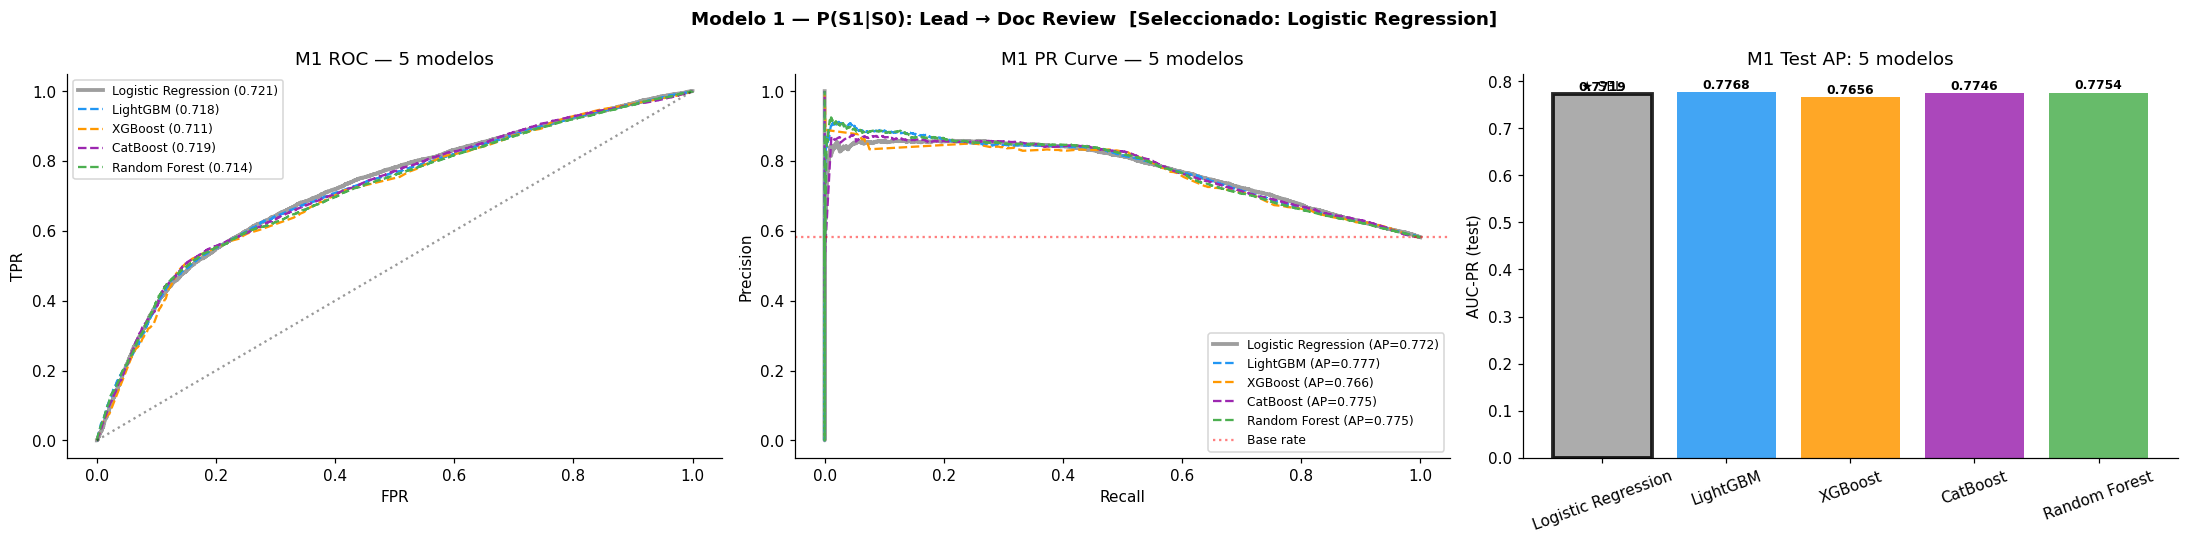


M1 benchmark: {'Logistic Regression': 0.7719, 'LightGBM': 0.7768, 'XGBoost': 0.7656, 'CatBoost': 0.7746, 'Random Forest': 0.7754}


In [153]:

# ── M1 Visualization — 5 modelos ─────────────────────────────────────────────
_m1_colors = {
    "Logistic Regression": "#9E9E9E",
    "LightGBM":            "#2196F3",
    "XGBoost":             "#FF9800",
    "CatBoost":            "#9C27B0",
    "Random Forest":       "#4CAF50",
}
_m1_preds_te = {
    "Logistic Regression": lr1_prob,
    "LightGBM":            p1_test,
    "XGBoost":             p1_xgb_te,
    "CatBoost":            p1_cb_te,
    "Random Forest":       p1_rf_te,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC
for name, p_te in _m1_preds_te.items():
    fpr_, tpr_, _ = roc_curve(y_te1, p_te)
    lw  = 2.5 if name == m1_type else 1.5
    ls  = "-" if name == m1_type else "--"
    axes[0].plot(fpr_, tpr_, lw=lw, ls=ls, color=_m1_colors[name],
                 label=f"{name} ({roc_auc_score(y_te1, p_te):.3f})")
axes[0].plot([0,1],[0,1],"k:",alpha=0.4)
axes[0].legend(fontsize=8); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("M1 ROC — 5 modelos")

# PR curves
for name, p_te in _m1_preds_te.items():
    p_, r_, _ = precision_recall_curve(y_te1, p_te)
    lw  = 2.5 if name == m1_type else 1.5
    ls  = "-" if name == m1_type else "--"
    axes[1].plot(r_, p_, lw=lw, ls=ls, color=_m1_colors[name],
                 label=f"{name} (AP={average_precision_score(y_te1, p_te):.3f})")
axes[1].axhline(float(y_te1.mean()), color="red", ls=":", alpha=0.5, label="Base rate")
axes[1].legend(fontsize=8); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("M1 PR Curve — 5 modelos")

# Bar chart: Test AP comparison
_m1_names = list(_m1_preds_te.keys())
_m1_aps   = [average_precision_score(y_te1, _m1_preds_te[n]) for n in _m1_names]
bar_clrs  = [_m1_colors[n] for n in _m1_names]
bars = axes[2].bar(_m1_names, _m1_aps, color=bar_clrs, alpha=0.85)
for b, ap in zip(bars, _m1_aps):
    axes[2].text(b.get_x() + b.get_width()/2, ap + 0.002,
                 f"{ap:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
axes[2].set_ylabel("AUC-PR (test)"); axes[2].set_title("M1 Test AP: 5 modelos")
axes[2].tick_params(axis="x", rotation=20)
# Mark selected model
sel_idx = _m1_names.index(m1_type)
bars[sel_idx].set_edgecolor("black"); bars[sel_idx].set_linewidth(2.5)
axes[2].text(sel_idx, _m1_aps[sel_idx] + 0.008, "★ SEL", ha="center", fontsize=9, color="black")

plt.suptitle(f"Modelo 1 — P(S1|S0): Lead → Doc Review  [Seleccionado: {m1_type}]",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"\nM1 benchmark: {_m1_bench_df['Test AP'].to_dict()}")


Las curvas nos muestran si hay un modelo que domina claramente o si todos están en un rango parecido. En caso de empate, nos quedamos con el más simple.

## 12. Modelo 2 — P(S2|S1): Doc Review → Hired

Este es el cuello de botella del funnel. Predecimos si un candidato que ya completó Doc Review va a ser contratado. Aquí ya podemos usar los tiempos de doc collection y la velocidad del proceso como features adicionales. Mismo benchmark de 5 modelos.

In [154]:

print("=" * 62)
print("  MODELO 2 — P(S2|S1): Doc Review → Hired")
print("  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF")
print("  [M2 es el cuello de botella — benchmark prioritario]")
print("=" * 62)

X_tr2, y_tr2 = tr2[FEAT_T2], tr2["TARGET"]
X_va2, y_va2 = va2[FEAT_T2], va2["TARGET"]
X_te2, y_te2 = te2[FEAT_T2], te2["TARGET"]

print(f"  Train: {len(X_tr2):,} | Val: {len(X_va2):,} | Test: {len(X_te2):,}")
print(f"  Target rate train/val/test: {y_tr2.mean()*100:.1f}% / {y_va2.mean()*100:.1f}% / {y_te2.mean()*100:.1f}%")

# ── A. Logistic Regression ────────────────────────────────────────────────────
print("\n--- A. Logistic Regression ---")
scaler2   = StandardScaler()
lr2_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr2_model.fit(scaler2.fit_transform(X_tr2.fillna(-999)), y_tr2)
lr2_prob_tr  = lr2_model.predict_proba(scaler2.transform(X_tr2.fillna(-999)))[:, 1]
lr2_prob_val = lr2_model.predict_proba(scaler2.transform(X_va2.fillna(-999)))[:, 1]
lr2_prob     = lr2_model.predict_proba(scaler2.transform(X_te2.fillna(-999)))[:, 1]
print(f"  LR M2 (val AP): {average_precision_score(y_va2, lr2_prob_val):.4f}")

# ── B. LightGBM ───────────────────────────────────────────────────────────────
print("\n--- B. LightGBM (Optuna 50 trials) ---")
bp2, study2 = run_optuna_lgb(X_tr2, y_tr2, X_va2, y_va2, n_trials=50, label="M2_LGB")
m2 = build_final_lgb(bp2, X_tr2, y_tr2, X_va2, y_va2)
p2_train = m2.predict_proba(X_tr2)[:, 1]
p2_val   = m2.predict_proba(X_va2)[:, 1]
p2_test  = m2.predict_proba(X_te2)[:, 1]

# ── C. XGBoost ────────────────────────────────────────────────────────────────
print("\n--- C. XGBoost (Optuna 40 trials) ---")
bp2_xgb = run_optuna_xgb(X_tr2, y_tr2, X_va2, y_va2, n_trials=40, label="M2_XGB")
m2_xgb  = build_final_xgb(bp2_xgb, X_tr2, y_tr2, X_va2, y_va2)
p2_xgb_tr  = m2_xgb.predict_proba(_arr(X_tr2))[:, 1]
p2_xgb_val = m2_xgb.predict_proba(_arr(X_va2))[:, 1]
p2_xgb_te  = m2_xgb.predict_proba(_arr(X_te2))[:, 1]

# ── D. CatBoost (label-encoded, sin cat_features explícito) ───────────────────
print("\n--- D. CatBoost (Optuna 40 trials, label-encoded) ---")
bp2_cb = run_optuna_catboost(X_tr2, y_tr2, X_va2, y_va2, n_trials=40, label="M2_CB")
m2_cb  = build_final_catboost(bp2_cb, X_tr2, y_tr2, X_va2, y_va2)
p2_cb_tr  = m2_cb.predict_proba(_arr(X_tr2))[:, 1]
p2_cb_val = m2_cb.predict_proba(_arr(X_va2))[:, 1]
p2_cb_te  = m2_cb.predict_proba(_arr(X_te2))[:, 1]

# ── E. Random Forest ──────────────────────────────────────────────────────────
print("\n--- E. Random Forest ---")
m2_rf     = build_rf(X_tr2, y_tr2)
p2_rf_tr  = m2_rf.predict_proba(_arr(X_tr2))[:, 1]
p2_rf_val = m2_rf.predict_proba(_arr(X_va2))[:, 1]
p2_rf_te  = m2_rf.predict_proba(_arr(X_te2))[:, 1]

# ── Overfitting check ─────────────────────────────────────────────────────────
print("\n=== Overfitting Check M2 ===")
check_overfitting(y_tr2, lr2_prob_tr,  y_va2, lr2_prob_val, y_te2, lr2_prob,    "LogReg")
check_overfitting(y_tr2, p2_train,     y_va2, p2_val,       y_te2, p2_test,     "LightGBM")
check_overfitting(y_tr2, p2_xgb_tr,   y_va2, p2_xgb_val,   y_te2, p2_xgb_te,  "XGBoost")
check_overfitting(y_tr2, p2_cb_tr,     y_va2, p2_cb_val,    y_te2, p2_cb_te,   "CatBoost")
check_overfitting(y_tr2, p2_rf_tr,     y_va2, p2_rf_val,    y_te2, p2_rf_te,   "RandomForest")

# ── Benchmark table ───────────────────────────────────────────────────────────
_m2_model_data = [
    ("Logistic Regression", lr2_prob_tr, lr2_prob_val, lr2_prob),
    ("LightGBM",            p2_train,    p2_val,        p2_test),
    ("XGBoost",             p2_xgb_tr,   p2_xgb_val,    p2_xgb_te),
    ("CatBoost",            p2_cb_tr,    p2_cb_val,     p2_cb_te),
    ("Random Forest",       p2_rf_tr,    p2_rf_val,     p2_rf_te),
]
_m2_bench_df = build_benchmark_table("M2 — P(S2|S1): Doc Review → Hired  [CUELLO DE BOTELLA]",
                                     y_tr2, y_va2, y_te2, _m2_model_data)

# ── Model selection ───────────────────────────────────────────────────────────
print("\n=== Model Selection M2 ===")
_m2_probs_dict = {
    "Logistic Regression": (lr2_prob,    lr2_prob_val, lr2_prob_tr),
    "LightGBM":            (p2_test,     p2_val,       p2_train),
    "XGBoost":             (p2_xgb_te,   p2_xgb_val,   p2_xgb_tr),
    "CatBoost":            (p2_cb_te,    p2_cb_val,    p2_cb_tr),
    "Random Forest":       (p2_rf_te,    p2_rf_val,    p2_rf_tr),
}
m2_type, p2_best, p2_best_val = select_best_model_multi(_m2_probs_dict, y_te2, y_tr2)
print(f"\n  AP_test (selected M2): {average_precision_score(y_te2, p2_best):.4f}")
print(f"  P@10%: {precision_at_k(y_te2.values, p2_best, 0.10):.4f} | "
      f"Lift@10%: {lift_at_k(y_te2.values, p2_best, 0.10):.2f}x")
print(f"  P@20%: {precision_at_k(y_te2.values, p2_best, 0.20):.4f} | "
      f"Lift@20%: {lift_at_k(y_te2.values, p2_best, 0.20):.2f}x")


  MODELO 2 — P(S2|S1): Doc Review → Hired
  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF
  [M2 es el cuello de botella — benchmark prioritario]
  Train: 60,008 | Val: 11,950 | Test: 11,378
  Target rate train/val/test: 89.6% / 88.0% / 89.1%

--- A. Logistic Regression ---
  LR M2 (val AP): 0.9703

--- B. LightGBM (Optuna 50 trials) ---


Best trial: 24. Best value: 0.982879: 100%|██████████| 50/50 [00:30<00:00,  1.65it/s]


  → M2_LGB: best AUC-PR (val) = 0.9829

--- C. XGBoost (Optuna 40 trials) ---


Best trial: 32. Best value: 0.983054: 100%|██████████| 40/40 [00:22<00:00,  1.82it/s]


  → XGB M2_XGB: best AUC-PR (val) = 0.9831

--- D. CatBoost (Optuna 40 trials, label-encoded) ---


Best trial: 36. Best value: 0.984228: 100%|██████████| 40/40 [01:38<00:00,  2.45s/it]


  → CatBoost M2_CB: best AUC-PR (val) = 0.9842

--- E. Random Forest ---

=== Overfitting Check M2 ===
  LogReg        train=0.9730  val=0.9703  test=0.9531  gap=+0.0199  ✅ OK
  LightGBM      train=0.9791  val=0.9846  test=0.9719  gap=+0.0072  ✅ OK
  XGBoost       train=0.9786  val=0.9852  test=0.9740  gap=+0.0046  ✅ OK
  CatBoost      train=0.9718  val=0.9851  test=0.9736  gap=-0.0018  ✅ OK
  RandomForest  train=0.9915  val=0.9790  test=0.9726  gap=+0.0190  ✅ OK

  BENCHMARK — M2 — P(S2|S1): Doc Review → Hired  [CUELLO DE BOTELLA]
  Métrica principal: AUC-PR (Test AP). Penalización sobreajuste: −0.30×gap
                     Train AP  Val AP  Test AP  Gap train-test  AUC-ROC   Brier      F1  Recall    P@5%   P@10%   P@20%  Lift@5%  Lift@10%  Lift@20%                           Comentario
Modelo                                                                                                                                                                                   
XGBoost        

M2 suele ser el más difícil porque la decisión de hiring depende de muchos factores operativos que no capturamos directamente. Aun así, el benchmark nos dice cuánto aporta cada algoritmo.

Antes de fiarnos de las métricas de M2, diagnosticamos la estabilidad del target rate por mes. Si hay meses en test con tasas muy diferentes a train, las métricas podrían estar distorsionadas por un cambio real en el proceso y no por un fallo del modelo.

In [155]:
# ══════════════════════════════════════════════════════════════════════════════
# DIAGNÓSTICO: Target rate mensual en DS2 (S1→S2) — Closed Loop
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  DIAGNÓSTICO: Target rate mensual en DS2 (S1→S2) — Closed Loop")
print("=" * 70)

monthly = (ds_t2.groupby("_month_period")
           .agg(n=("TARGET","count"), hired=("TARGET","sum"))
           .assign(rate=lambda d: d["hired"]/d["n"]))
print("\n  Closed Loop: solo leads con resolución final (hired/rejected)")
print("\n  Mes         N leads    Hired    Rate")
print("  " + "-"*45)
for period, row in monthly.iterrows():
    marker = " ← TEST" if pd.Timestamp(period) > VAL_END else (
             " ← VAL" if pd.Timestamp(period) > TRAIN_END else "")
    print(f"  {period}   {row['n']:>7,.0f}   {row['hired']:>6,.0f}   {row['rate']*100:5.1f}%{marker}")

print(f"\n  Train mean: {y_tr2.mean()*100:.1f}%  |  Val mean: {y_va2.mean()*100:.1f}%  |  Test mean: {y_te2.mean()*100:.1f}%")
drift = (y_tr2.mean() - y_te2.mean()) * 100
print(f"  Drift train→test: {drift:+.1f} pp {'✅ < 10pp' if abs(drift) < 10 else '⚠️ > 10pp'}")

# Score distributions
print("\n  Distribución de probabilidades predichas en test:")
_probs = {
    "LogReg":    lr2_prob,
    "LightGBM":  p2_test,
    "XGBoost":   p2_xgb_te,
    "CatBoost":  p2_cb_te,
    "RF":        p2_rf_te,
}
for name, probs in _probs.items():
    pa = np.array(probs)
    print(f"    {name:12s}: mean={pa.mean():.3f}  median={np.median(pa):.3f}  "
          f"min={pa.min():.3f}  max={pa.max():.3f}  ≥0.5: {(pa >= 0.5).mean()*100:.1f}%")


  DIAGNÓSTICO: Target rate mensual en DS2 (S1→S2) — Closed Loop

  Closed Loop: solo leads con resolución final (hired/rejected)

  Mes         N leads    Hired    Rate
  ---------------------------------------------
  2025-03     8,315    6,399    77.0%
  2025-04     5,840    5,315    91.0%
  2025-05     7,690    7,371    95.9%
  2025-06     8,944    8,248    92.2%
  2025-07     7,944    6,690    84.2%
  2025-08     5,866    5,466    93.2%
  2025-09     7,674    7,100    92.5%
  2025-10     7,920    7,351    92.8%
  2025-11     6,675    5,937    88.9% ← VAL
  2025-12     5,142    4,447    86.5% ← VAL
  2026-01     5,822    5,023    86.3% ← TEST
  2026-02     3,808    3,519    92.4% ← TEST
  2026-03     1,552    1,412    91.0% ← TEST
  2026-04       144      138    95.8% ← TEST

  Train mean: 89.6%  |  Val mean: 88.0%  |  Test mean: 89.1%
  Drift train→test: +0.5 pp ✅ < 10pp

  Distribución de probabilidades predichas en test:
    LogReg      : mean=0.122  median=0.039  min=0.000  max=

La tabla mensual confirma si el drift está controlado o si hay meses problemáticos que deberíamos investigar operativamente.

Misma visualización que M1: curvas ROC, PR y comparativa de AUC-PR de los 5 modelos para M2.

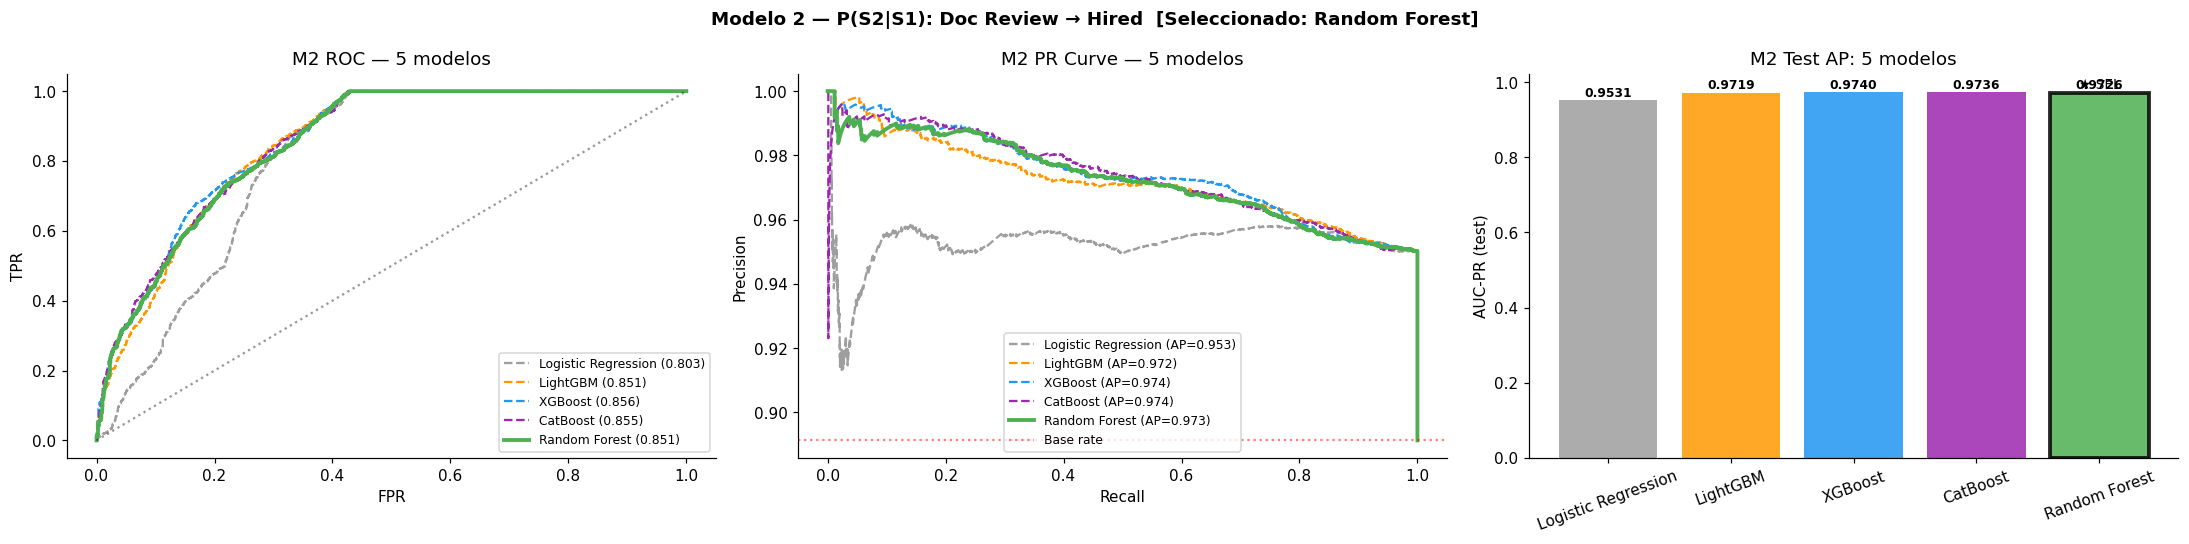


M2 benchmark: {'Logistic Regression': 0.9531, 'LightGBM': 0.9719, 'XGBoost': 0.974, 'CatBoost': 0.9736, 'Random Forest': 0.9726}


In [156]:

# ── M2 Visualization — 5 modelos ─────────────────────────────────────────────
_m2_colors = {
    "Logistic Regression": "#9E9E9E",
    "LightGBM":            "#FF9800",
    "XGBoost":             "#2196F3",
    "CatBoost":            "#9C27B0",
    "Random Forest":       "#4CAF50",
}
_m2_preds_te = {
    "Logistic Regression": lr2_prob,
    "LightGBM":            p2_test,
    "XGBoost":             p2_xgb_te,
    "CatBoost":            p2_cb_te,
    "Random Forest":       p2_rf_te,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC
for name, p_te in _m2_preds_te.items():
    fpr_, tpr_, _ = roc_curve(y_te2, p_te)
    lw = 2.5 if name == m2_type else 1.5
    ls = "-" if name == m2_type else "--"
    axes[0].plot(fpr_, tpr_, lw=lw, ls=ls, color=_m2_colors[name],
                 label=f"{name} ({roc_auc_score(y_te2, p_te):.3f})")
axes[0].plot([0,1],[0,1],"k:",alpha=0.4)
axes[0].legend(fontsize=8); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("M2 ROC — 5 modelos")

# PR curves
for name, p_te in _m2_preds_te.items():
    p_, r_, _ = precision_recall_curve(y_te2, p_te)
    lw = 2.5 if name == m2_type else 1.5
    ls = "-" if name == m2_type else "--"
    axes[1].plot(r_, p_, lw=lw, ls=ls, color=_m2_colors[name],
                 label=f"{name} (AP={average_precision_score(y_te2, p_te):.3f})")
axes[1].axhline(float(y_te2.mean()), color="red", ls=":", alpha=0.5, label="Base rate")
axes[1].legend(fontsize=8); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("M2 PR Curve — 5 modelos")

# Bar chart: Test AP
_m2_names = list(_m2_preds_te.keys())
_m2_aps   = [average_precision_score(y_te2, _m2_preds_te[n]) for n in _m2_names]
bar_clrs2 = [_m2_colors[n] for n in _m2_names]
bars2 = axes[2].bar(_m2_names, _m2_aps, color=bar_clrs2, alpha=0.85)
for b, ap in zip(bars2, _m2_aps):
    axes[2].text(b.get_x() + b.get_width()/2, ap + 0.002,
                 f"{ap:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
axes[2].set_ylabel("AUC-PR (test)"); axes[2].set_title("M2 Test AP: 5 modelos")
axes[2].tick_params(axis="x", rotation=20)
sel_idx2 = _m2_names.index(m2_type)
bars2[sel_idx2].set_edgecolor("black"); bars2[sel_idx2].set_linewidth(2.5)
axes[2].text(sel_idx2, _m2_aps[sel_idx2] + 0.010, "★ SEL", ha="center",
             fontsize=9, color="black")

plt.suptitle(f"Modelo 2 — P(S2|S1): Doc Review → Hired  [Seleccionado: {m2_type}]",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"\nM2 benchmark: {_m2_bench_df['Test AP'].to_dict()}")


La separación entre modelos en M2 nos indica si los tiempos de doc collection y la velocidad realmente aportan señal predicativa, o si la transición es más ruidosa de lo que podemos capturar.

## 13. Modelo 3 — P(CFO|S2): Hired → CFO

Último modelo: ¿este rider recién contratado va a hacer su primer pedido? Aquí aplicamos medidas anti-overfitting agresivas:
- Eliminamos features redundantes (correlacionadas con otras que ya tenemos).
- Eliminamos features estacionales: meses, trimestre, hora, día de la semana — porque los meses de test (ene-feb 2026) nunca aparecen en train (mar-oct 2025), y crear features OOD empeora la generalización.
- Eliminamos proxies de S1 (`lag_s1_city`, `lag_s1_src`) que predicen S0→S1, no S2→CFO.
- Aplicamos una ventana de observación de 45 días: excluimos leads muy recientes que aún no han tenido tiempo de hacer CFO, porque su tasa artificialmente baja contaminaría el test.

Los bounds de Optuna son más restrictivos que en M1/M2 (max_depth 3-5, min_child_samples 50-300, regularización alta).

In [157]:
print("=" * 70)
print("  MODELO 3 — P(CFO|S2): Hired → CFO (First Order)")
print("  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF")
print("  [Anti-overfit v2: obs-window + no OOD-seasonal + no S1-proxy]")
print("=" * 70)

# ── 1. Remove collinear features ──────────────────────────────────────────────
_REDUNDANT_T3 = {"lead_to_hired", "velocity_s2", "funnel_speed_s1", "velocity_s1"}

# ── 2. Remove temporal calendar features ─────────────────────────────────────
#  Months 1-2 (Jan-Feb test) are OOD: training covers Mar-Oct 2025 only.
#  Top z-score drifters: month_num=2.14, apply_season=2.00, quarter=1.70.
_SEASONAL_T3 = {"month_num", "month_sin", "month_cos", "quarter", "apply_season",
                "hour_of_day", "hour_sin", "hour_cos", "dow_sin", "dow_cos"}

# ── 3. Remove lag_s1 features (predict S0→S1, not P(CFO|S2); drift z>0.6) ───
_S1_PROXY_T3 = {"lag_s1_city", "lag_s1_src"}

FEAT_T3_SEL = [f for f in FEAT_T3
               if f not in (_REDUNDANT_T3 | _SEASONAL_T3 | _S1_PROXY_T3)]
_n_removed = len(_REDUNDANT_T3) + len(_SEASONAL_T3) + len(_S1_PROXY_T3)
print(f"  Features: {len(FEAT_T3_SEL)} selected from {len(FEAT_T3)} (removed {_n_removed})")

# ── 4. Observation-window: exclude right-censored CFO labels ──────────────────
#  March 2026: 44.2% CFO | April 2026: 22.5% CFO  (vs 55.6% in train)
#  → Only keep leads created >= OBS_DAYS before the query run date.
OBS_DAYS   = 45
QUERY_DATE = pd.Timestamp("2026-04-09")
OBS_CUTOFF = QUERY_DATE - pd.Timedelta(days=OBS_DAYS)   # ≈ 2026-02-23

_tr3 = tr3[pd.to_datetime(tr3["created_at"]) <= OBS_CUTOFF]
_va3 = va3[pd.to_datetime(va3["created_at"]) <= OBS_CUTOFF]
_te3 = te3[pd.to_datetime(te3["created_at"]) <= OBS_CUTOFF]

X_tr3, y_tr3 = _tr3[FEAT_T3_SEL], _tr3["TARGET"]
X_va3, y_va3 = _va3[FEAT_T3_SEL], _va3["TARGET"]
X_te3, y_te3 = _te3[FEAT_T3_SEL], _te3["TARGET"]
print(f"  Train: {len(X_tr3):,} | Val: {len(X_va3):,} | Test: {len(X_te3):,}")
print(f"  Target rate: tr={y_tr3.mean()*100:.1f}% va={y_va3.mean()*100:.1f}% te={y_te3.mean()*100:.1f}% "
      f"  (OBS_CUTOFF={OBS_CUTOFF.date()})")

# ── A. Logistic Regression ────────────────────────────────────────────────────
print("\n--- A. Logistic Regression ---")
scaler3   = StandardScaler()
lr3_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr3_model.fit(scaler3.fit_transform(X_tr3.fillna(-999)), y_tr3)
lr3_prob_tr  = lr3_model.predict_proba(scaler3.transform(X_tr3.fillna(-999)))[:, 1]
lr3_prob_val = lr3_model.predict_proba(scaler3.transform(X_va3.fillna(-999)))[:, 1]
lr3_prob     = lr3_model.predict_proba(scaler3.transform(X_te3.fillna(-999)))[:, 1]
print(f"  LR M3 (val AP): {average_precision_score(y_va3, lr3_prob_val):.4f}")

# ── B. LightGBM (anti-overfit Optuna bounds) ──────────────────────────────────
print("\n--- B. LightGBM (Optuna 50 trials, anti-overfit) ---")
def _obj_lgb_m3(trial):
    p = {
        "num_leaves":        trial.suggest_int("num_leaves", 15, 63),
        "max_depth":         trial.suggest_int("max_depth", 3, 5),
        "learning_rate":     trial.suggest_float("lr", 0.01, 0.1, log=True),
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 300),
        "subsample":         trial.suggest_float("subsample", 0.5, 0.85),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 0.8),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.1, 20.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
    }
    m = lgb.LGBMClassifier(**p, objective="binary",
                            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(X_tr3, y_tr3, eval_set=[(X_va3, y_va3)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    return average_precision_score(np.asarray(y_va3), m.predict_proba(X_va3)[:, 1])

study3 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)
study3.optimize(_obj_lgb_m3, n_trials=50, show_progress_bar=True)
bp3 = {("learning_rate" if k == "lr" else k): v for k, v in study3.best_params.items()}
print(f"  → M3_LGB: best AUC-PR (val) = {study3.best_value:.4f}")

# Final model: train on train set, val for early stopping (no concat leak)
m3 = lgb.LGBMClassifier(**bp3, objective="binary",
                         random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
m3.fit(X_tr3, y_tr3, eval_set=[(X_va3, y_va3)],
       callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
p3_train = m3.predict_proba(X_tr3)[:, 1]
p3_val   = m3.predict_proba(X_va3)[:, 1]
p3_test  = m3.predict_proba(X_te3)[:, 1]

# ── C. XGBoost (anti-overfit) ─────────────────────────────────────────────────
print("\n--- C. XGBoost (Optuna 40 trials, anti-overfit) ---")
Xa3, ya3 = _arr(X_tr3), np.asarray(y_tr3)
Xv3, yv3 = _arr(X_va3), np.asarray(y_va3)
Xt3      = _arr(X_te3)

def _obj_xgb_m3(trial):
    p = dict(
        max_depth        = trial.suggest_int("max_depth", 3, 5),
        learning_rate    = trial.suggest_float("lr", 0.01, 0.1, log=True),
        n_estimators     = trial.suggest_int("n_estimators", 100, 600),
        min_child_weight = trial.suggest_int("min_child_weight", 20, 100),
        subsample        = trial.suggest_float("subsample", 0.5, 0.85),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.4, 0.8),
        reg_alpha        = trial.suggest_float("reg_alpha", 0.1, 20.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
    )
    m = XGBClassifier(**p, objective="binary:logistic", eval_metric="aucpr",
                      early_stopping_rounds=30, verbosity=0,
                      random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(Xa3, ya3, eval_set=[(Xv3, yv3)], verbose=False)
    return average_precision_score(yv3, m.predict_proba(Xv3)[:, 1])

study3_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8),
)
study3_xgb.optimize(_obj_xgb_m3, n_trials=40, show_progress_bar=True)
_bx = study3_xgb.best_params
bp3_xgb = {
    "max_depth": _bx["max_depth"], "learning_rate": _bx["lr"],
    "n_estimators": _bx["n_estimators"], "min_child_weight": _bx["min_child_weight"],
    "subsample": _bx["subsample"], "colsample_bytree": _bx["colsample_bytree"],
    "reg_alpha": _bx["reg_alpha"], "reg_lambda": _bx["reg_lambda"],
}
print(f"  → XGB M3_XGB: best AUC-PR (val) = {study3_xgb.best_value:.4f}")
m3_xgb = XGBClassifier(**bp3_xgb, objective="binary:logistic", eval_metric="aucpr",
                        early_stopping_rounds=50, verbosity=0,
                        random_state=RANDOM_STATE, n_jobs=-1)
m3_xgb.fit(Xa3, ya3, eval_set=[(Xv3, yv3)], verbose=False)
p3_xgb_tr  = m3_xgb.predict_proba(Xa3)[:, 1]
p3_xgb_val = m3_xgb.predict_proba(Xv3)[:, 1]
p3_xgb_te  = m3_xgb.predict_proba(Xt3)[:, 1]

# ── D. CatBoost (anti-overfit) ────────────────────────────────────────────────
print("\n--- D. CatBoost (Optuna 40 trials, anti-overfit) ---")
def _obj_cb_m3(trial):
    p = dict(
        depth               = trial.suggest_int("depth", 3, 5),
        learning_rate       = trial.suggest_float("lr", 0.01, 0.1, log=True),
        iterations          = trial.suggest_int("iterations", 100, 600),
        l2_leaf_reg         = trial.suggest_float("l2_leaf_reg", 3.0, 30.0),
        min_data_in_leaf    = trial.suggest_int("min_data_in_leaf", 20, 100),
        bagging_temperature = trial.suggest_float("bagging_temperature", 0.5, 2.0),
    )
    m = CatBoostClassifier(**p, eval_metric="PRAUC", early_stopping_rounds=30,
                           verbose=False, random_state=RANDOM_STATE, thread_count=-1)
    m.fit(Xa3, ya3, eval_set=(Xv3, yv3), use_best_model=True, verbose=False)
    return average_precision_score(yv3, m.predict_proba(Xv3)[:, 1])

study3_cb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8),
)
study3_cb.optimize(_obj_cb_m3, n_trials=40, show_progress_bar=True)
_bc = study3_cb.best_params
bp3_cb = {
    "depth": _bc["depth"], "learning_rate": _bc["lr"],
    "iterations": _bc["iterations"], "l2_leaf_reg": _bc["l2_leaf_reg"],
    "min_data_in_leaf": _bc["min_data_in_leaf"],
    "bagging_temperature": _bc["bagging_temperature"],
}
print(f"  → CatBoost M3_CB: best AUC-PR (val) = {study3_cb.best_value:.4f}")
m3_cb = CatBoostClassifier(**bp3_cb, eval_metric="PRAUC", early_stopping_rounds=50,
                            verbose=False, random_state=RANDOM_STATE, thread_count=-1)
m3_cb.fit(Xa3, ya3, eval_set=(Xv3, yv3), use_best_model=True, verbose=False)
p3_cb_tr  = m3_cb.predict_proba(Xa3)[:, 1]
p3_cb_val = m3_cb.predict_proba(Xv3)[:, 1]
p3_cb_te  = m3_cb.predict_proba(Xt3)[:, 1]

# ── E. Random Forest (regularized) ────────────────────────────────────────────
print("\n--- E. Random Forest (regularized) ---")
m3_rf = build_rf(X_tr3, y_tr3, n_estimators=300, max_depth=8, min_samples_leaf=50)
p3_rf_tr  = m3_rf.predict_proba(_arr(X_tr3))[:, 1]
p3_rf_val = m3_rf.predict_proba(_arr(X_va3))[:, 1]
p3_rf_te  = m3_rf.predict_proba(_arr(X_te3))[:, 1]

# ── Overfitting check ─────────────────────────────────────────────────────────
print("\n=== Overfitting Check M3 ===")
check_overfitting(y_tr3, lr3_prob_tr,  y_va3, lr3_prob_val, y_te3, lr3_prob,    "LogReg")
check_overfitting(y_tr3, p3_train,     y_va3, p3_val,       y_te3, p3_test,     "LightGBM")
check_overfitting(y_tr3, p3_xgb_tr,   y_va3, p3_xgb_val,   y_te3, p3_xgb_te,  "XGBoost")
check_overfitting(y_tr3, p3_cb_tr,     y_va3, p3_cb_val,    y_te3, p3_cb_te,   "CatBoost")
check_overfitting(y_tr3, p3_rf_tr,     y_va3, p3_rf_val,    y_te3, p3_rf_te,   "RandomForest")

# ── Benchmark table ───────────────────────────────────────────────────────────
_m3_model_data = [
    ("Logistic Regression", lr3_prob_tr, lr3_prob_val, lr3_prob),
    ("LightGBM",            p3_train,    p3_val,        p3_test),
    ("XGBoost",             p3_xgb_tr,   p3_xgb_val,    p3_xgb_te),
    ("CatBoost",            p3_cb_tr,    p3_cb_val,     p3_cb_te),
    ("Random Forest",       p3_rf_tr,    p3_rf_val,     p3_rf_te),
]
_m3_bench_df = build_benchmark_table("M3 — P(CFO|S2): Hired → CFO (First Order)",
                                     y_tr3, y_va3, y_te3, _m3_model_data)

# ── Model selection ───────────────────────────────────────────────────────────
print("\n=== Model Selection M3 ===")
_m3_probs_dict = {
    "Logistic Regression": (lr3_prob,    lr3_prob_val, lr3_prob_tr),
    "LightGBM":            (p3_test,     p3_val,       p3_train),
    "XGBoost":             (p3_xgb_te,   p3_xgb_val,   p3_xgb_tr),
    "CatBoost":            (p3_cb_te,    p3_cb_val,    p3_cb_tr),
    "Random Forest":       (p3_rf_te,    p3_rf_val,    p3_rf_tr),
}
m3_type, p3_best, p3_best_val = select_best_model_multi(_m3_probs_dict, y_te3, y_tr3)
print(f"\n  AP_test (selected M3): {average_precision_score(y_te3, p3_best):.4f}")
print(f"  P@10%: {precision_at_k(y_te3.values, p3_best, 0.10):.4f} | "
      f"Lift@10%: {lift_at_k(y_te3.values, p3_best, 0.10):.2f}x")


  MODELO 3 — P(CFO|S2): Hired → CFO (First Order)
  BENCHMARK: LogReg | LightGBM | XGBoost | CatBoost | RF
  [Anti-overfit v2: obs-window + no OOD-seasonal + no S1-proxy]
  Features: 20 selected from 36 (removed 16)
  Train: 53,766 | Val: 10,513 | Test: 8,090
  Target rate: tr=55.6% va=61.2% te=56.7%   (OBS_CUTOFF=2026-02-23)

--- A. Logistic Regression ---
  LR M3 (val AP): 0.6855

--- B. LightGBM (Optuna 50 trials, anti-overfit) ---


Best trial: 26. Best value: 0.696492: 100%|██████████| 50/50 [00:39<00:00,  1.28it/s]


  → M3_LGB: best AUC-PR (val) = 0.6965

--- C. XGBoost (Optuna 40 trials, anti-overfit) ---


Best trial: 28. Best value: 0.696962: 100%|██████████| 40/40 [00:42<00:00,  1.07s/it]


  → XGB M3_XGB: best AUC-PR (val) = 0.6970

--- D. CatBoost (Optuna 40 trials, anti-overfit) ---


Best trial: 2. Best value: 0.66237: 100%|██████████| 40/40 [00:48<00:00,  1.20s/it]


  → CatBoost M3_CB: best AUC-PR (val) = 0.6624

--- E. Random Forest (regularized) ---

=== Overfitting Check M3 ===
  LogReg        train=0.6775  val=0.6855  test=0.6465  gap=+0.0309  ✅ OK
  LightGBM      train=0.7390  val=0.6965  test=0.6553  gap=+0.0837  ⚠️ overfit
  XGBoost       train=0.7327  val=0.6973  test=0.6578  gap=+0.0748  ⚠️ overfit
  CatBoost      train=0.6608  val=0.6624  test=0.6080  gap=+0.0528  ⚠️ overfit
  RandomForest  train=0.7247  val=0.6908  test=0.6489  gap=+0.0758  ⚠️ overfit

  BENCHMARK — M3 — P(CFO|S2): Hired → CFO (First Order)
  Métrica principal: AUC-PR (Test AP). Penalización sobreajuste: −0.30×gap
                     Train AP  Val AP  Test AP  Gap train-test  AUC-ROC   Brier      F1  Recall    P@5%   P@10%   P@20%  Lift@5%  Lift@10%  Lift@20%                           Comentario
Modelo                                                                                                                                                                          

El benchmark de M3 muestra si las medidas anti-overfitting funcionan: el gap train-test debería ser mucho más bajo que sin ellas, aunque a cambio de un AP absoluto algo menor. Es un trade-off que vale la pena.

Visualizamos M3 con curvas ROC, PR y curva de ganancias (qué porcentaje de CFOs capturamos contactando un X% de riders contratados). Al final imprimimos un resumen ejecutivo con el mejor modelo seleccionado para cada transición.

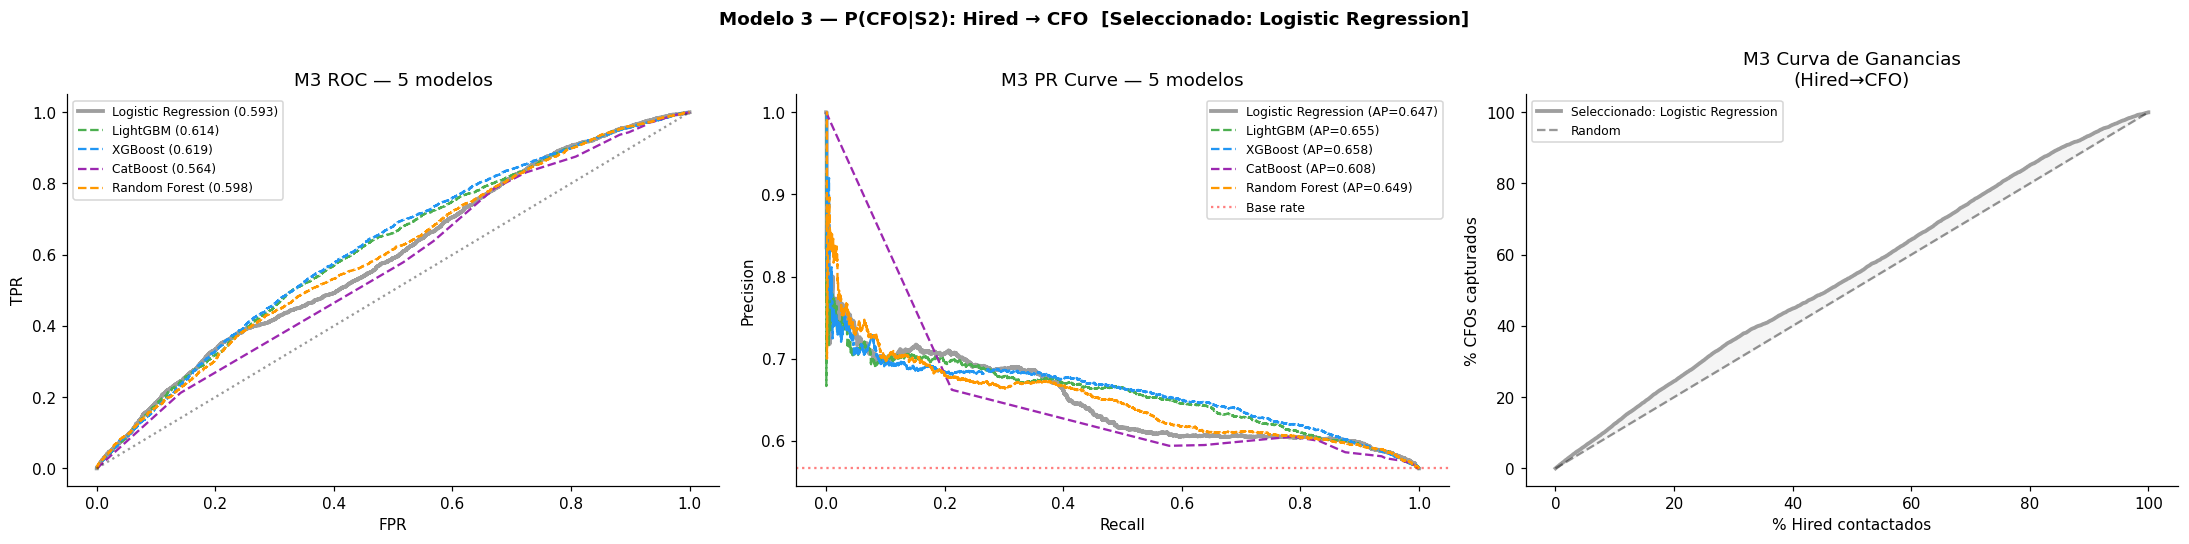


M3 benchmark: {'Logistic Regression': 0.6465, 'LightGBM': 0.6553, 'XGBoost': 0.6578, 'CatBoost': 0.608, 'Random Forest': 0.6489}

  RESUMEN EJECUTIVO — MEJOR MODELO POR TRANSICIÓN
  M1 P(S1|S0)    : [Logistic Regression   ]  AP=0.7719  Gap=-0.1233  P@10%=0.8548  Lift@10%=1.47x
  M2 P(S2|S1)    : [Random Forest         ]  AP=0.9726  Gap=+0.0190  P@10%=0.9894  Lift@10%=1.11x
  M3 P(CFO|S2)   : [Logistic Regression   ]  AP=0.6465  Gap=+0.0309  P@10%=0.7108  Lift@10%=1.25x


In [158]:

# ── M3 Visualization — 5 modelos ─────────────────────────────────────────────
_m3_colors = {
    "Logistic Regression": "#9E9E9E",
    "LightGBM":            "#4CAF50",
    "XGBoost":             "#2196F3",
    "CatBoost":            "#9C27B0",
    "Random Forest":       "#FF9800",
}
_m3_preds_te = {
    "Logistic Regression": lr3_prob,
    "LightGBM":            p3_test,
    "XGBoost":             p3_xgb_te,
    "CatBoost":            p3_cb_te,
    "Random Forest":       p3_rf_te,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC
for name, p_te in _m3_preds_te.items():
    fpr_, tpr_, _ = roc_curve(y_te3, p_te)
    lw = 2.5 if name == m3_type else 1.5
    ls = "-" if name == m3_type else "--"
    axes[0].plot(fpr_, tpr_, lw=lw, ls=ls, color=_m3_colors[name],
                 label=f"{name} ({roc_auc_score(y_te3, p_te):.3f})")
axes[0].plot([0,1],[0,1],"k:",alpha=0.4)
axes[0].legend(fontsize=8); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("M3 ROC — 5 modelos")

# PR curves
for name, p_te in _m3_preds_te.items():
    p_, r_, _ = precision_recall_curve(y_te3, p_te)
    lw = 2.5 if name == m3_type else 1.5
    ls = "-" if name == m3_type else "--"
    axes[1].plot(r_, p_, lw=lw, ls=ls, color=_m3_colors[name],
                 label=f"{name} (AP={average_precision_score(y_te3, p_te):.3f})")
axes[1].axhline(float(y_te3.mean()), color="red", ls=":", alpha=0.5, label="Base rate")
axes[1].legend(fontsize=8); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("M3 PR Curve — 5 modelos")

# Curva de ganancias del modelo seleccionado
idx_s = np.argsort(p3_best)[::-1]
y_s   = np.array(y_te3)[idx_s]
cum_gains = np.cumsum(y_s) / max(y_s.sum(), 1)
pct_pop   = np.arange(1, len(y_s)+1) / len(y_s)
axes[2].plot(pct_pop*100, cum_gains*100, lw=2.5,
             color=_m3_colors.get(m3_type, "#4CAF50"),
             label=f"Seleccionado: {m3_type}")
axes[2].plot([0,100],[0,100],"k--",alpha=0.4, label="Random")
axes[2].fill_between(pct_pop*100, cum_gains*100, pct_pop*100, alpha=0.1,
                     color=_m3_colors.get(m3_type, "#4CAF50"))
axes[2].set_xlabel("% Hired contactados"); axes[2].set_ylabel("% CFOs capturados")
axes[2].set_title(f"M3 Curva de Ganancias\n(Hired→CFO)")
axes[2].legend(fontsize=8)

plt.suptitle(f"Modelo 3 — P(CFO|S2): Hired → CFO  [Seleccionado: {m3_type}]",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"\nM3 benchmark: {_m3_bench_df['Test AP'].to_dict()}")

# ── Resumen ejecutivo: mejores modelos por transición ─────────────────────────
print("\n" + "="*62)
print("  RESUMEN EJECUTIVO — MEJOR MODELO POR TRANSICIÓN")
print("="*62)
for trans, mtype, bench in [
    ("M1 P(S1|S0)", m1_type, _m1_bench_df),
    ("M2 P(S2|S1)", m2_type, _m2_bench_df),
    ("M3 P(CFO|S2)", m3_type, _m3_bench_df),
]:
    ap = bench.loc[mtype, "Test AP"] if mtype in bench.index else float("nan")
    gap = bench.loc[mtype, "Gap train-test"] if mtype in bench.index else float("nan")
    p10 = bench.loc[mtype, "P@10%"] if mtype in bench.index else float("nan")
    l10 = bench.loc[mtype, "Lift@10%"] if mtype in bench.index else float("nan")
    print(f"  {trans:15s}: [{mtype:22s}]  AP={ap:.4f}  Gap={gap:+.4f}  "
          f"P@10%={p10:.4f}  Lift@10%={l10:.2f}x")


El resumen ejecutivo es la foto final: qué algoritmo se eligió para cada transición, su AP en test, cuánto overfitting tiene, y el lift práctico. Esto es lo que presentamos como resultado del modelado.

## 14. Modelos de fallback

No todos los leads tienen scores de los tres modelos. Un lead que acaba de entrar solo ha pasado por M1; uno que completó Doc Review tiene M1+M2 pero no M3. Para asignar un score a todos, entrenamos modelos de fallback simples (Logistic Regression):
- **P(CFO|S0)**: probabilidad directa de CFO usando solo features de registro.
- **P(CFO|S1)**: probabilidad de CFO para leads en Doc Review que aún no fueron contratados.
- **P(S2|S0)**: probabilidad de que un lead nuevo eventualmente sea contratado.

In [159]:
# ── Fallback Models: Option A — mini-LR para leads sin info de etapas posteriores ──
print("=" * 62)
print("  FALLBACK MODELS — P(S2|S0), P(CFO|S1), P(CFO|S0)")
print("=" * 62)

# M_s2s0: P(eventually reach S2 | S0) — for leads not yet in S1
scaler_fb1 = StandardScaler()
m_s2s0 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
m_s2s0.fit(scaler_fb1.fit_transform(tr1[FEAT_T1].fillna(-999)), tr1["reached_s2"])
fb_p_s2s0_te = m_s2s0.predict_proba(scaler_fb1.transform(te1[FEAT_T1].fillna(-999)))[:, 1]
ap_s2s0 = average_precision_score(te1["reached_s2"].values, fb_p_s2s0_te)
print(f"  m_s2s0  (P(S2|S0)):  AUC-PR test = {ap_s2s0:.4f}")

# M_cfos0: P(eventually reach CFO | S0) — direct path from S0
scaler_fb3 = StandardScaler()
m_cfos0 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
m_cfos0.fit(scaler_fb3.fit_transform(tr1[FEAT_T1].fillna(-999)), tr1["is_cfo"])
fb_p_cfos0_te = m_cfos0.predict_proba(scaler_fb3.transform(te1[FEAT_T1].fillna(-999)))[:, 1]
ap_cfos0 = average_precision_score(te1["is_cfo"].values, fb_p_cfos0_te)
print(f"  m_cfos0 (P(CFO|S0)): AUC-PR test = {ap_cfos0:.4f}")

# M_cfos1: P(eventually reach CFO | S1) — for S1 leads not yet hired
scaler_fb2 = StandardScaler()
m_cfos1 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
m_cfos1.fit(scaler_fb2.fit_transform(tr2[FEAT_T2].fillna(-999)), tr2["is_cfo"])
fb_p_cfos1_te = m_cfos1.predict_proba(scaler_fb2.transform(te2[FEAT_T2].fillna(-999)))[:, 1]
ap_cfos1 = average_precision_score(te2["is_cfo"].values, fb_p_cfos1_te)
print(f"  m_cfos1 (P(CFO|S1)): AUC-PR test = {ap_cfos1:.4f}")

print("\n  Fallback strategy summary:")
print("  Lead @ S0 (no S1 info)   → P(CFO) = m_cfos0 score")
print("  Lead @ S1 (no S2 info)   → P(CFO) = p(S1|S0) × m_cfos1 score")
print("  Lead @ S2 (all info)     → P(CFO) = M1 × M2 × M3 (full decomposition)")


  FALLBACK MODELS — P(S2|S0), P(CFO|S1), P(CFO|S0)
  m_s2s0  (P(S2|S0)):  AUC-PR test = 0.7033
  m_cfos0 (P(CFO|S0)): AUC-PR test = 0.3458
  m_cfos1 (P(CFO|S1)): AUC-PR test = 0.4823

  Fallback strategy summary:
  Lead @ S0 (no S1 info)   → P(CFO) = m_cfos0 score
  Lead @ S1 (no S2 info)   → P(CFO) = p(S1|S0) × m_cfos1 score
  Lead @ S2 (all info)     → P(CFO) = M1 × M2 × M3 (full decomposition)


Los fallback son modelos simples pero necesarios operativamente. Su AP no compite con los modelos principales, pero nos permiten hacer scoring universal para todos los leads del funnel.

## 15. Tabla de scoring compuesto

Construimos la tabla que asigna a cada lead de test su probabilidad compuesta P(CFO) = M1 × M2 × M3. Para leads donde no hay score de M2 o M3 (porque no llegaron a esa etapa), usamos los fallback condicionados por ciudad y source en vez de medias globales.

In [160]:
# ── Build scoring table for ALL test leads (base: T1 / S0 perspective) ────────
score_df = te1[["applicant_id","created_at","_month_period",
                "city_group","source","is_cfo",
                "reached_s1","reached_s2"]].copy()

# M1 scores all leads
score_df["p_s1_s0"] = p1_best  # use selected model (LGB or LogReg)

# ── M2/M3 scores via fallback model (Option A) ────────────────────────────────
# Global means (kept for reference / edge cases)
global_p2 = float(p2_train.mean())
global_p3 = float(p3_train.mean())

# Map M2 and M3 scores to full-test index
t2_score_map = pd.Series(p2_best, index=te2.index)
# Note: p3_best is on X_te3 index (OBS_CUTOFF filtered, 8087 rows) not full te3 (10098)
t3_score_map = pd.Series(p3_best, index=X_te3.index)

# Conditional fallback means from train (by city×source — much better than global)
_fb_p2 = (tr2.assign(TARGET=tr2["TARGET"])
             .groupby(["city_group","source"])["TARGET"].mean())
_fb_p3 = (tr3.assign(TARGET=tr3["TARGET"])
             .groupby(["city_group","source"])["TARGET"].mean())

def cond_fallback(row_idx_series, city_s, src_s, score_map, cond_dict, global_val):
    # Use score_map if available, else conditional mean, else global.
    result = row_idx_series.map(score_map)
    mask_na = result.isna()
    if mask_na.any():
        keys = list(zip(city_s[mask_na], src_s[mask_na]))
        cond_vals = [cond_dict.get(k, global_val) for k in keys]
        result.loc[mask_na] = cond_vals
    return result.values

score_df["p_s2_s1"]  = cond_fallback(
    pd.Series(score_df.index, index=score_df.index),
    score_df["city_group"], score_df["source"],
    t2_score_map, _fb_p2.to_dict(), global_p2)

score_df["p_cfo_s2"] = cond_fallback(
    pd.Series(score_df.index, index=score_df.index),
    score_df["city_group"], score_df["source"],
    t3_score_map, _fb_p3.to_dict(), global_p3)

# ── Alternative: direct fallback model (cfos0) for leads not in S1 ────────────
in_s1 = score_df.index.isin(te2.index)
in_s2 = score_df.index.isin(te3.index)

score_df["p_cfo_fallback"] = np.where(
    in_s2,
    score_df["p_s1_s0"] * score_df["p_s2_s1"] * score_df["p_cfo_s2"],  # full decomp
    np.where(
        in_s1,
        score_df["p_s1_s0"] * pd.Series(fb_p_cfos1_te, index=te2.index).reindex(score_df.index).fillna(global_p3).values,
        fb_p_cfos0_te,  # direct P(CFO|S0) for leads not in S1
    )
)

# ── Composed probability (standard decomposition) ─────────────────────────────
score_df["p_cfo_composed"] = (
    score_df["p_s1_s0"] * score_df["p_s2_s1"] * score_df["p_cfo_s2"]
)

print("=== Scoring table built for test set ===")
print(f"Leads: {len(score_df):,}  (S1: {in_s1.sum():,} | S2: {in_s2.sum():,} | S0-only: {(~in_s1).sum():,})")
print(f"\nScore statistics:")
for col in ["p_s1_s0","p_s2_s1","p_cfo_s2","p_cfo_composed","p_cfo_fallback"]:
    s = score_df[col]
    print(f"  {col:22s}: mean={s.mean():.4f}  std={s.std():.4f}")
print(f"\nActual CFO rate in test: {score_df['is_cfo'].mean()*100:.2f}%")
print(f"Mean P(CFO) composed:    {score_df['p_cfo_composed'].mean()*100:.2f}%")
print(f"Mean P(CFO) fallback:    {score_df['p_cfo_fallback'].mean()*100:.2f}%")


=== Scoring table built for test set ===
Leads: 19,567  (S1: 11,378 | S2: 10,141 | S0-only: 8,189)

Score statistics:
  p_s1_s0               : mean=0.4380  std=0.1525
  p_s2_s1               : mean=0.7392  std=0.2102
  p_cfo_s2              : mean=0.5283  std=0.0923
  p_cfo_composed        : mean=0.1803  std=0.1055
  p_cfo_fallback        : mean=0.1626  std=0.1197

Actual CFO rate in test: 28.05%
Mean P(CFO) composed:    18.03%
Mean P(CFO) fallback:    16.26%


La tabla de scoring tiene todas las probabilidades parciales y la compuesta. Podemos ver las estadísticas de distribución y cómo se comparan con la tasa real de CFO en test.

## 16. Evaluación de la probabilidad compuesta

Comparamos la calidad predictiva de varias estrategias de scoring: solo M1 (baseline), compuesta M1×M2×M3, fallback directo P(CFO|S0), y score constante (benchmark naive). Si la composición funciona, debería superar a cada modelo individual para predecir CFO de extremo a extremo.

=== Evaluación Probabilidad Compuesta vs Fallback vs Single-Stage (test) ===
                                      AUC-PR  AUC-ROC      F1  Recall   Brier  Threshold
Model                                                                                   
Constante                             0.2805   0.5000  0.4381  1.0000  0.2018      0.281
Solo M1: P(S1|S0)                     0.3850   0.6447  0.4767  0.7247  0.2189      0.375
Compuesta: M1×M2×M3 (cond. fallback)  0.3315   0.5692  0.4509  1.0000  0.2117      0.013
Fallback directo (cfos0/cfos1/M3)     0.3683   0.6596  0.4890  0.8730  0.2088      0.074
Direct P(CFO|S0)                      0.3458   0.6209  0.4758  0.7827  0.2139      0.100

=== Precision@K y Lift@K ===
 Corte    Compuesta    Fallback    Solo M1   Lift Comp
    5%       0.3507      0.2935     0.4294       1.25x
   10%       0.3788      0.3722     0.4274       1.35x
   20%       0.3936      0.4114     0.4214       1.40x
   30%       0.3705      0.4106     0.4138       1

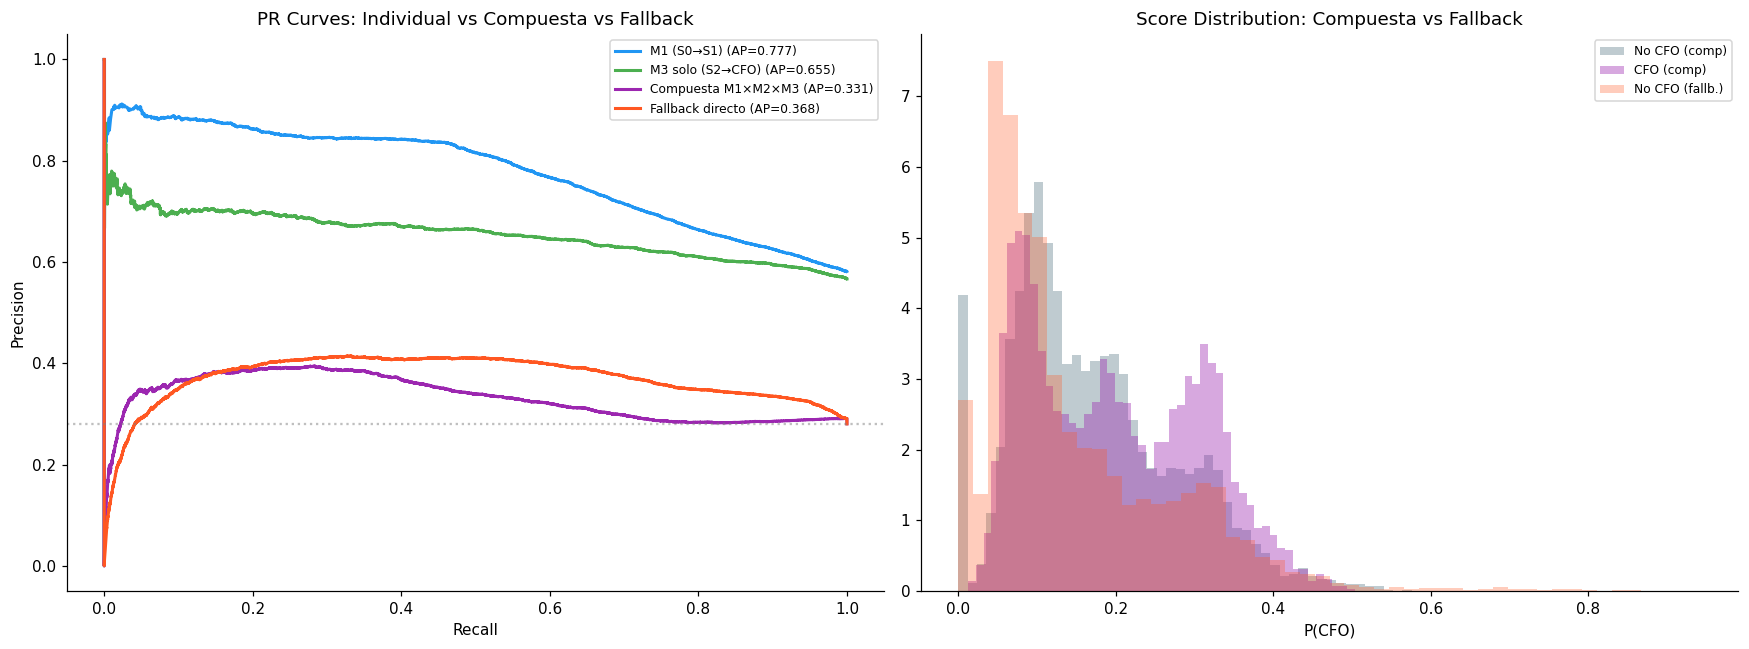

In [161]:
# ── Evaluate composed probability + fallback ─────────────────────────────────
y_true_all = score_df["is_cfo"].values
y_comp     = score_df["p_cfo_composed"].values
y_fallback = score_df["p_cfo_fallback"].values
y_t1_only  = score_df["p_s1_s0"].values

print("=== Evaluación Probabilidad Compuesta vs Fallback vs Single-Stage (test) ===")
res_comp = [
    evaluate_binary(y_true_all, np.full(len(y_true_all), score_df["is_cfo"].mean()), "Constante"),
    evaluate_binary(y_true_all, y_t1_only,  "Solo M1: P(S1|S0)"),
    evaluate_binary(y_true_all, y_comp,     "Compuesta: M1×M2×M3 (cond. fallback)"),
    evaluate_binary(y_true_all, y_fallback, "Fallback directo (cfos0/cfos1/M3)"),
    evaluate_binary(y_true_all, fb_p_cfos0_te, "Direct P(CFO|S0)"),
]
print(pd.DataFrame(res_comp).set_index("Model").to_string())

print("\n=== Precision@K y Lift@K ===")
print(f"{'Corte':>6}  {'Compuesta':>11}  {'Fallback':>10}  {'Solo M1':>9}  {'Lift Comp':>10}")
for k in [0.05, 0.10, 0.20, 0.30]:
    pc = precision_at_k(y_true_all, y_comp, k)
    pf = precision_at_k(y_true_all, y_fallback, k)
    pt = precision_at_k(y_true_all, y_t1_only, k)
    lc = lift_at_k(y_true_all, y_comp, k)
    print(f"{int(k*100):>5}%  {pc:>11.4f}  {pf:>10.4f}  {pt:>9.4f}  {lc:>9.2f}x")

# PR curves comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for (yt_, yp_, label, color) in [
    (y_te1.values, p1_test,    "M1 (S0→S1)",              "#2196F3"),
    (y_te3.values, p3_test,    "M3 solo (S2→CFO)",        "#4CAF50"),
    (y_true_all,   y_comp,     "Compuesta M1×M2×M3",      "#9C27B0"),
    (y_true_all,   y_fallback, "Fallback directo",         "#FF5722"),
]:
    p_, r_, _ = precision_recall_curve(yt_, yp_)
    axes[0].plot(r_, p_, lw=2, label=f"{label} (AP={average_precision_score(yt_, yp_):.3f})", color=color)
axes[0].axhline(float(y_true_all.mean()), ls=":", color="gray", alpha=0.5)
axes[0].set_title("PR Curves: Individual vs Compuesta vs Fallback")
axes[0].legend(fontsize=8); axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")

axes[1].hist(y_comp[y_true_all==0],    bins=50, alpha=0.4, density=True, color="#607D8B", label="No CFO (comp)")
axes[1].hist(y_comp[y_true_all==1],    bins=50, alpha=0.4, density=True, color="#9C27B0", label="CFO (comp)")
axes[1].hist(y_fallback[y_true_all==0],bins=50, alpha=0.3, density=True, color="#FF5722", label="No CFO (fallb.)", linestyle="--")
axes[1].set_title("Score Distribution: Compuesta vs Fallback")
axes[1].set_xlabel("P(CFO)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


Las métricas de Precision@K y Lift nos dicen cuánto mejora el ranking compuesto vs usar solo M1. Las curvas PR y la distribución de scores muestran si la composición separa bien positivos de negativos.

## 17. Calibración

Un modelo puede rankear muy bien (alto AUC) pero dar probabilidades distorsionadas — por ejemplo, predecir 40% cuando la frecuencia real es 60%. Aquí calibramos con Platt Scaling e Isotonic Regression: ajustamos en validation, evaluamos en test, y para cada modelo elegimos el método con menor Brier Score.

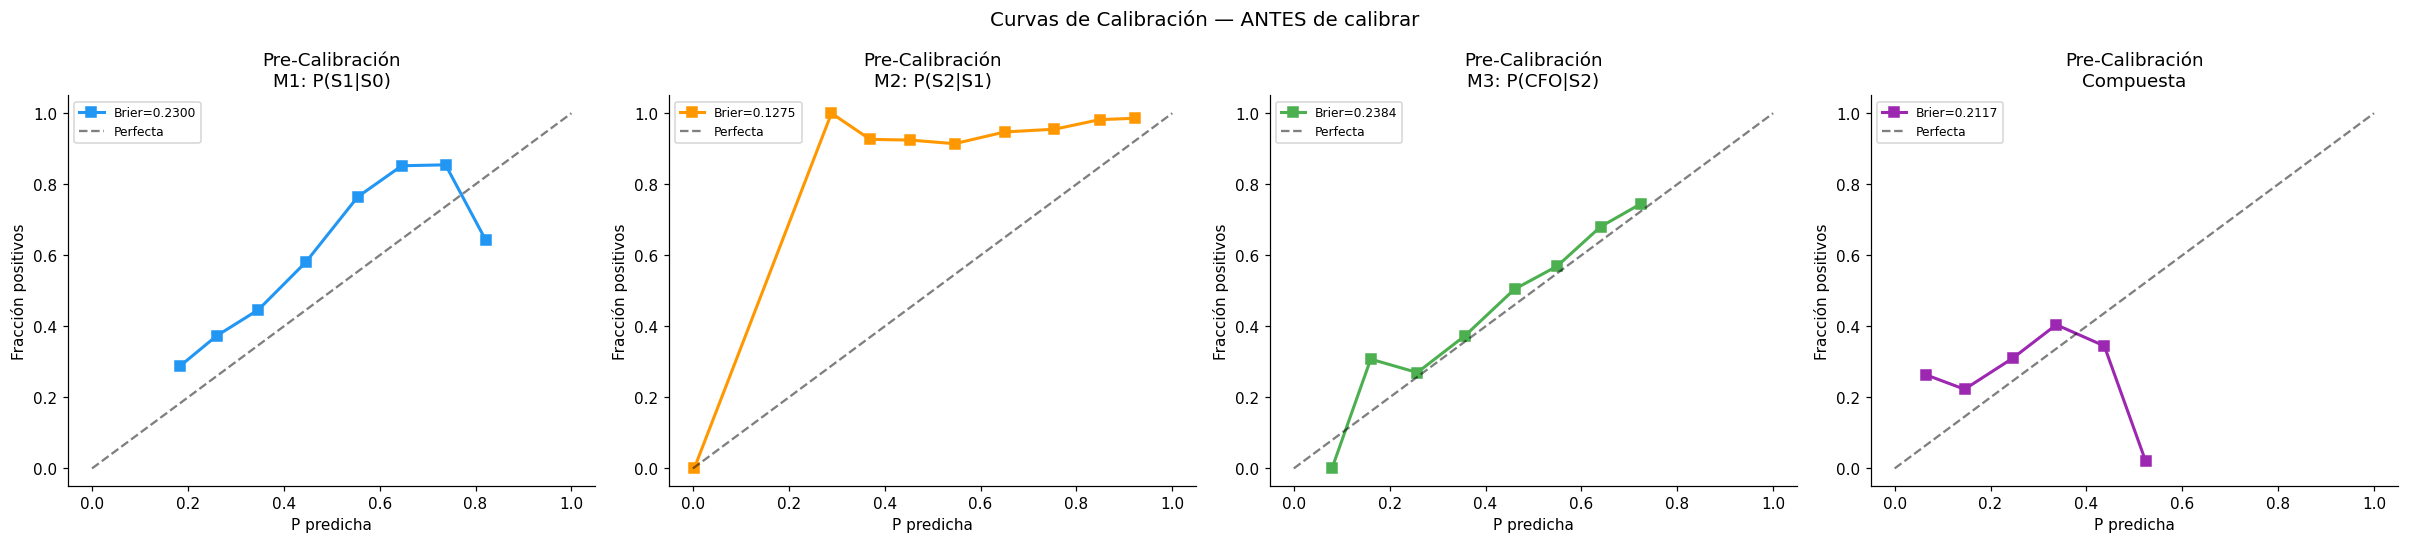

=== Calibración: Platt Scaling vs Isotonic Regression ===

  Modelos seleccionados: M1=[Logistic Regression]  M2=[Random Forest]  M3=[Logistic Regression]

  M1: raw=0.22996 → Platt=0.25331  ISO=0.25406  → mejor: Platt (Δ=-0.02335)
  M2: raw=0.12754 → Platt=0.04568  ISO=0.04398  → mejor: Isotonic (Δ=+0.08357)
  M3: raw=0.23842 → Platt=0.24010  ISO=0.23942  → mejor: Isotonic (Δ=-0.00100)

=== Resumen de Calibración ===
        Brier_raw  Brier_Platt  Brier_ISO      Best   Δ_best
Modelo                                                      
M1        0.22996      0.25331    0.25406     Platt -0.02335
M2        0.12754      0.04568    0.04398  Isotonic  0.08357
M3        0.23842      0.24010    0.23942  Isotonic -0.00100


In [162]:

# ── Calibration curves: PRE-calibration ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cal_entries = [
    (y_te1.values, p1_best, "#2196F3", "M1: P(S1|S0)"),
    (y_te2.values, p2_best, "#FF9800", "M2: P(S2|S1)"),
    (y_te3.values, p3_best, "#4CAF50", "M3: P(CFO|S2)"),
    (y_true_all,   y_comp,  "#9C27B0", "Compuesta"),
]
cal_results = []
for ax, (yt, yp, color, label) in zip(axes, cal_entries):
    fop, mpv = calibration_curve(yt, yp, n_bins=10, strategy="uniform")
    brier    = brier_score_loss(yt, yp)
    ax.plot(mpv, fop, "s-", lw=2, color=color, label=f"Brier={brier:.4f}")
    ax.plot([0,1],[0,1],"k--",alpha=0.5,label="Perfecta")
    ax.set_title(f"Pre-Calibración\n{label}"); ax.legend(fontsize=8)
    ax.set_xlabel("P predicha"); ax.set_ylabel("Fracción positivos")
    cal_results.append({"Modelo": label, "Brier_raw": brier,
                        "AUC-PR": round(average_precision_score(yt, yp), 4)})
plt.suptitle("Curvas de Calibración — ANTES de calibrar", fontsize=13)
plt.tight_layout(); plt.show()

# ── Platt Scaling ─────────────────────────────────────────────────────────────
def platt_scale(y_cal, p_cal, p_apply):
    eps = 1e-7
    lo_cal   = np.log(np.clip(p_cal,   eps, 1-eps) / (1 - np.clip(p_cal,   eps, 1-eps)))
    lo_apply = np.log(np.clip(p_apply, eps, 1-eps) / (1 - np.clip(p_apply, eps, 1-eps)))
    lr_c = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr_c.fit(lo_cal.reshape(-1,1), y_cal)
    return lr_c.predict_proba(lo_apply.reshape(-1,1))[:, 1]

# ── Isotonic Regression ───────────────────────────────────────────────────────
def isotonic_scale(y_cal, p_cal, p_apply):
    ir = IsoReg(out_of_bounds="clip")
    ir.fit(p_cal, y_cal)
    return ir.predict(p_apply)

# ── Calibrate each model on its validation set (both methods) ─────────────────
# p_best_val: validation-set probabilities for the selected model (any algorithm)
# This is used for calibration regardless of which model type was selected.
print("=== Calibración: Platt Scaling vs Isotonic Regression ===\n")
print(f"  Modelos seleccionados: M1=[{m1_type}]  M2=[{m2_type}]  M3=[{m3_type}]")
print()

_val_preds = [
    (y_va1.values, np.asarray(p1_best_val), y_te1.values, np.asarray(p1_best), "M1"),
    (y_va2.values, np.asarray(p2_best_val), y_te2.values, np.asarray(p2_best), "M2"),
    (y_va3.values, np.asarray(p3_best_val), y_te3.values, np.asarray(p3_best), "M3"),
]

cal_detail = []
p_final = {}  # best calibrated probabilities per model key

for (y_val, p_val, y_test, p_test, mname) in _val_preds:
    p_platt    = platt_scale(y_val, p_val, p_test)
    p_iso      = isotonic_scale(y_val, p_val, p_test)
    b_raw      = brier_score_loss(y_test, p_test)
    b_platt    = brier_score_loss(y_test, p_platt)
    b_iso      = brier_score_loss(y_test, p_iso)
    # Select best calibration method
    best_b     = min(b_platt, b_iso)
    best_name  = "Platt" if b_platt <= b_iso else "Isotonic"
    p_final[mname] = p_platt if best_name == "Platt" else p_iso
    cal_detail.append({
        "Modelo": mname, "Brier_raw": round(b_raw,5),
        "Brier_Platt": round(b_platt,5), "Brier_ISO": round(b_iso,5),
        "Best": best_name, "Δ_best": round(b_raw - best_b, 5),
    })
    print(f"  {mname}: raw={b_raw:.5f} → Platt={b_platt:.5f}  ISO={b_iso:.5f}  "
          f"→ mejor: {best_name} (Δ={b_raw-best_b:+.5f})")

print("\n=== Resumen de Calibración ===")
print(pd.DataFrame(cal_detail).set_index("Modelo").to_string())

p1_cal = p_final["M1"]
p2_cal = p_final["M2"]
p3_cal = p_final["M3"]


Tras la calibración, el Brier Score debería mejorar, acercando las probabilidades predichas a las frecuencias reales. Esto importa si vamos a usar los scores como inputs para decisiones cuantitativas de negocio.

## 18. Interpretabilidad — SHAP

Usamos SHAP (TreeExplainer) para entender qué features están moviendo cada modelo. No basta con predecir: necesitamos saber *por qué* un lead tiene score bajo para poder actuar operativamente.

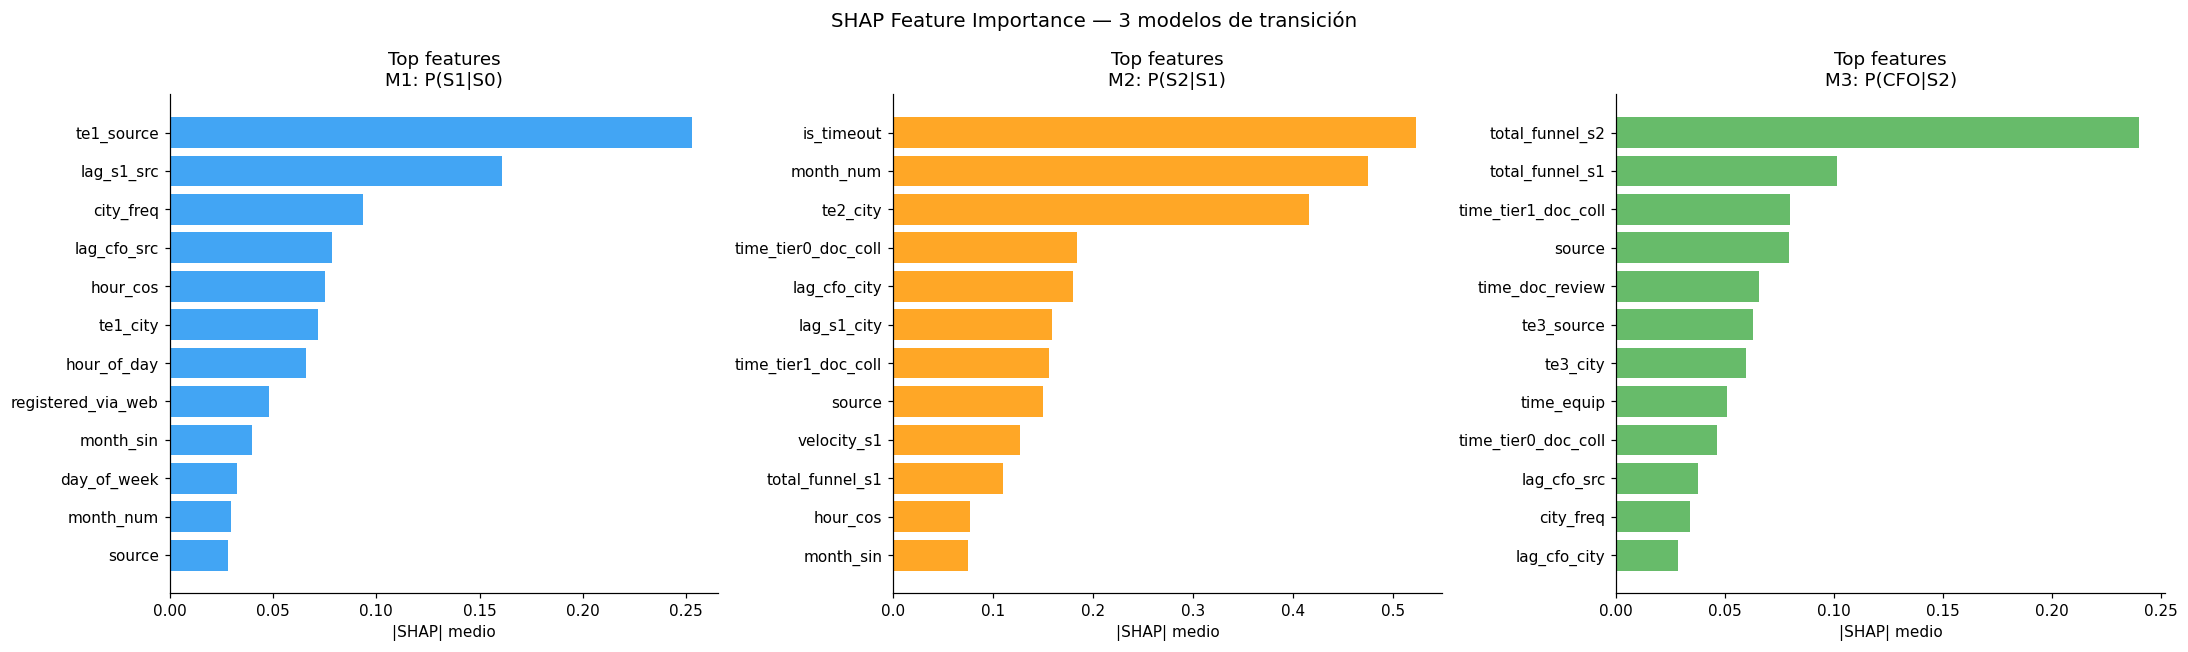

In [163]:
SHAP_N = 2000
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

shap_data = [
    (m1, X_te1, FEAT_T1, "#2196F3", "M1: P(S1|S0)"),
    (m2, X_te2, FEAT_T2, "#FF9800", "M2: P(S2|S1)"),
    (m3, X_te3, FEAT_T3_SEL, "#4CAF50", "M3: P(CFO|S2)"),
]
shap_explainers = {}

for ax, (model, X_te, feats, color, title) in zip(axes, shap_data):
    X_s  = X_te.sample(min(SHAP_N, len(X_te)), random_state=RANDOM_STATE)
    exp  = shap.TreeExplainer(model)
    svs  = exp.shap_values(X_s)
    shap_explainers[title] = (exp, X_s, svs, feats)
    mean_abs = np.abs(svs).mean(0)
    top_idx  = mean_abs.argsort()[::-1][:12]
    top_feats = [feats[i] for i in top_idx]
    top_vals  = mean_abs[top_idx]
    ax.barh(top_feats[::-1], top_vals[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top features\n{title}"); ax.set_xlabel("|SHAP| medio")

plt.suptitle("SHAP Feature Importance — 3 modelos de transición", fontsize=13)
plt.tight_layout(); plt.show()

Los top features por transición revelan drivers distintos en cada etapa. M1 suele estar dominado por perfil y contexto (ciudad, source), M2 por velocidad operativa (tiempos de doc collection), y M3 por tiempos post-contratación — lo cual tiene sentido causal.

Profundizamos con un beeswarm plot para M3 (el más accionable operativamente) y un comparativo que destaca qué features son exclusivas de cada etapa del funnel vs las compartidas por todos.

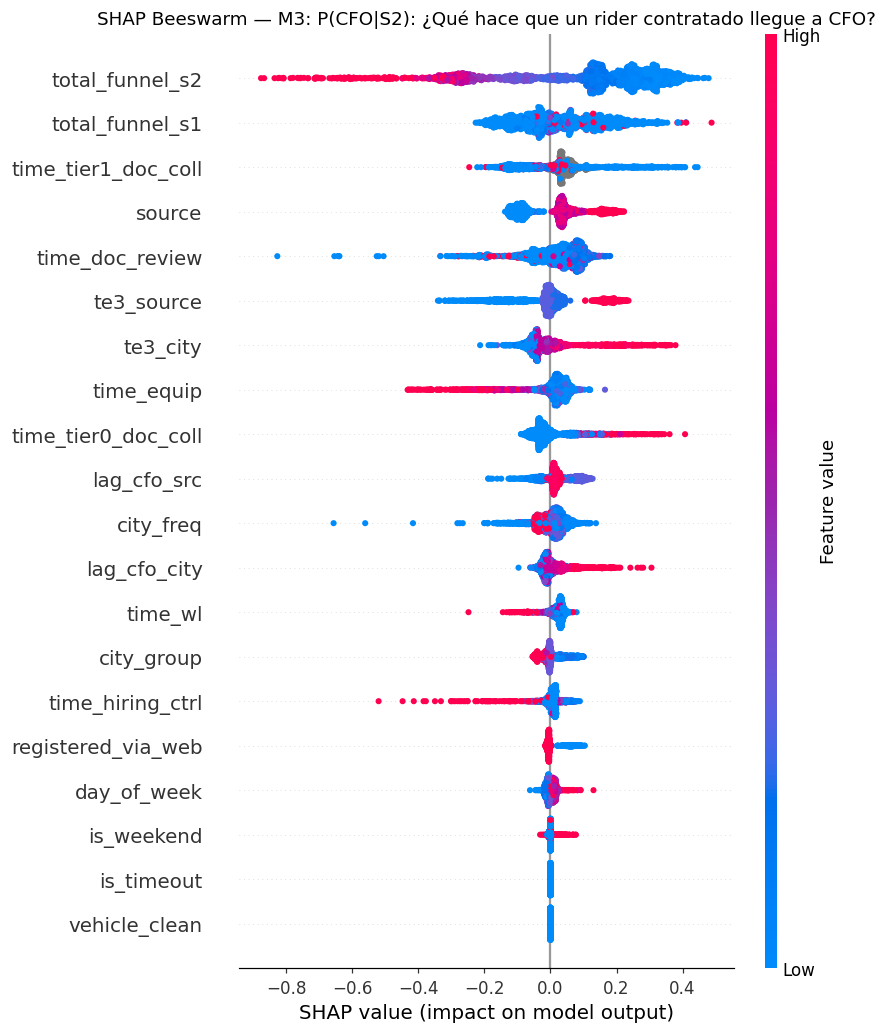

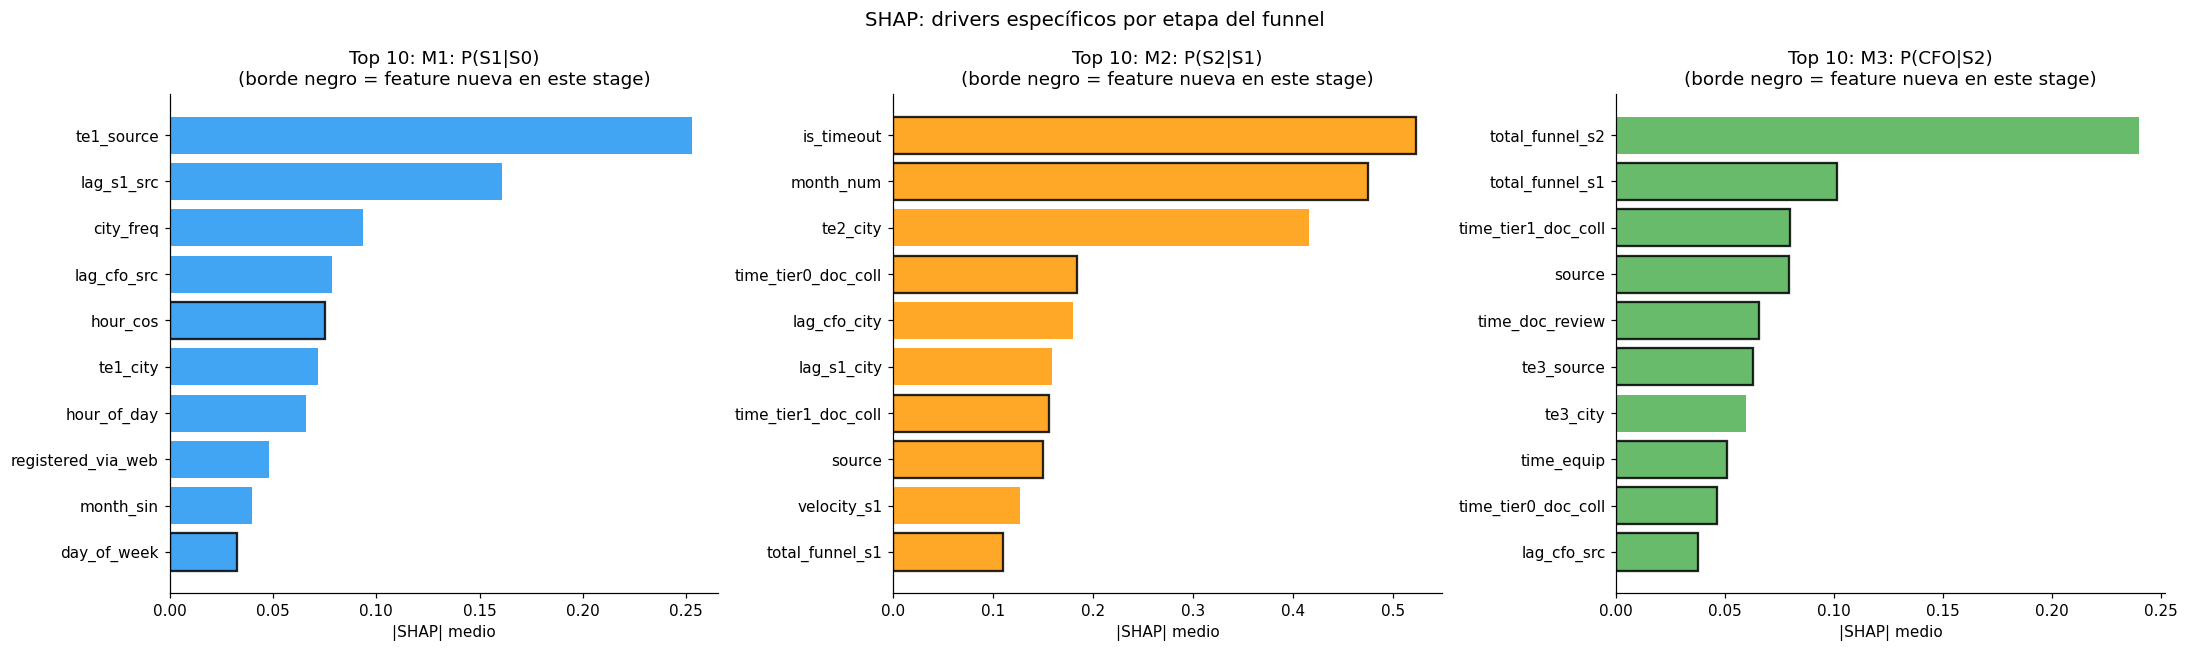


Insights por transición:
  M1 (S0→S1):  drivers de intención inicial — ciudad, source, hora de registro
  M2 (S1→S2):  velocidad de doc review (time_tier0_doc_coll, time_tier1_doc_coll, total_funnel_s1)
  M3 (S2→CFO): comportamiento post-hiring — time_equip, time_hiring_ctrl, lead_to_hired


In [164]:
# ── SHAP Beeswarm para M3 (más importante operativamente) ────────────────────
_, X_s3, svs3, _ = shap_explainers["M3: P(CFO|S2)"]

plt.figure(figsize=(10, 7))
shap.summary_plot(svs3, X_s3, plot_type="dot", max_display=len(FEAT_T3_SEL), show=False)
plt.title("SHAP Beeswarm — M3: P(CFO|S2): ¿Qué hace que un rider contratado llegue a CFO?")
plt.tight_layout(); plt.show()

# ── SHAP comparativo: qué features son exclusivas de cada transición ──────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_sh = {"M1: P(S1|S0)": "#2196F3", "M2: P(S2|S1)": "#FF9800", "M3: P(CFO|S2)": "#4CAF50"}
feats_order = {"M1: P(S1|S0)": FEAT_T1, "M2: P(S2|S1)": FEAT_T2, "M3: P(CFO|S2)": FEAT_T3_SEL}

for ax, key in zip(axes, ["M1: P(S1|S0)", "M2: P(S2|S1)", "M3: P(CFO|S2)"]):
    exp, X_s, svs, feats = shap_explainers[key]
    mean_abs = np.abs(svs).mean(0)
    top_idx  = mean_abs.argsort()[::-1][:10]
    top_f    = [feats[i] for i in top_idx]
    top_v    = mean_abs[top_idx]
    bars = ax.barh(top_f[::-1], top_v[::-1], color=colors_sh[key], alpha=0.85)
    # Highlight features unique to this transition stage
    for bar, feat in zip(bars[::-1], top_f[::-1]):
        if feat not in FEAT_BASE:
            bar.set_edgecolor("black"); bar.set_linewidth(1.5)
    ax.set_title(f"Top 10: {key}\n(borde negro = feature nueva en este stage)")
    ax.set_xlabel("|SHAP| medio")

plt.suptitle("SHAP: drivers específicos por etapa del funnel", fontsize=13)
plt.tight_layout(); plt.show()

print("\nInsights por transición:")
print("  M1 (S0→S1):  drivers de intención inicial — ciudad, source, hora de registro")
print("  M2 (S1→S2):  velocidad de doc review (time_tier0_doc_coll, time_tier1_doc_coll, total_funnel_s1)")
print("  M3 (S2→CFO): comportamiento post-hiring — time_equip, time_hiring_ctrl, lead_to_hired")

El beeswarm muestra no solo la importancia de cada feature sino la dirección del efecto: ¿más tiempo en equipment collection aumenta o disminuye la probabilidad de CFO? Esto es lo que permite hacer recomendaciones concretas al equipo de operaciones.

## 19. Análisis de drift temporal

Evaluamos si el modelo mantiene su performance estable mes a mes en el set de test. Medimos AUC-PR mensual para cada estrategia de scoring y comparamos con la evolución de la tasa real de CFO. Si el target cambia pero el modelo lo sigue, es robusto. También desglosamos por ciudad para detectar drift local.

=== ANÁLISIS DE DRIFT TEMPORAL ===

AUC-PR mensual (test set):
             n   cfo_rate   AP_M1  AP_Compuesta  AP_Cal.  AP_Fallback
period                                                               
2025-12     94  30.851064  0.3735        0.3164   0.4266       0.2039
2026-01  11227  26.195778  0.4226        0.3547   0.4910       0.5344
2026-02   5838  32.151422  0.4247        0.3590   0.4681       0.3751
2026-03   2162  28.445883  0.3013        0.2404   0.3054       0.2019
2026-04    246  10.975610  0.1413        0.1067   0.1472       0.0755


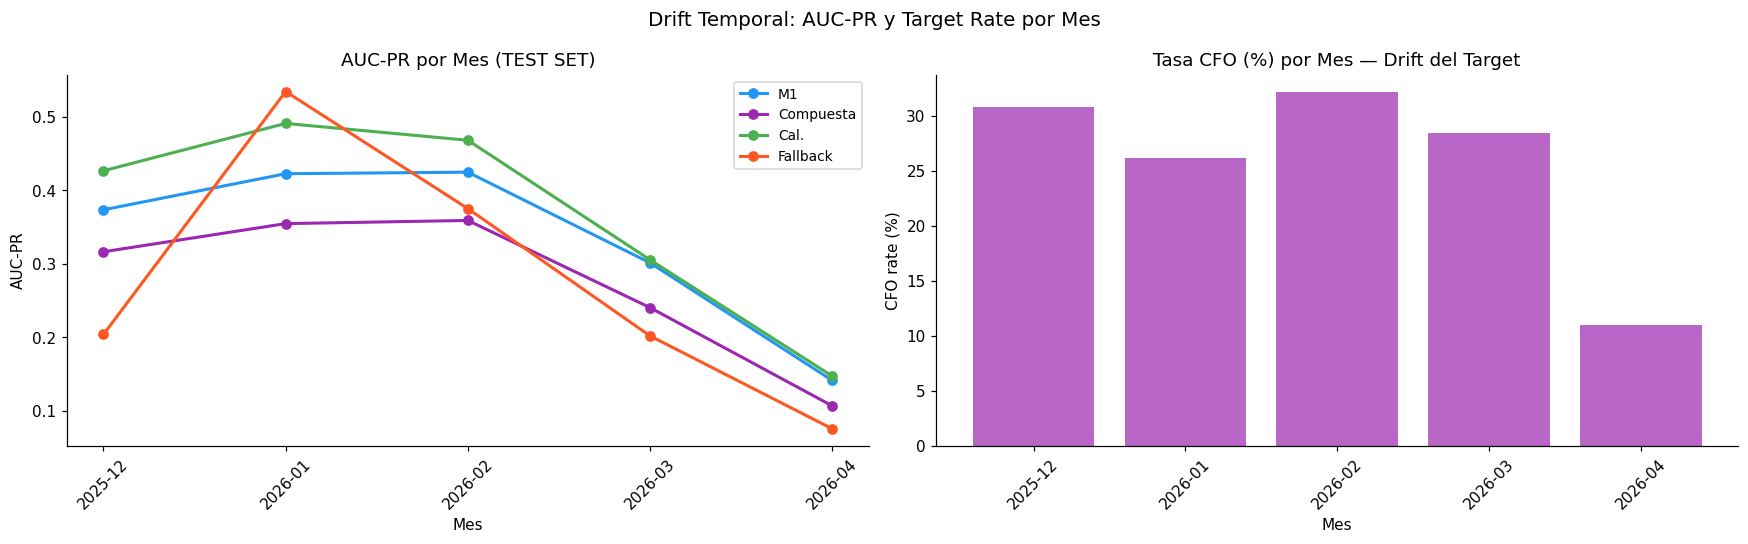


=== AUC-PR por Ciudad (TEST SET) ===
 city    n  cfo_rate  AP_Compuesta  AP_Cal.
  LOD 1123      41.0        0.4671   0.6067
  BZG  400      35.5        0.4604   0.5356
  TUN  299      36.1        0.4259   0.5840
  CZW  176      35.2        0.4155   0.5519
  RZE  224      32.1        0.4034   0.5121
  GDN 1121      33.0        0.3799   0.4511
  QYY  207      33.8        0.3728   0.5875
  QLC  302      31.5        0.3678   0.4755
  WAW 3367      29.4        0.3562   0.4440
  SOS  300      27.0        0.3477   0.5345
  SZY  299      28.1        0.3408   0.4486
  KRA 1170      30.5        0.3365   0.4527
  POZ  845      27.3        0.3323   0.4266
  SZZ  474      31.9        0.3230   0.4656
  QLU  210      29.5        0.3147   0.5621
  BYT  191      24.1        0.2972   0.4652
  WRO  879      20.6        0.2725   0.4112
  OPL  179      29.6        0.2686   0.3725
OTHER 7284      24.5        0.2552   0.4576
  QEO  147      22.4        0.2449   0.5129
  KTW  370      15.9        0.1851   0

In [165]:

# ── Drift Analysis: AUC-PR por mes ────────────────────────────────────────────
print("=== ANÁLISIS DE DRIFT TEMPORAL ===\n")

# Align calibrated probs to score_df index (te2/te3 are subsets of te1)
p2_cal_aligned = (pd.Series(p2_cal, index=te2.index)
                  .reindex(score_df.index)
                  .fillna(score_df["p_s2_s1"])   # fallback: uncalibrated score
                  .values)
p3_cal_aligned = (pd.Series(p3_cal, index=X_te3.index)
                  .reindex(score_df.index)
                  .fillna(score_df["p_cfo_s2"])  # fallback: uncalibrated score
                  .values)
y_comp_cal = p1_cal * p2_cal_aligned * p3_cal_aligned

score_df_drift = score_df.copy()
score_df_drift["p1_cal"] = p1_cal
score_df_drift["p2_cal_al"] = p2_cal_aligned
score_df_drift["p3_cal_al"] = p3_cal_aligned
score_df_drift["p_cfo_cal"] = y_comp_cal

# AUC-PR por mes: M1, Compuesta, Compuesta calibrada
monthly_perf = []
for period, grp in score_df_drift.groupby("_month_period"):
    row = {"period": period, "n": len(grp), "cfo_rate": grp["is_cfo"].mean()*100}
    yt  = grp["is_cfo"].values
    if yt.sum() < 2 or yt.sum() == len(yt):
        continue  # skip degenerate months
    for col, lbl in [("p_s1_s0","M1"), ("p_cfo_composed","Compuesta"),
                     ("p_cfo_cal","Cal."), ("p_cfo_fallback","Fallback")]:
        if col not in grp.columns: continue
        try:
            row[f"AP_{lbl}"] = round(average_precision_score(yt, grp[col].values), 4)
        except Exception:
            row[f"AP_{lbl}"] = np.nan
    monthly_perf.append(row)

mp_df = pd.DataFrame(monthly_perf).set_index("period")
print("AUC-PR mensual (test set):")
print(mp_df.to_string())

# Plot: AUC-PR over time + target drift
ap_cols = [c for c in mp_df.columns if c.startswith("AP_")]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_drift = {"AP_M1":"#2196F3","AP_Compuesta":"#9C27B0","AP_Cal.":"#4CAF50","AP_Fallback":"#FF5722"}
for col in ap_cols:
    if col not in mp_df: continue
    axes[0].plot(mp_df.index, mp_df[col], "o-", lw=2,
                 label=col.replace("AP_",""), color=colors_drift.get(col,"gray"))
axes[0].set_title("AUC-PR por Mes (TEST SET)"); axes[0].set_xlabel("Mes")
axes[0].set_ylabel("AUC-PR"); axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(mp_df.index, mp_df["cfo_rate"], color="#9C27B0", alpha=0.7)
axes[1].set_title("Tasa CFO (%) por Mes — Drift del Target")
axes[1].set_xlabel("Mes"); axes[1].set_ylabel("CFO rate (%)")
axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Drift Temporal: AUC-PR y Target Rate por Mes", fontsize=13)
plt.tight_layout(); plt.show()

# ── Drift por ciudad ──────────────────────────────────────────────────────────
print("\n=== AUC-PR por Ciudad (TEST SET) ===")
city_perf = []
for city_code, grp in score_df_drift.groupby("city_group"):
    yt = grp["is_cfo"].values
    if len(grp) < 20 or yt.sum() < 2 or yt.sum() == len(yt): continue
    try:
        city_name = le_dict["city_group"].inverse_transform([int(city_code)])[0]
    except Exception:
        city_name = str(city_code)
    row = {"city": city_name, "n": len(grp), "cfo_rate": round(yt.mean()*100,1)}
    for col, lbl in [("p_cfo_composed","Compuesta"), ("p_cfo_cal","Cal.")]:
        if col in grp.columns:
            try:
                row[f"AP_{lbl}"] = round(average_precision_score(yt, grp[col].values), 4)
            except Exception:
                row[f"AP_{lbl}"] = np.nan
    city_perf.append(row)

cp_df = pd.DataFrame(city_perf).sort_values("AP_Compuesta", ascending=False)
print(cp_df.to_string(index=False))

# Check for cities with major drift (AP < 0.5 or significantly below mean)
mean_ap = cp_df["AP_Compuesta"].mean() if "AP_Compuesta" in cp_df else 0
flagged = cp_df[cp_df.get("AP_Compuesta", pd.Series()) < mean_ap * 0.75]
if len(flagged) > 0:
    print(f"\n⚠️  Ciudades con AUC-PR < 75% de la media ({mean_ap:.3f}):")
    print(flagged[["city","n","cfo_rate","AP_Compuesta"]].to_string(index=False))
else:
    print("\n✅  Sin ciudades con drift severo detectado.")


La tabla y los gráficos mensuales nos dicen si hay meses o ciudades donde el modelo pierde tracción. Si algún segmento cae muy por debajo de la media, merece una investigación específica.

## 20. Rendimiento por segmento: sources y ciudades

Desglosamos las tasas de conversión reales por source (M1) y por ciudad (M2), comparando con la media global. Esto identifica los segmentos que más contribuyen al funnel y los que actúan como freno.

  M1 — CONVERSIÓN S0→S1 POR SOURCE  (base: 50.2%)
      Source     N  CR S0→S1 (%) vs base
    REFERRAL 13048          71.9 +21.7pp
         3PL 41186          65.2 +15.0pp
     ORGANIC 73416          46.3  -3.9pp
   RIDER WEB  2683          39.7 -10.5pp
    PERF MKT 20258          37.5 -12.7pp
JOB PLATFORM 15443          28.8 -21.4pp

  M2 — CONVERSIÓN S1→S2 POR CIUDAD  (base: 89.3%)
Ciudad     N  CR S1→S2 (%) vs base
   WAW 17282          95.0  +5.7pp
   BYT   678          94.8  +5.5pp
   GDN  4920          94.8  +5.5pp
   POZ  4791          92.4  +3.1pp
   QLC   932          92.3  +3.0pp
   QYY   959          92.1  +2.8pp
   KRA  6385          91.4  +2.1pp
   SZY  1180          91.0  +1.7pp
   KTW  2064          90.6  +1.3pp
   BZG  1686          89.7  +0.4pp
   SZZ  2126          89.2  -0.1pp
   WRO  5030          87.8  -1.5pp
   RZE   961          87.0  -2.3pp
   OPL   628          86.9  -2.4pp
   SOS   850          86.9  -2.4pp
   LOD  5189          85.3  -4.0pp
   QLU  1171     

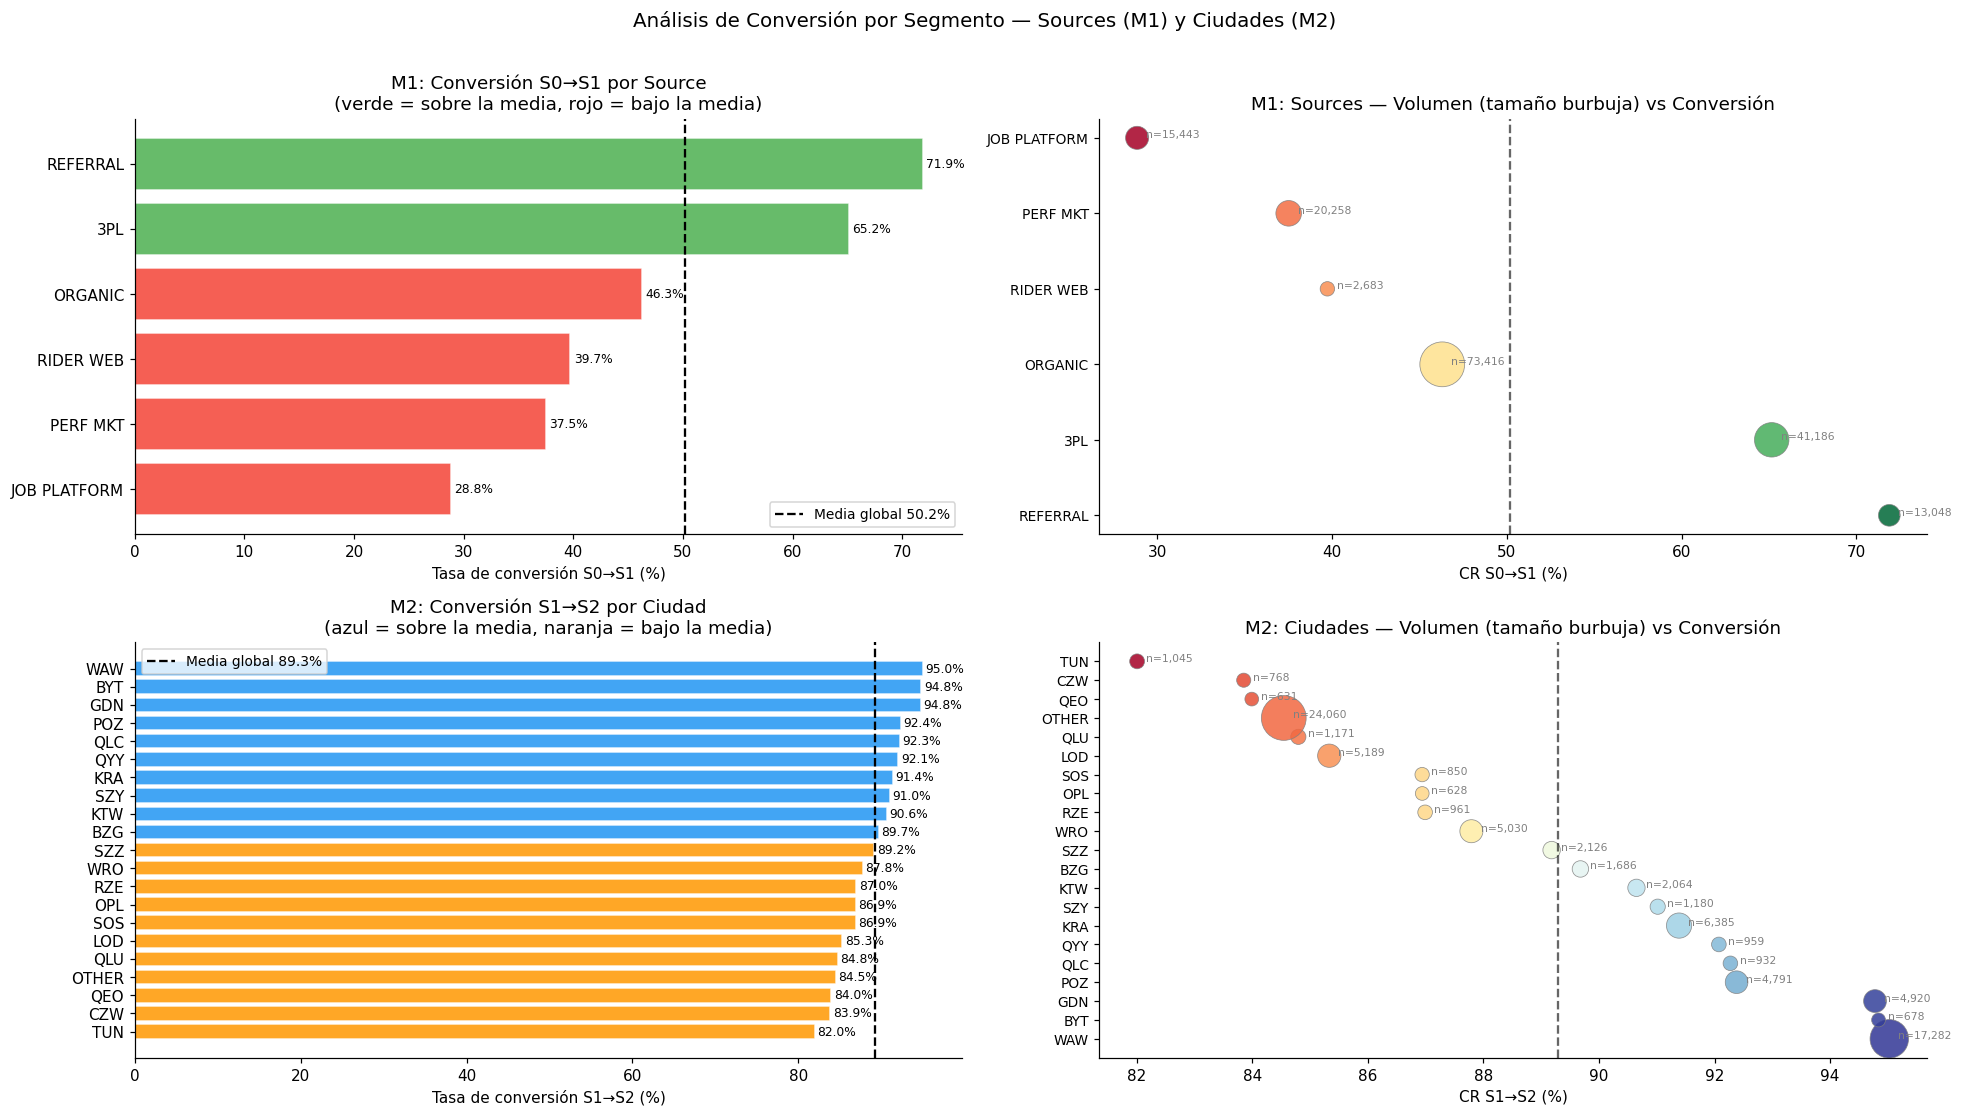

In [166]:

def _decode(series, col):
    """Inverse-transform a label-encoded column using le_dict."""
    try:
        return le_dict[col].inverse_transform(series.astype(int).values)
    except Exception:
        return series.astype(str).values

MIN_N = 30   # minimum observations to show a segment

# ── 1. SOURCES → M1: P(S1|S0) ────────────────────────────────────────────────
_df1 = pd.concat([tr1, va1, te1]).copy()
_df1["source_name"] = _decode(_df1["source"], "source")

src_stats = (
    _df1.groupby("source_name", observed=True)
    .agg(
        n           = ("TARGET", "count"),
        cr_s1       = ("TARGET", "mean"),
    )
    .reset_index()
    .query(f"n >= {MIN_N}")
    .sort_values("cr_s1", ascending=False)
    .reset_index(drop=True)
)
src_stats["cr_s1_pct"] = src_stats["cr_s1"] * 100
base_s1 = _df1["TARGET"].mean() * 100

# ── 2. CITIES → M2: P(S2|S1) ─────────────────────────────────────────────────
_df2 = pd.concat([tr2, va2, te2]).copy()
_df2["city_name"] = _decode(_df2["city_group"], "city_group")

city_stats = (
    _df2.groupby("city_name", observed=True)
    .agg(
        n       = ("TARGET", "count"),
        cr_s2   = ("TARGET", "mean"),
    )
    .reset_index()
    .query(f"n >= {MIN_N}")
    .sort_values("cr_s2", ascending=False)
    .reset_index(drop=True)
)
city_stats["cr_s2_pct"] = city_stats["cr_s2"] * 100
base_s2 = _df2["TARGET"].mean() * 100

# ── 3. Print tables ───────────────────────────────────────────────────────────
print("=" * 60)
print(f"  M1 — CONVERSIÓN S0→S1 POR SOURCE  (base: {base_s1:.1f}%)")
print("=" * 60)
_src_print = src_stats[["source_name", "n", "cr_s1_pct"]].copy()
_src_print.columns = ["Source", "N", "CR S0→S1 (%)"]
_src_print["CR S0→S1 (%)"] = _src_print["CR S0→S1 (%)"].round(1)
_src_print["vs base"] = (_src_print["CR S0→S1 (%)"] - base_s1).round(1).apply(lambda x: f"{x:+.1f}pp")
print(_src_print.to_string(index=False))

print()
print("=" * 60)
print(f"  M2 — CONVERSIÓN S1→S2 POR CIUDAD  (base: {base_s2:.1f}%)")
print("=" * 60)
_city_print = city_stats[["city_name", "n", "cr_s2_pct"]].copy()
_city_print.columns = ["Ciudad", "N", "CR S1→S2 (%)"]
_city_print["CR S1→S2 (%)"] = _city_print["CR S1→S2 (%)"].round(1)
_city_print["vs base"] = (_city_print["CR S1→S2 (%)"] - base_s2).round(1).apply(lambda x: f"{x:+.1f}pp")
print(_city_print.to_string(index=False))

# ── 4. Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Panel A: Sources — conversion rate
clr_src = ["#4CAF50" if v > base_s1 else "#F44336" for v in src_stats["cr_s1_pct"]]
axes[0, 0].barh(src_stats["source_name"][::-1], src_stats["cr_s1_pct"][::-1],
                color=clr_src[::-1], alpha=0.85, edgecolor="white")
axes[0, 0].axvline(base_s1, color="black", ls="--", lw=1.5, label=f"Media global {base_s1:.1f}%")
axes[0, 0].set_xlabel("Tasa de conversión S0→S1 (%)")
axes[0, 0].set_title("M1: Conversión S0→S1 por Source\n(verde = sobre la media, rojo = bajo la media)")
axes[0, 0].legend(fontsize=9)
for i, (_, row_s) in enumerate(src_stats[::-1].iterrows()):
    axes[0, 0].text(row_s["cr_s1_pct"] + 0.3, i,
                    f"{row_s['cr_s1_pct']:.1f}%", va="center", fontsize=8)

# Panel B: Sources — volume bubble (n vs conversion rate)
sc = axes[0, 1].scatter(src_stats["cr_s1_pct"], range(len(src_stats)),
                        s=src_stats["n"] / src_stats["n"].max() * 800 + 60,
                        c=src_stats["cr_s1_pct"], cmap="RdYlGn",
                        edgecolors="gray", linewidth=0.5, alpha=0.85)
axes[0, 1].set_yticks(range(len(src_stats)))
axes[0, 1].set_yticklabels(src_stats["source_name"], fontsize=9)
axes[0, 1].axvline(base_s1, color="black", ls="--", lw=1.5, alpha=0.6)
axes[0, 1].set_xlabel("CR S0→S1 (%)")
axes[0, 1].set_title("M1: Sources — Volumen (tamaño burbuja) vs Conversión")
for i, row_s in src_stats.iterrows():
    axes[0, 1].annotate(f"n={row_s['n']:,}", (row_s["cr_s1_pct"], i),
                        textcoords="offset points", xytext=(6, 0), fontsize=7, color="gray")

# Panel C: Cities — conversion rate
clr_city = ["#2196F3" if v > base_s2 else "#FF9800" for v in city_stats["cr_s2_pct"]]
axes[1, 0].barh(city_stats["city_name"][::-1], city_stats["cr_s2_pct"][::-1],
                color=clr_city[::-1], alpha=0.85, edgecolor="white")
axes[1, 0].axvline(base_s2, color="black", ls="--", lw=1.5, label=f"Media global {base_s2:.1f}%")
axes[1, 0].set_xlabel("Tasa de conversión S1→S2 (%)")
axes[1, 0].set_title("M2: Conversión S1→S2 por Ciudad\n(azul = sobre la media, naranja = bajo la media)")
axes[1, 0].legend(fontsize=9)
for i, (_, row_c) in enumerate(city_stats[::-1].iterrows()):
    axes[1, 0].text(row_c["cr_s2_pct"] + 0.3, i,
                    f"{row_c['cr_s2_pct']:.1f}%", va="center", fontsize=8)

# Panel D: Cities — volume bubble
axes[1, 1].scatter(city_stats["cr_s2_pct"], range(len(city_stats)),
                   s=city_stats["n"] / city_stats["n"].max() * 800 + 60,
                   c=city_stats["cr_s2_pct"], cmap="RdYlBu",
                   edgecolors="gray", linewidth=0.5, alpha=0.85)
axes[1, 1].set_yticks(range(len(city_stats)))
axes[1, 1].set_yticklabels(city_stats["city_name"], fontsize=9)
axes[1, 1].axvline(base_s2, color="black", ls="--", lw=1.5, alpha=0.6)
axes[1, 1].set_xlabel("CR S1→S2 (%)")
axes[1, 1].set_title("M2: Ciudades — Volumen (tamaño burbuja) vs Conversión")
for i, row_c in city_stats.iterrows():
    axes[1, 1].annotate(f"n={row_c['n']:,}", (row_c["cr_s2_pct"], i),
                        textcoords="offset points", xytext=(6, 0), fontsize=7, color="gray")

plt.suptitle("Análisis de Conversión por Segmento — Sources (M1) y Ciudades (M2)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Los gráficos de burbujas combinan volumen y conversión: un source puede tener buena tasa pero poco volumen, o al revés. Las barras en rojo marcan los segmentos que están muy por debajo de la media.

## 21. Detección de cambios de tendencia

Calculamos la tasa de CFO mensual de todo el dataset y la comparamos con una media móvil de 3 meses. Si algún mes se desvía más de un 20%, lo marcamos como posible cambio estructural en el funnel.

=== DETECCIÓN DE DRIFT EN TASA DE CONVERSION ===

_month_period     n  s1_rate  cfo_rate  cfo_roll3  drift_flag
      2025-03 16863 0.493091  0.179743        NaN        <NA>
      2025-04 10481 0.557199  0.263715   0.179743        True
      2025-05 14696 0.523272   0.27715   0.221729       False
      2025-06 18839 0.474760  0.259568   0.240203       False
      2025-07 16469 0.482361  0.213188   0.266811        True
      2025-08 13415 0.437272  0.228476   0.249969       False
      2025-09 17528 0.437814  0.251997   0.233744       False
      2025-10 15843 0.499905  0.267058   0.231220       False
      2025-11 13104 0.509386  0.285562   0.249177       False
      2025-12  9330 0.551125    0.2791   0.268205       False
      2026-01 11227 0.518571  0.261958   0.277240       False
      2026-02  5838 0.652278  0.321514   0.275540       False
      2026-03  2162 0.717854  0.284459   0.287524       False
      2026-04   246 0.585366  0.109756   0.289310        True


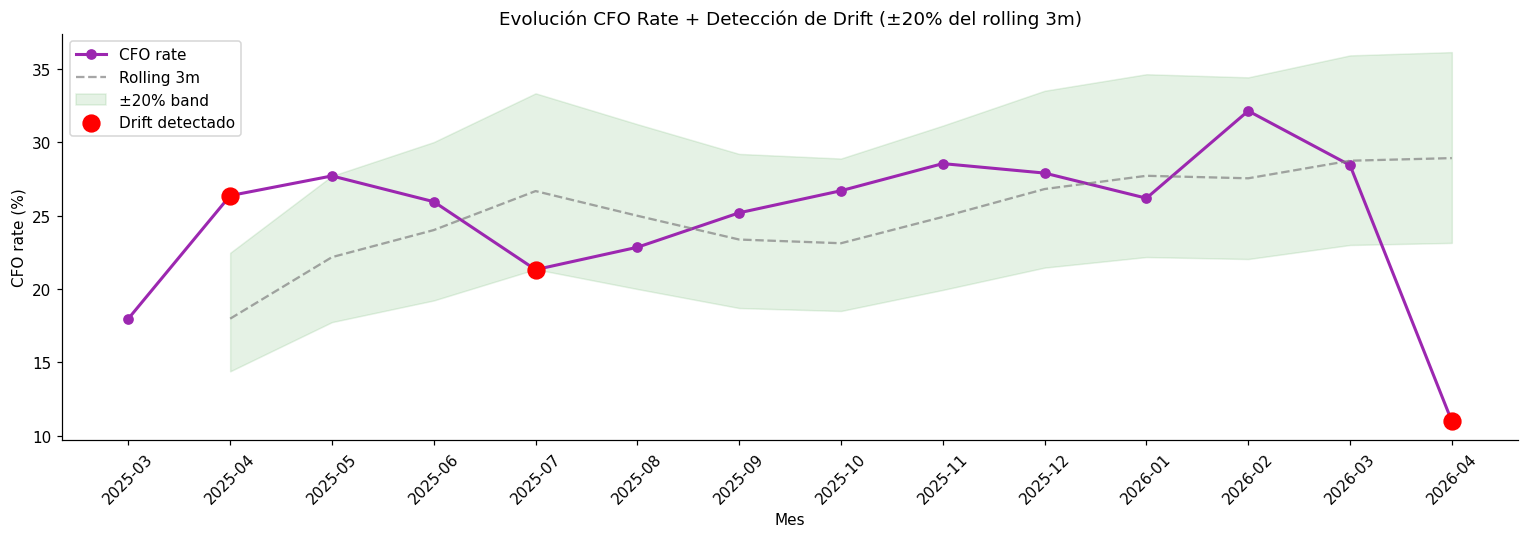


⚠️  DRIFT DETECTADO. Considerar:
  1. Añadir sample_weight temporal (más peso a meses recientes)
  2. Incluir 'month_num' como feature explícita
  3. Reentrenar con solo los últimos N meses de datos de train


In [167]:
# ── Temporal Trend: target rate shift detection ───────────────────────────────
print("=== DETECCIÓN DE DRIFT EN TASA DE CONVERSION ===\n")

# Full dataset monthly stats (train + val + test)
full_monthly = df.groupby("_month_period").agg(
    n=("is_cfo","count"),
    s1_rate=("reached_s1","mean"),
    s2_rate=("reached_s2","mean"),
    cfo_rate=("is_cfo","mean"),
).reset_index().sort_values("_month_period")

# Flag months where rate drops > 20% from trailing 3-month mean
full_monthly["cfo_roll3"] = full_monthly["cfo_rate"].rolling(3, min_periods=1).mean().shift(1)
full_monthly["drift_flag"] = (
    (full_monthly["cfo_rate"] < full_monthly["cfo_roll3"] * 0.80) |
    (full_monthly["cfo_rate"] > full_monthly["cfo_roll3"] * 1.25)
)

print(full_monthly[["_month_period","n","s1_rate","cfo_rate","cfo_roll3","drift_flag"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(full_monthly["_month_period"], full_monthly["cfo_rate"]*100, "o-", lw=2,
        color="#9C27B0", label="CFO rate")
ax.plot(full_monthly["_month_period"], full_monthly["cfo_roll3"]*100, "--",
        lw=1.5, color="gray", alpha=0.7, label="Rolling 3m")
ax.fill_between(range(len(full_monthly)),
                full_monthly["cfo_roll3"].values*80,
                full_monthly["cfo_roll3"].values*125, alpha=0.1, color="green",
                label="±20% band")
# Mark drift points
drift_pts = full_monthly[full_monthly["drift_flag"]]
if len(drift_pts):
    dp_x = [list(full_monthly["_month_period"]).index(p) for p in drift_pts["_month_period"]]
    ax.scatter(dp_x, drift_pts["cfo_rate"]*100, s=120, color="red", zorder=5, label="Drift detectado")
ax.set_title("Evolución CFO Rate + Detección de Drift (±20% del rolling 3m)")
ax.set_xlabel("Mes"); ax.set_ylabel("CFO rate (%)")
ax.tick_params(axis="x", rotation=45); ax.legend()
plt.tight_layout(); plt.show()

# ── Temporal weighting recommendation ────────────────────────────────────────
if full_monthly["drift_flag"].sum() > 0:
    print("\n⚠️  DRIFT DETECTADO. Considerar:")
    print("  1. Añadir sample_weight temporal (más peso a meses recientes)")
    print("  2. Incluir 'month_num' como feature explícita")
    print("  3. Reentrenar con solo los últimos N meses de datos de train")
else:
    print("\n✅  Sin cambios de tendencia significativos. Modelo estable.")


Si se detecta drift, podría ser necesario reentrenar con datos más recientes o añadir pesos temporales para darle más importancia a los últimos meses.

## 22. Diagnóstico de cuellos de botella

Para cada transición, identificamos los segmentos (ciudades, sources) con peor tasa de conversión en test. Estos son los cuellos de botella reales del funnel, donde hay más oportunidad de mejora operativa.

In [168]:
# ── Bottleneck: transition conversion rates by city and source ─────────────────
def conversion_by_seg(ds_train, ds_test, seg_col, target_col, le, min_n=15):
    """Segmented conversion rate for a given transition."""
    rows = []
    for seg_code, grp in ds_test.groupby(seg_col):
        if len(grp) < min_n: continue
        train_grp = ds_train[ds_train[seg_col] == seg_code]
        if len(train_grp) < 5: continue
        seg_name = le.inverse_transform([int(seg_code)])[0]
        rows.append({
            "segment":        seg_name,
            "n_test":         len(grp),
            "conv_rate_test": grp[target_col].mean(),
            "conv_rate_train":train_grp[target_col].mean(),
            "delta":          grp[target_col].mean() - train_grp[target_col].mean(),
        })
    return pd.DataFrame(rows).sort_values("conv_rate_test")

print("=== CUELLOS DE BOTELLA POR TRANSICIÓN ===\n")

print("▶ M1 — Ciudades con menor tasa S0→S1 (doc review) en test:")
cb_t1_city = conversion_by_seg(tr1, te1, "city_group", "TARGET", le_dict["city_group"], min_n=20)
print(cb_t1_city.head(8).to_string(index=False))

print("\n▶ M2 — Ciudades con menor tasa S1→S2 (hiring) en test:")
cb_t2_city = conversion_by_seg(tr2, te2, "city_group", "TARGET", le_dict["city_group"], min_n=10)
print(cb_t2_city.head(8).to_string(index=False))

print("\n▶ M3 — Sources con menor tasa S2→CFO en test:")
cb_t3_src = conversion_by_seg(tr3, te3, "source", "TARGET", le_dict["source"], min_n=5)
print(cb_t3_src.head(8).to_string(index=False))

=== CUELLOS DE BOTELLA POR TRANSICIÓN ===

▶ M1 — Ciudades con menor tasa S0→S1 (doc review) en test:
segment  n_test  conv_rate_test  conv_rate_train     delta
    KTW     370        0.464865         0.470435 -0.005570
    QLU     210        0.509524         0.509930 -0.000406
    QEO     147        0.510204         0.426806  0.083398
  OTHER    7284        0.515102         0.388933  0.126168
    WRO     879        0.516496         0.539960 -0.023464
    BYT     191        0.523560         0.434370  0.089191
    POZ     845        0.538462         0.541498 -0.003037
    QYY     207        0.565217         0.437838  0.127380

▶ M2 — Ciudades con menor tasa S1→S2 (hiring) en test:
segment  n_test  conv_rate_test  conv_rate_train     delta
    WRO     454        0.795154         0.892867 -0.097712
    KTW     172        0.825581         0.925447 -0.099865
    QEO      75        0.853333         0.837416  0.015917
    KRA     713        0.856942         0.937431 -0.080489
    SZY     190 

La tabla de cuellos de botella es directamente accionable: señala dónde centrar esfuerzos para maximizar el impacto en las conversiones.

Visualizamos los cuellos de botella por segmento y la evolución temporal de cada tasa de transición mes a mes. Esto da la vista completa: dónde están los problemas y si están empeorando o mejorando con el tiempo.

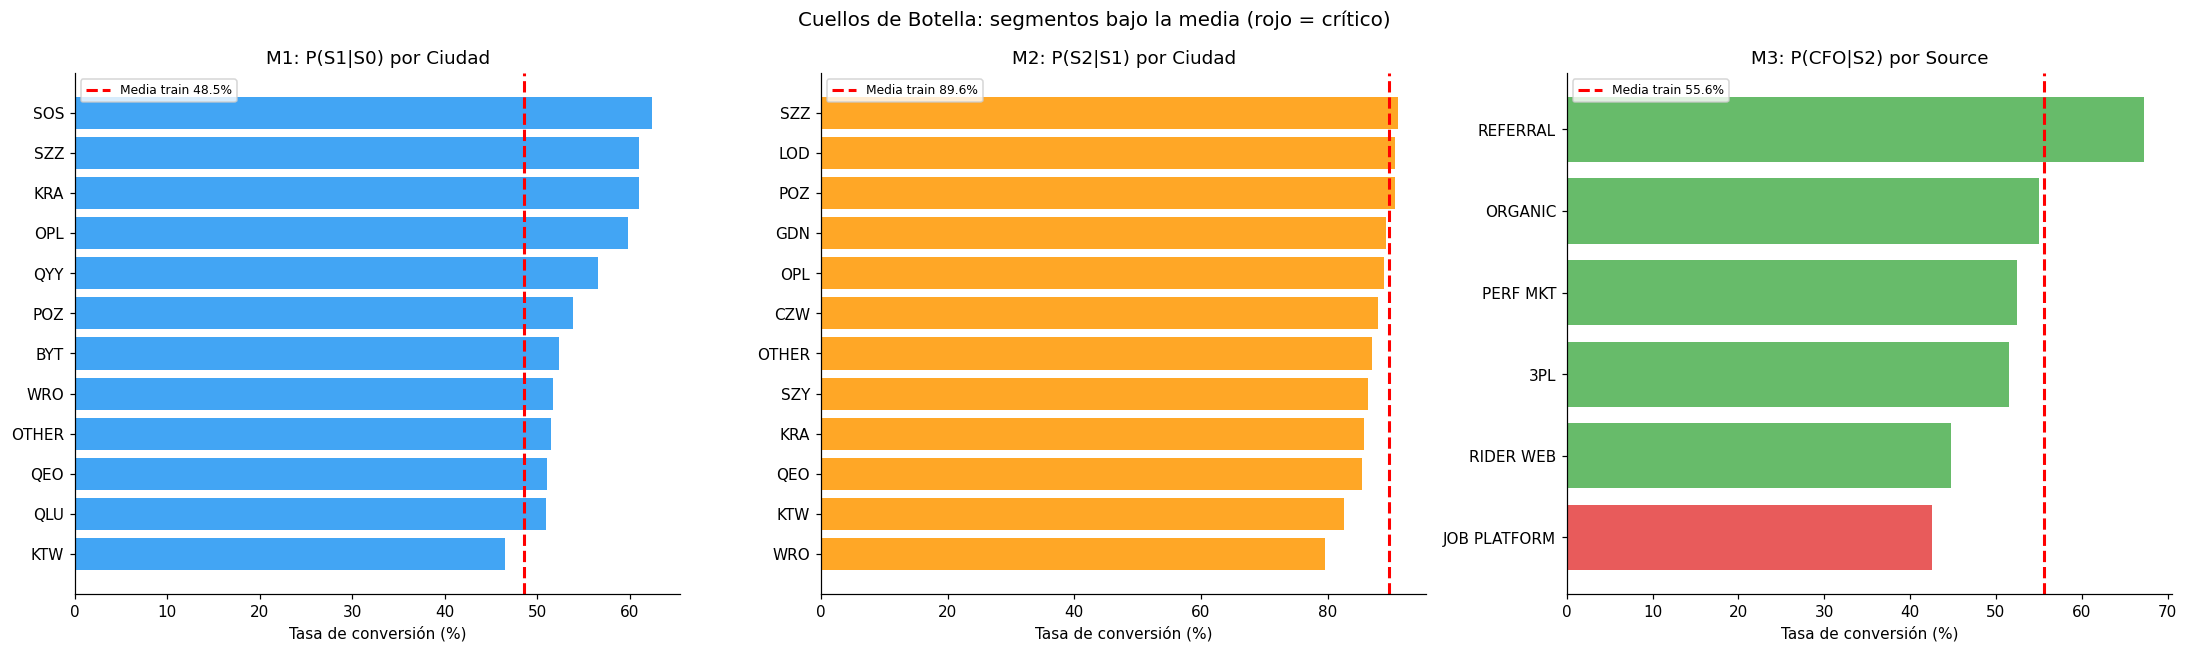

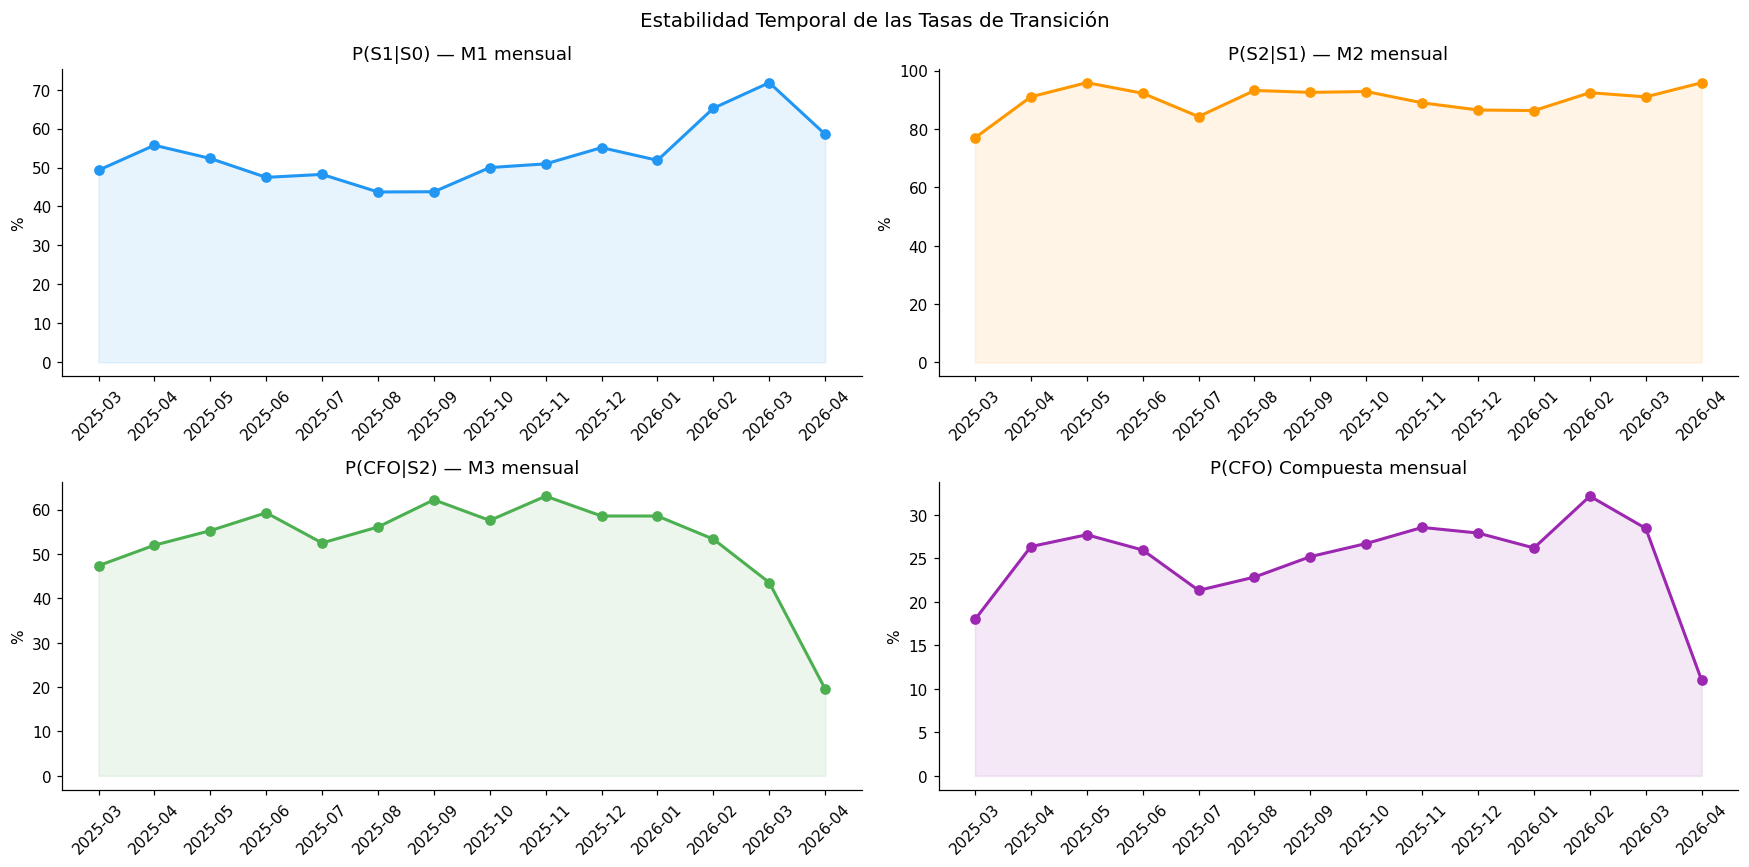

In [169]:
# ── Bottleneck visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (cb_df, title, color, base_rate) in zip(axes, [
    (cb_t1_city, "M1: P(S1|S0) por Ciudad",   "#2196F3", tr1["TARGET"].mean()),
    (cb_t2_city, "M2: P(S2|S1) por Ciudad",   "#FF9800", tr2["TARGET"].mean()),
    (cb_t3_src,  "M3: P(CFO|S2) por Source",  "#4CAF50", tr3["TARGET"].mean()),
]):
    if cb_df.empty: continue
    plot_df = cb_df.head(12)
    colors_bar = ["#E53E3E" if r < base_rate * 0.8 else color
                  for r in plot_df["conv_rate_test"]]
    ax.barh(plot_df["segment"], plot_df["conv_rate_test"]*100,
            color=colors_bar, alpha=0.85)
    ax.axvline(base_rate * 100, color="red", ls="--", lw=2,
               label=f"Media train {base_rate*100:.1f}%")
    ax.set_xlabel("Tasa de conversión (%)"); ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle("Cuellos de Botella: segmentos bajo la media (rojo = crítico)", fontsize=13)
plt.tight_layout(); plt.show()

# ── Temporal stability of transition rates ────────────────────────────────────
monthly = df.groupby("_month_period").agg(
    n=("is_cfo","count"),
    p_t1=("reached_s1","mean"),
    cfo_rate=("is_cfo","mean"),
).reset_index().sort_values("_month_period")

s1_monthly = df[df["reached_s1"]==1].groupby("_month_period")["was_hired"].mean().reset_index(name="p_t2")
s2_monthly = df[df["was_hired"]==1].groupby("_month_period")["is_cfo"].mean().reset_index(name="p_t3")
monthly = monthly.merge(s1_monthly, on="_month_period", how="left")                  .merge(s2_monthly, on="_month_period", how="left")
monthly["p_composed"] = monthly["p_t1"] * monthly["p_t2"] * monthly["p_t3"]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, (col, label, color) in zip(axes.flat, [
    ("p_t1",        "P(S1|S0) — M1 mensual",      "#2196F3"),
    ("p_t2",        "P(S2|S1) — M2 mensual",      "#FF9800"),
    ("p_t3",        "P(CFO|S2) — M3 mensual",     "#4CAF50"),
    ("p_composed",  "P(CFO) Compuesta mensual",    "#9C27B0"),
]):
    ax.plot(monthly["_month_period"], monthly[col]*100, "o-", lw=2, color=color)
    ax.fill_between(range(len(monthly)), monthly[col].values*100, alpha=0.1, color=color)
    ax.set_title(label); ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=45)
plt.suptitle("Estabilidad Temporal de las Tasas de Transición", fontsize=13)
plt.tight_layout(); plt.show()

Las líneas temporales por transición muestran la estabilidad del funnel a lo largo del tiempo. Caídas abruptas en alguna etapa señalan problemas operativos que vale la pena investigar.

## 23. Output final: scoring calibrado y diagnóstico por lead

Generamos la tabla final con la probabilidad calibrada P(CFO) para cada lead de test, junto con un diagnóstico de cuello de botella: para cada lead, identificamos cuál de los tres modelos (M1: doc review, M2: hiring, M3: activación) es el eslabón más débil. Esto permite priorizar acciones diferentes según el perfil del lead.

In [170]:
# ── Lead Scoring Pipeline (calibrated) ───────────────────────────────────────
score_output = score_df[["applicant_id","created_at","_month_period","is_cfo",
                          "reached_s1","reached_s2",
                          "p_s1_s0","p_s2_s1","p_cfo_s2",
                          "p_cfo_composed","p_cfo_fallback"]].copy()

score_output["city"]   = le_dict["city_group"].inverse_transform(te1["city_group"].values)
score_output["source"] = le_dict["source"].inverse_transform(te1["source"].values)

# ── Best calibrated composed probability ─────────────────────────────────────
score_output["p_cfo_cal"] = y_comp_cal   # Platt/Isotonic best per model, then composed

# ── Bottleneck diagnosis per lead (using calibrated scores) ──────────────────
q25_t1 = np.percentile(p1_cal, 25)
q25_t2 = np.percentile(p2_cal, 25)
q25_t3 = np.percentile(p3_cal, 25)

score_output["p1_cal"]   = p1_cal
score_output["p2_cal"]   = pd.Series(p2_cal, index=te2.index).reindex(score_output.index).fillna(global_p2).values
score_output["p3_cal"]   = pd.Series(p3_cal, index=X_te3.index).reindex(score_output.index).fillna(global_p3).values

score_output["bottleneck"] = "Balanceado"
score_output.loc[score_output["p1_cal"] < q25_t1, "bottleneck"] = "M1: doc review"
score_output.loc[score_output["p2_cal"] < q25_t2, "bottleneck"] = "M2: hiring rate"
score_output.loc[score_output["p3_cal"] < q25_t3, "bottleneck"] = "M3: activation"

# ── Summary metrics for final scoring ─────────────────────────────────────────
yt  = score_output["is_cfo"].values
ypc = score_output["p_cfo_cal"].values

print("=== TOP 20 LEADS POR P(CFO) CALIBRADA — TEST SET ===")
top_cols = ["applicant_id","created_at","city","source",
            "p_s1_s0","p_s2_s1","p_cfo_s2","p_cfo_composed","p_cfo_cal","is_cfo"]
print(score_output.sort_values("p_cfo_cal", ascending=False).head(20)[top_cols].to_string(index=False))

print("\n=== MÉTRICAS NEGOCIO (P(CFO) Calibrada) ===")
print(f"  AUC-PR:  {average_precision_score(yt, ypc):.4f} | AUC-ROC: {roc_auc_score(yt, ypc):.4f}")
print(f"  Brier:   {brier_score_loss(yt, ypc):.4f}")
for k in [0.05, 0.10, 0.20]:
    print(f"  P@{int(k*100):2d}%: {precision_at_k(yt, ypc, k):.4f}  |  Lift@{int(k*100):2d}%: {lift_at_k(yt, ypc, k):.2f}x  |  Recall coverage: {int(len(yt)*k):,} leads")

print("\n=== DIAGNÓSTICO DE CUELLOS DE BOTELLA (calibrado) ===")
print(score_output["bottleneck"].value_counts().to_string())

print("\n=== P(CFO) calibrada POR CUELLO DE BOTELLA ===")
print(score_output.groupby("bottleneck")["p_cfo_cal"].describe().round(4).to_string())


=== TOP 20 LEADS POR P(CFO) CALIBRADA — TEST SET ===
                        applicant_id                 created_at city   source  p_s1_s0  p_s2_s1  p_cfo_s2  p_cfo_composed  p_cfo_cal  is_cfo
f742a3d6-4f4c-4f16-9567-a3da930624b0 2025-12-31 10:49:36.435267  WAW REFERRAL 0.857658 0.885352  0.679259        0.515781   0.614157       0
f921528f-5781-4634-b3a9-45f304c1566b 2025-12-31 11:07:03.494137  GDN REFERRAL 0.860623 0.970228  0.718412        0.599874   0.590163       0
a4c5b01c-f140-43eb-bbd2-f0439a5f6818 2025-12-31 08:41:44.181097  KRA REFERRAL 0.827254 0.847231  0.719473        0.504261   0.587547       0
7b145c15-61d7-4375-b2f8-f0f38d9ebaf6 2026-02-11 11:03:55.187923  GDN REFERRAL 0.783723 0.877201  0.732271        0.503424   0.583964       1
26de0953-72b2-4ab5-86c8-dc03920964b2 2026-04-02 10:32:03.577554  KRA REFERRAL 0.794274 0.855101  0.760504        0.516523   0.576110       0
19537d43-34f8-4519-a889-a7c03f71f1e6 2026-02-05 11:38:32.235498  GDN REFERRAL 0.777155 0.844303  0.74

Con esto tenemos un sistema completo: para cada lead podemos decir cuál es su probabilidad de llegar a CFO, por qué tiene esa probabilidad (SHAP), qué transición es su punto débil (bottleneck), y cómo varía todo por ciudad y source. El siguiente paso es llevar esto a producción con un pipeline automatizado.